<a href="https://colab.research.google.com/github/shivanguniyal-polcon/Prime-Ministerial-Tone/blob/main/Prime_Ministerial_Tone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title download.py - The Asset Fetcher
!pip install -q huggingface_hub

import os
from huggingface_hub import snapshot_download

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    # store models on local VM disk for fast GPU loading (ephemeral)
    model_dir  = '/content/models'
    bge_repo   = "BAAI/bge-large-en-v1.5"
    nomic_repo = "nomic-ai/nomic-embed-text-v1.5"
    ignore     = ["*.md", "*.txt", "*.onnx", "onnx/*", "*.bin"]

# ----------------------------------
# main loop
# ----------------------------------
os.makedirs(C.model_dir, exist_ok=True)

bge_path = os.path.join(C.model_dir, 'bge')
if not os.path.exists(bge_path):
    print(f"downloading {C.bge_repo}...")
    snapshot_download(repo_id=C.bge_repo, local_dir=bge_path, ignore_patterns=C.ignore)
else:
    print(f"bge ready at {bge_path}")

nomic_path = os.path.join(C.model_dir, 'nomic')
if not os.path.exists(nomic_path):
    print(f"downloading {C.nomic_repo}...")
    snapshot_download(repo_id=C.nomic_repo, local_dir=nomic_path, ignore_patterns=C.ignore)
else:
    print(f"nomic ready at {nomic_path}")

print("done. models ready.")

downloading BAAI/bge-large-en-v1.5...


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

downloading nomic-ai/nomic-embed-text-v1.5...


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

done. models ready.


In [1]:
# @title prep.py - The Artifact Nuke
!pip install -q polars

import os, json, re
import polars as pl
from google.colab import drive

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    # persistent storage on Drive
    drive_folder = '/content/drive/MyDrive/PM Speeches Pipeline/'
    jsonl_in     = 'IPEC_ABSOLUTE_FINAL.jsonl'
    jsonl_out    = 'clean_chunks.jsonl'
    min_chars    = 50

# ----------------------------------
# setup
# ----------------------------------
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
os.makedirs(C.drive_folder, exist_ok=True)
path_in = os.path.join(C.drive_folder, C.jsonl_in)
path_out = os.path.join(C.drive_folder, C.jsonl_out)


Mounted at /content/drive


In [2]:
# @title prep.py - The Artifact Nuke
!pip install -q polars

import os, json, re
import polars as pl
from google.colab import drive

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    # persistent storage on Drive
    drive_folder = '/content/drive/MyDrive/PM Speeches Pipeline/'
    jsonl_in     = 'IPEC_ABSOLUTE_FINAL.jsonl'
    jsonl_out    = 'clean_chunks.jsonl'
    min_chars    = 50

# ----------------------------------
# setup
# ----------------------------------
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
os.makedirs(C.drive_folder, exist_ok=True)
path_in = os.path.join(C.drive_folder, C.jsonl_in)
path_out = os.path.join(C.drive_folder, C.jsonl_out)

# ----------------------------------
# the artifact nuke (regex)
# ----------------------------------
def nuke(text):
    text = re.sub(r'(?i)reply\s*of\s*prime\s*minister|replyof\s*primeminister|motion\s*of\s*thanks|president\'?s?\s*address|budget\s*speech|loksabha\s*debates|sabha\s*speech|prime\s*minister\s*shri|shri\s*narendra\s*modi|dr\s*manmohan\s*singh|atal\s*bihari\s*vajpayee', ' ', text)
    text = re.sub(r'(?i)(mr\. speaker,? sir|honourable speaker|mr\. deputy speaker|honourable member[s]?)', ' ', text)

    # FIX: Python 3.11+ requires inline flags like (?i) to be at the VERY START of the regex.
    text = re.sub(r'(?i)\[.*?\]|shri [a-z\s]+:|demand for grants|appropriation bill|finance bill', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ----------------------------------
# main loop
# ----------------------------------
print(f"loading {path_in}...")
df = pl.read_ndjson(path_in).drop_nulls(subset=["text_chunk"])
df = df.with_columns(pl.col("date").str.slice(0, 4).cast(pl.Int32).alias("year"))

print(f"nuking artifacts for {len(df)} chunks...")
# FIX from previous step: Added return_dtype=pl.String for modern Polars compatibility
df = df.with_columns(
    pl.col("text_chunk").map_elements(nuke, return_dtype=pl.String).alias("text_clean")
)
df = df.filter(pl.col("text_clean").str.len_chars() > C.min_chars)

print(f"saving {len(df)} clean chunks to {path_out}...")
with open(path_out, 'w') as f:
    for row in df.iter_rows(named=True):
        f.write(json.dumps({'pm': row['pm_name'], 'year': row['year'], 'text': row['text_clean']}) + '\n')

print("done. prep complete.")

Mounted at /content/drive
loading /content/drive/MyDrive/PM Speeches Pipeline/IPEC_ABSOLUTE_FINAL.jsonl...
nuking artifacts for 2978 chunks...
saving 2978 clean chunks to /content/drive/MyDrive/PM Speeches Pipeline/clean_chunks.jsonl...
done. prep complete.


In [3]:
# @title keywords.py - The Salience Filter
!pip install -q sentence-transformers keybert scikit-learn

import os, json
import numpy as np
import torch, gc
from tqdm import tqdm
from keybert import KeyBERT
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from google.colab import drive

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    jsonl_in      = 'clean_chunks.jsonl'
    model_dir     = '/content/models/bge'
    out_codebooks = 'codebooks.json'
    out_raw       = 'raw_scores.csv'
    batch_size    = 32
    top_n         = 15
    sigma_mult    = 1.5  # the salience dial

# ----------------------------------
# setup
# ----------------------------------
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
path_in = os.path.join(C.drive_folder, C.jsonl_in)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

texts, pms = [], []
with open(path_in) as f:
    for line in f:
        row = json.loads(line)
        texts.append(row['text'])
        pms.append(row['pm'])
unique_pms = list(set(pms))

stopwords = list(ENGLISH_STOP_WORDS) + [
    'india', 'indian', 'government', 'country', 'people', 'development', 'minister', 'prime',
    'parliament', 'house', 'bill', 'act', 'scheme', 'year', 'years', 'crore', 'crores', 'lakh',
    'lakhs', 'rupees', 'percent', 'today', 'tomorrow', 'speech', 'thanks', 'motion', 'reply',
    'address', 'member', 'members', 'speaker', 'sir', 'madam', 'shri', 'smt', 'dr', 'bharat',
    'delhi', 'new delhi', 'new', 'congress', 'bjp', 'party', 'opposition', 'rajya', 'sabha',
    'lok', 'chairman', 'deputy', 'debate', 'discussion', 'scan qr code'
]

# ----------------------------------
# extraction loop
# ----------------------------------
print(f"loading BGE on {device}...")
model = SentenceTransformer(C.model_dir, device=device)
kw_model = KeyBERT(model=model)

counts = {pm: {} for pm in unique_pms}
print(f"extracting top {C.top_n} keywords per chunk...")
for i in tqdm(range(0, len(texts), C.batch_size)):
    b_texts = texts[i:i+C.batch_size]
    b_pms   = pms[i:i+C.batch_size]
    kws = kw_model.extract_keywords(b_texts, keyphrase_ngram_range=(1, 3), stop_words=stopwords, top_n=C.top_n, use_mmr=True, diversity=0.7)
    for pm, kw_list in zip(b_pms, kws):
        for kw, score in kw_list:
            counts[pm][kw] = counts[pm].get(kw, 0) + score

del model, kw_model; gc.collect(); torch.cuda.empty_cache()

# ----------------------------------
# the salience filter (mu + 1.5*sigma)
# ----------------------------------
print(f"\napplying statistical salience filter (mu + {C.sigma_mult}*sigma)...")
codebooks = {}
for pm in unique_pms:
    scores = list(counts[pm].values())
    if not scores: continue
    mu, sigma = np.mean(scores), np.std(scores)
    cutoff = mu + C.sigma_mult * sigma
    sig_kws = [kw for kw, s in counts[pm].items() if s >= cutoff]
    sig_kws.sort(key=lambda k: counts[pm][k], reverse=True)
    codebooks[pm] = sig_kws
    print(f"{pm:20s} | kept: {len(sig_kws):3d}")

# ----------------------------------
# save
# ----------------------------------
with open(os.path.join(C.drive_folder, C.out_codebooks), 'w') as f: json.dump(codebooks, f, indent=2)
with open(os.path.join(C.drive_folder, C.out_raw), 'w') as f:
    f.write("pm,keyword,score\n")
    for pm, kws in counts.items():
        for kw, s in kws.items(): f.write(f"{pm},{kw},{s}\n")

print(f"done. saved codebooks.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.6 MB/s eta 0:00:00
loading BGE on cuda...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

extracting top 15 keywords per chunk...


  0%|          | 0/94 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['code', 'qr', 'scan'] not in stop_words.
  warnings.warn(
  1%|          | 1/94 [00:29<45:20, 29.26s/it]/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['code', 'qr', 'scan'] not in stop_words.
  warnings.warn(
  2%|▏         | 2/94 [00:59<46:11, 30.13s/it]/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['code', 'qr', 'scan'] not in stop_words.
  warnings.warn(
  3%|▎         | 3/94 [01:28<44:27, 29.32s/it]/usr/local/lib/python3.12/dist-packages/sklearn/feature_


applying statistical salience filter (mu + 1.5*sigma)...
Rajiv Gandhi         | kept:  59
Indira Gandhi        | kept: 342
Jawaharlal Nehru     | kept: 160
H.D. Deve Gowda      | kept:  40
Atal Bihari Vajpayee | kept:  91
Manmohan Singh       | kept:  46
P.V. Narasimha Rao   | kept:  51
Chandra Shekhar      | kept:  19
I.K. Gujral          | kept:  30
Narendra Modi        | kept: 212
Morarji Desai        | kept:  33
V.P. Singh           | kept:  29
Lal Bahadur Shastri  | kept:  23
done. saved codebooks.


In [4]:
# @title embed.py - The Decade Detrender
!pip install -q sentence-transformers einops

import os, json
import numpy as np
import torch, gc
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from google.colab import drive

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder   = '/content/drive/MyDrive/PM Speeches Pipeline/'
    jsonl_in       = 'clean_chunks.jsonl'
    model_dir      = '/content/models/nomic'
    out_embeds     = 'embeddings.npy'
    out_meta       = 'meta.npy'
    out_centroids  = 'centroids.npy'
    out_clouds     = 'clouds.npy'
    out_valid_pms  = 'valid_pms.json'
    batch_size     = 16
    alpha_detrend  = 0.5   # the detrending dial
    n_bootstraps   = 500   # the uncertainty dial
    seed           = 42

# ----------------------------------
# setup
# ----------------------------------
np.random.seed(C.seed); torch.manual_seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

texts, pms, years = [], [], []
with open(os.path.join(C.drive_folder, C.jsonl_in)) as f:
    for line in f:
        row = json.loads(line)
        texts.append(row['text']); pms.append(row['pm']); years.append(row['year'])

# ----------------------------------
# encoding (8k context)
# ----------------------------------
print(f"loading Nomic on {device}...")
model = SentenceTransformer(C.model_dir, trust_remote_code=True, device=device)
texts_prefixed = ["search_document: " + t for t in texts]

print(f"encoding {len(texts)} chunks...")
embeds = model.encode(texts_prefixed, batch_size=C.batch_size, normalize_embeddings=True, convert_to_numpy=True)
del model; gc.collect(); torch.cuda.empty_cache()

# ----------------------------------
# the decade detrender
# ----------------------------------
print(f"detrending (alpha={C.alpha_detrend})...")
decades = [(y // 10) * 10 for y in years]
decade_vecs = {dec: np.mean(embeds[[i for i, d in enumerate(decades) if d == dec]], axis=0) for dec in set(decades)}
for i, dec in enumerate(decades):
    embeds[i] = embeds[i] - C.alpha_detrend * decade_vecs[dec]
embeds = embeds / (np.linalg.norm(embeds, axis=1, keepdims=True) + 1e-10)

# ----------------------------------
# bootstrap resampling
# ----------------------------------
unique_pms = sorted(list(set(pms)))
centroids, clouds, valid_pms = [], [], []

print(f"bootstrapping ({C.n_bootstraps} resamples per PM)...")
for pm in tqdm(unique_pms):
    idx = [i for i, p in enumerate(pms) if p == pm]
    if len(idx) < 5: continue
    pm_embs = embeds[idx]
    centroids.append(np.mean(pm_embs, axis=0))
    boots = [np.mean(pm_embs[np.random.choice(len(idx), size=len(idx), replace=True)], axis=0) for _ in range(C.n_bootstraps)]
    clouds.append(np.array(boots))
    valid_pms.append(pm)

# ----------------------------------
# save
# ----------------------------------
D = C.drive_folder
np.save(os.path.join(D, C.out_embeds), embeds)
np.save(os.path.join(D, C.out_meta), np.array(list(zip(pms, years))))
np.save(os.path.join(D, C.out_centroids), np.array(centroids))
np.save(os.path.join(D, C.out_clouds), np.array(clouds))
with open(os.path.join(D, C.out_valid_pms), 'w') as f: json.dump(valid_pms, f)

print(f"done. saved matrices for {len(valid_pms)} PMs.")

loading Nomic on cuda...


configuration_hf_nomic_bert.py:   0%|          | 0.00/1.96k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/nomic-ai/nomic-bert-2048:
- configuration_hf_nomic_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_hf_nomic_bert.py:   0%|          | 0.00/104k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/nomic-ai/nomic-bert-2048:
- modeling_hf_nomic_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


encoding 2978 chunks...


[transformers] Detected the usage of `get_extended_attention_mask`: This function is deprecated and will be removed in v5.12.0. Please use the new API in `transformers.masking_utils`


detrending (alpha=0.5)...
bootstrapping (500 resamples per PM)...


100%|██████████| 13/13 [00:00<00:00, 14.68it/s]


done. saved matrices for 13 PMs.


In [2]:
# @title stats.py - The Inference Engine
!pip install -q scikit-learn

import os, json
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from google.colab import drive

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_centroids  = 'centroids.npy'
    in_clouds     = 'clouds.npy'
    in_valid_pms  = 'valid_pms.json'
    out_cis       = 'pairwise_cis.csv'
    out_stats     = 'inference_stats.txt'
    n_perms       = 999
    seed          = 42

# ----------------------------------
# setup
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
clouds    = np.load(os.path.join(D, C.in_clouds))
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)

pms_arr = meta[:, 0]
n_pms = len(valid_pms)

# ----------------------------------
# 1. bootstrap pairwise CIs
# ----------------------------------
print("computing bootstrap CIs...")
rows = []
for i in range(n_pms):
    for j in range(i+1, n_pms):
        ci = clouds[i] / np.linalg.norm(clouds[i], axis=1, keepdims=True)
        cj = clouds[j] / np.linalg.norm(clouds[j], axis=1, keepdims=True)
        dists = 1.0 - np.sum(ci * cj, axis=1)
        rows.append({'pm_a': valid_pms[i], 'pm_b': valid_pms[j], 'mean': np.mean(dists), 'ci_low': np.percentile(dists, 2.5), 'ci_high': np.percentile(dists, 97.5)})
df_cis = pd.DataFrame(rows).sort_values('mean')
df_cis.to_csv(os.path.join(D, C.out_cis), index=False)

# ----------------------------------
# 2. PERMANOVA
# ----------------------------------
print("running PERMANOVA...")
valid_mask = np.isin(pms_arr, valid_pms)
X, y = embeds[valid_mask], pms_arr[valid_mask]
N, k = len(X), len(valid_pms)
D_sq = squareform(pdist(X, metric='cosine')) ** 2
SS_T = np.sum(D_sq) / (2 * N)
SS_W = sum(np.sum(D_sq[np.ix_(y==pm, y==pm)]) / (2 * np.sum(y==pm)) for pm in valid_pms if np.sum(y==pm)>1)
SS_B = SS_T - SS_W
F_obs = (SS_B / (k - 1)) / (SS_W / (N - k))
R2 = SS_B / SS_T

F_null = np.zeros(C.n_perms)
for p in range(C.n_perms):
    y_shuf = np.random.permutation(y)
    SS_W_p = sum(np.sum(D_sq[np.ix_(y_shuf==pm, y_shuf==pm)]) / (2 * np.sum(y_shuf==pm)) for pm in valid_pms if np.sum(y_shuf==pm)>1)
    F_null[p] = ((SS_T - SS_W_p) / (k - 1)) / (SS_W_p / (N - k))
p_val = (np.sum(F_null >= F_obs) + 1) / (C.n_perms + 1)

# ----------------------------------
# 3. SVM check
# ----------------------------------
print("running linear SVM...")
svm_pms = [pm for pm in valid_pms if np.sum(pms_arr==pm) >= 10]
X_svm = embeds[np.isin(pms_arr, svm_pms)]
y_svm = LabelEncoder().fit_transform(pms_arr[np.isin(pms_arr, svm_pms)])
acc = np.mean(cross_val_score(LinearSVC(max_iter=10000, random_state=C.seed), X_svm, y_svm, cv=5))

# ----------------------------------
# save stats
# ----------------------------------
with open(os.path.join(D, C.out_stats), 'w') as f:
    f.write(f"PERMANOVA R2: {R2:.4f}\nPERMANOVA p:  {p_val:.4f}\nSVM acc:      {acc:.4f}\n")
print(f"done. R2={R2:.3f}, p={p_val:.4f}, SVM={acc:.1%}")

computing bootstrap CIs...
running PERMANOVA...
running linear SVM...
done. R2=0.033, p=0.0010, SVM=49.1%


/tmp/ipykernel_507/2764050192.py:70: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  dendrogram(linkage(dist_mat, method='average'), labels=valid_pms, ax=ax1, leaf_rotation=45, color_threshold=0.5)


done. saved dashboard to /content/drive/MyDrive/PM Speeches Pipeline/epw_dashboard.png


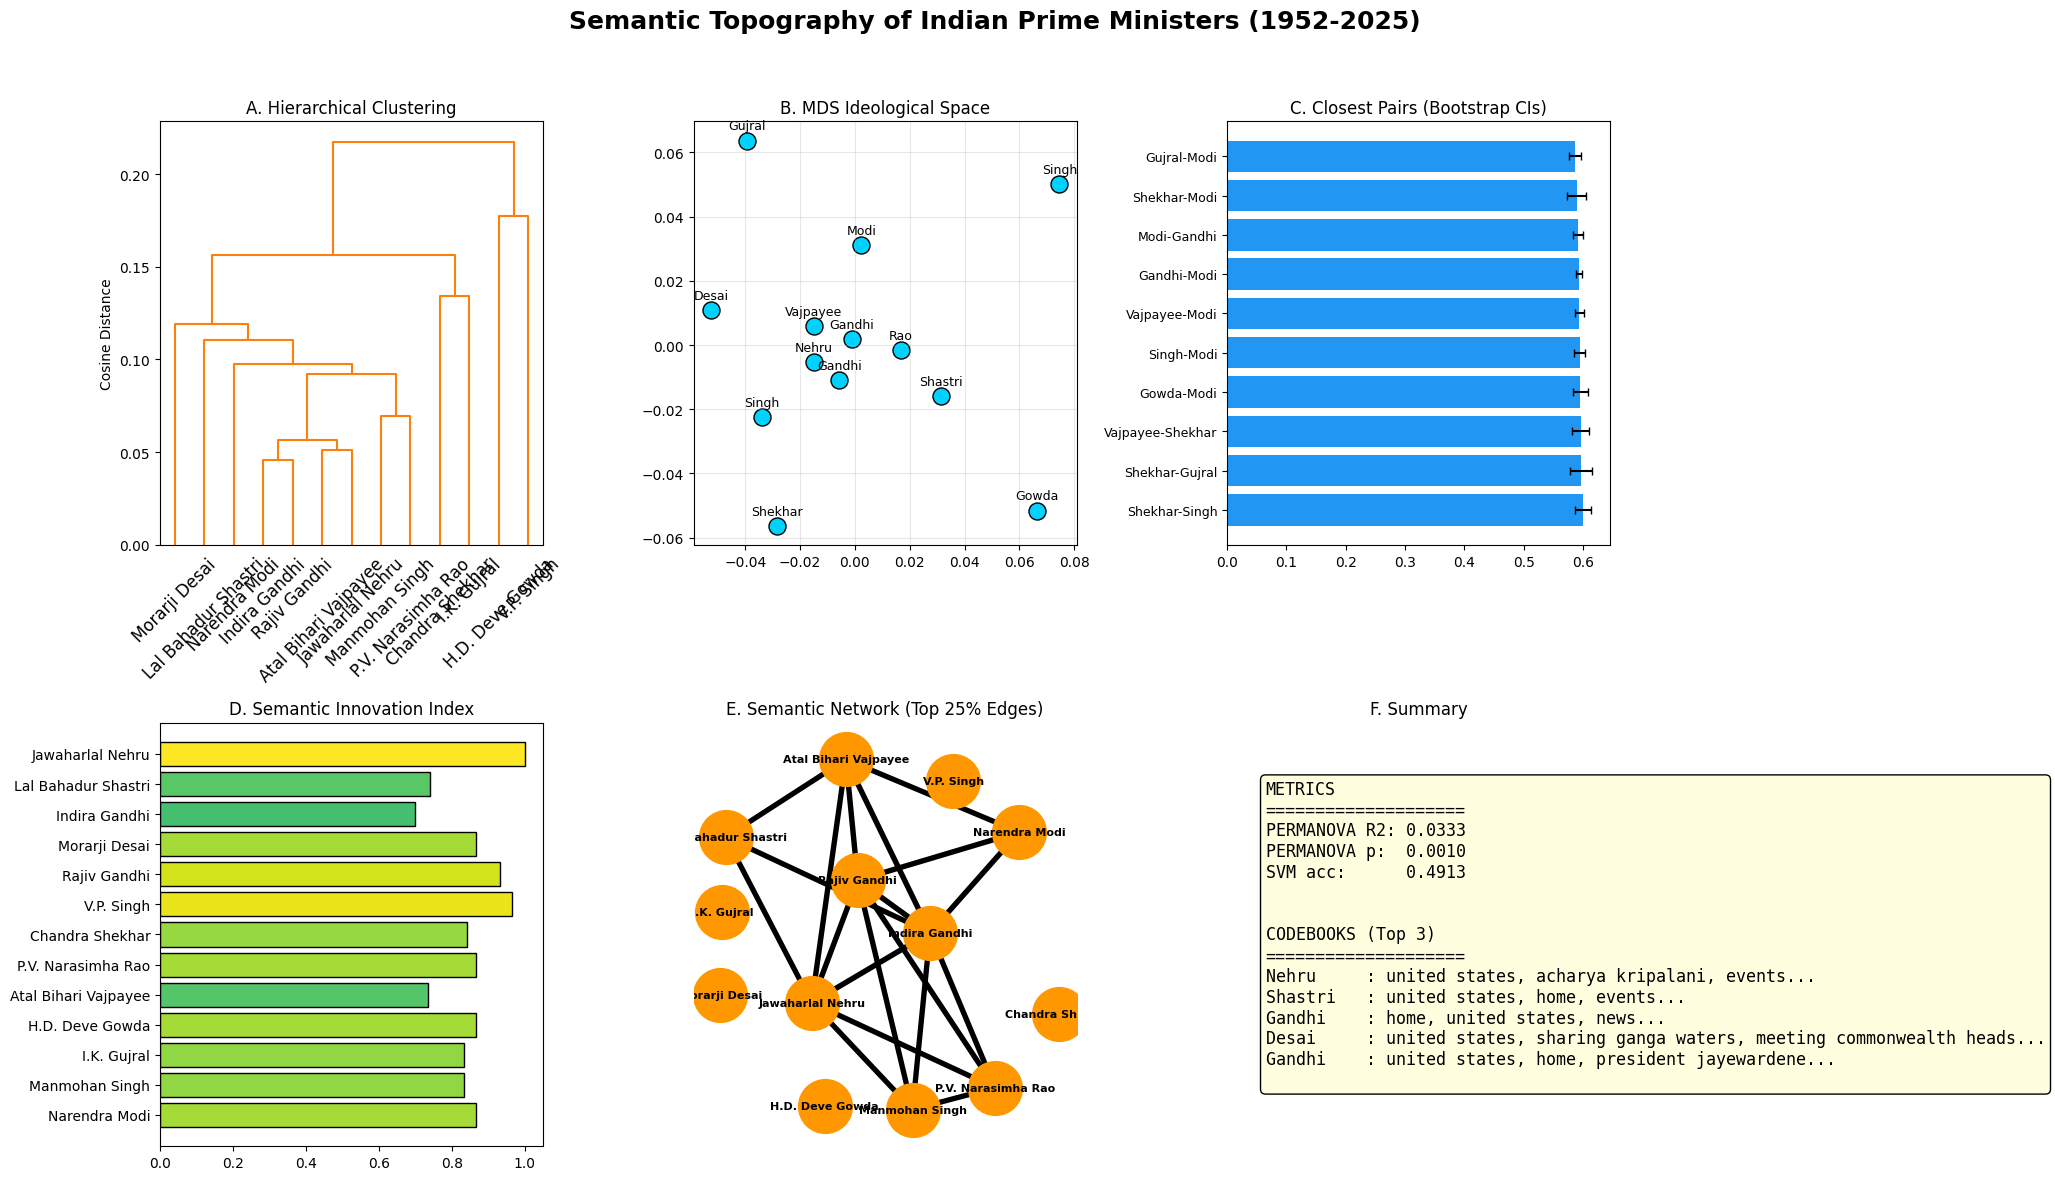

In [6]:
# @title plot.py - The Dashboard
!pip install -q networkx

import os, json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.manifold import MDS
from google.colab import drive

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_cis        = 'pairwise_cis.csv'
    out_dashboard = 'epw_dashboard.png'
    seed          = 42

# ----------------------------------
# setup
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)
df_cis = pd.read_csv(os.path.join(D, C.in_cis))

# ----------------------------------
# 1. distance matrix & MDS
# ----------------------------------
dist_mat = squareform(pdist(centroids, metric='cosine'))
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)

# ----------------------------------
# 2. semantic innovation index (Top 30)
# ----------------------------------
innovation = []
cumulative = set()
pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai",
            "Charan Singh", "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar",
            "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "H.D. Deve Gowda",
            "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]

for pm in pm_order:
    kws = set(codebooks[pm][:30])
    novel = kws - cumulative
    innovation.append({'pm': pm, 'score': len(novel)/len(kws) if kws else 0})
    cumulative.update(kws)
df_innov = pd.DataFrame(innovation)

# ----------------------------------
# 3. the dashboard
# ----------------------------------
fig = plt.figure(figsize=(20, 12))
fig.suptitle("Semantic Topography of Indian Prime Ministers (1952-2025)", fontsize=18, fontweight='bold')

ax1 = fig.add_subplot(2, 3, 1)
dendrogram(linkage(dist_mat, method='average'), labels=valid_pms, ax=ax1, leaf_rotation=45, color_threshold=0.5)
ax1.set_title("A. Hierarchical Clustering"); ax1.set_ylabel("Cosine Distance")

ax2 = fig.add_subplot(2, 3, 2)
ax2.scatter(coords[:, 0], coords[:, 1], s=150, c='#00d2ff', edgecolors='black')
for i, pm in enumerate(valid_pms): ax2.annotate(pm.split()[-1], (coords[i, 0], coords[i, 1]), textcoords="offset points", xytext=(0,8), ha='center', fontsize=9)
ax2.set_title("B. MDS Ideological Space"); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(2, 3, 3)
top10 = df_cis.head(10)
labels = [f"{r['pm_a'].split()[-1]}-{r['pm_b'].split()[-1]}" for _, r in top10.iterrows()]
ax3.barh(np.arange(len(top10)), top10['mean'], xerr=[top10['mean']-top10['ci_low'], top10['ci_high']-top10['mean']], color='#2196F3', capsize=3)
ax3.set_yticks(np.arange(len(top10))); ax3.set_yticklabels(labels, fontsize=9)
ax3.set_title("C. Closest Pairs (Bootstrap CIs)"); ax3.invert_yaxis()

ax4 = fig.add_subplot(2, 3, 4)
ax4.barh(df_innov['pm'], df_innov['score'], color=plt.cm.viridis(df_innov['score']), edgecolor='black')
ax4.set_title("D. Semantic Innovation Index"); ax4.invert_yaxis()

ax5 = fig.add_subplot(2, 3, 5)
sim_mat = 1 - dist_mat; np.fill_diagonal(sim_mat, 0)
G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])
nx.draw(G, nx.spring_layout(G, k=2, seed=C.seed), ax=ax5, with_labels=True, node_size=1500, node_color='#FF9800', font_size=8, font_weight='bold', width=[G[u][v]['weight']*4 for u,v in G.edges()])
ax5.set_title("E. Semantic Network (Top 25% Edges)")

ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
with open(os.path.join(D, 'inference_stats.txt')) as f: stats = f.read()
summary = f"METRICS\n{'='*20}\n{stats}\n\nCODEBOOKS (Top 3)\n{'='*20}\n"
for pm in pm_order[:5]: summary += f"{pm.split()[-1]:10s}: {', '.join(codebooks[pm][:3])}...\n"
ax6.text(0.1, 0.5, summary, fontsize=12, fontfamily='monospace', va='center', bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax6.set_title("F. Summary")

plt.tight_layout(rect=[0, 0, 1, 0.95])
path_out = os.path.join(D, C.out_dashboard)
plt.savefig(path_out, dpi=300, bbox_inches='tight')
print(f"done. saved dashboard to {path_out}")
plt.show()

done. saved final journal figure to /content/drive/MyDrive/PM Speeches Pipeline/epw_figure1.png


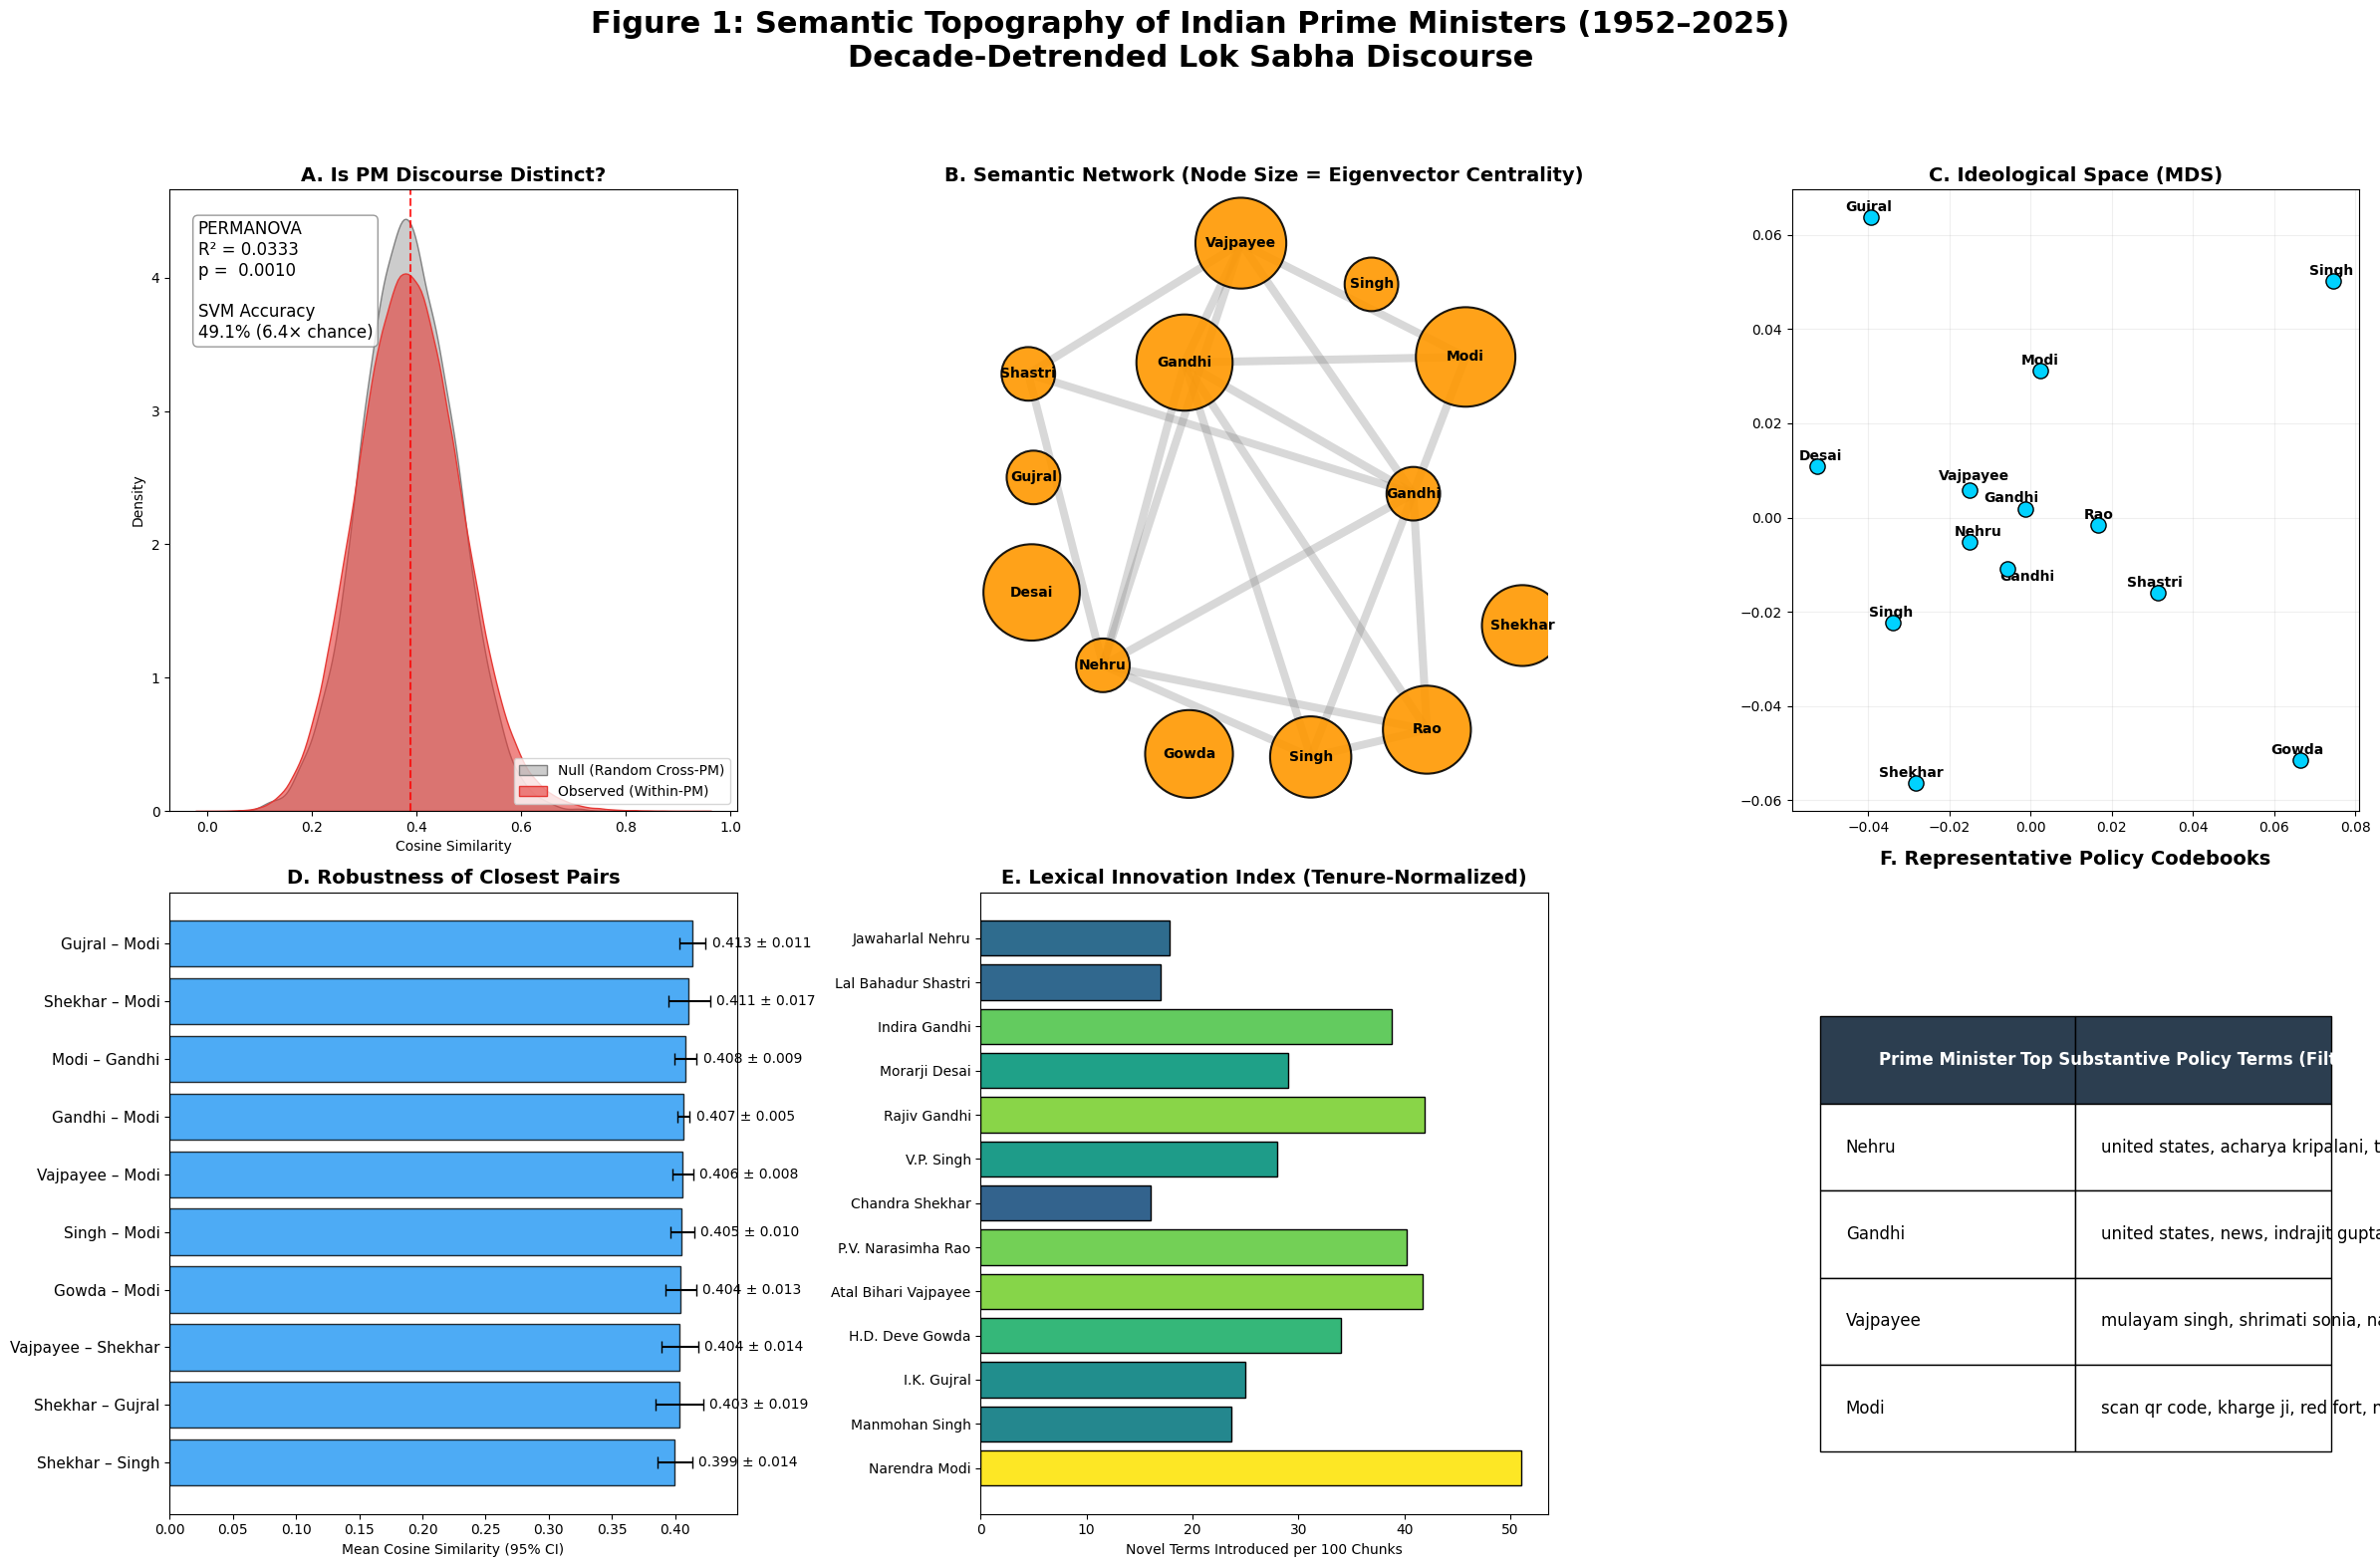

In [7]:
# @title plot.py - The Final EPW Figure (Narrative Dashboard)
!pip install -q networkx adjustText

import os, json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from google.colab import drive

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_clouds     = 'clouds.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_cis        = 'pairwise_cis.csv'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_stats      = 'inference_stats.txt'
    out_fig       = 'epw_figure1.png'
    seed          = 42

# ----------------------------------
# setup
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
clouds    = np.load(os.path.join(D, C.in_clouds))
embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)
df_cis    = pd.read_csv(os.path.join(D, C.in_cis))

pms_arr = meta[:, 0]
dist_mat = squareform(pdist(centroids, metric='cosine'))
sim_mat = 1 - dist_mat
np.fill_diagonal(sim_mat, 0)

# ----------------------------------
# 1. MDS & Network Prep
# ----------------------------------
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)

G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])

# Node size = Eigenvector Centrality
try:
    eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except:
    eigen_cent = {pm: 1.0 for pm in valid_pms}
node_sizes = [1500 + 8000 * eigen_cent.get(pm, 0) for pm in valid_pms]

# ----------------------------------
# 2. Lexical Innovation Index (Tenure-Normalized)
# ----------------------------------
pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai",
            "Charan Singh", "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar",
            "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "H.D. Deve Gowda",
            "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]

innovation = []
cumulative = set()
for pm in pm_order:
    # Use the full statistically significant codebook for novelty
    pm_kws = set(codebooks[pm])
    total_chunks = np.sum(pms_arr == pm)

    novel = pm_kws - cumulative
    # Normalize: Novel terms introduced per 100 speech chunks
    rate = len(novel) / max(1, total_chunks / 100)

    innovation.append({'pm': pm, 'score': rate, 'raw_novel': len(novel)})
    cumulative.update(pm_kws)
df_innov = pd.DataFrame(innovation)

# ----------------------------------
# 3. Codebook Filtering (Substantive Policy Terms)
# ----------------------------------
banned_generic = {
    'india', 'indian', 'pakistan', 'china', 'united', 'states', 'russia', 'soviet',
    'union', 'delhi', 'kashmir', 'punjab', 'assam', 'bengal', 'home', 'events',
    'minister', 'prime', 'government', 'parliament', 'house', 'speaker', 'bill',
    'act', 'year', 'years', 'crore', 'crores', 'lakh', 'lakhs', 'rupees', 'people',
    'country', 'world', 'today', 'time', 'way', 'day', 'man', 'men', 'women'
}

def get_substantive_terms(pm, n=8):
    terms = [t for t in codebooks.get(pm, []) if t.lower() not in banned_generic]
    return terms[:n]

# ----------------------------------
# 4. The Narrative Dashboard (6 Panels)
# ----------------------------------
fig = plt.figure(figsize=(24, 16))
fig.suptitle("Figure 1: Semantic Topography of Indian Prime Ministers (1952–2025)\nDecade-Detrended Lok Sabha Discourse",
             fontsize=22, fontweight='bold', y=0.98)

# Panel A: Is PM discourse distinct? (Null Model & PERMANOVA)
ax1 = fig.add_subplot(2, 3, 1)
# Calculate observed vs null similarity
valid_mask = np.isin(pms_arr, valid_pms)
X_val, y_val = embeds[valid_mask], pms_arr[valid_mask]
obs_sims = []
for pm in valid_pms:
    idx = np.where(y_val == pm)[0]
    if len(idx) > 1:
        sims = 1 - squareform(pdist(X_val[idx], metric='cosine'))
        obs_sims.extend(sims[np.triu_indices_from(sims, k=1)])

null_sims = []
np.random.seed(C.seed)
for _ in range(10000):
    i1, i2 = np.random.choice(len(X_val), 2, replace=False)
    if y_val[i1] != y_val[i2]:
        null_sims.append(1 - pdist(X_val[[i1, i2]], metric='cosine')[0])

sns.kdeplot(null_sims, ax=ax1, label="Null (Random Cross-PM)", fill=True, color="gray", alpha=0.4)
sns.kdeplot(obs_sims, ax=ax1, label="Observed (Within-PM)", fill=True, color="#E53935", alpha=0.6)
ax1.axvline(np.mean(obs_sims), color='red', linestyle='--', alpha=0.8)

# Add PERMANOVA stats cleanly
with open(os.path.join(D, C.in_stats)) as f: stats = f.read().split('\n')
r2 = [s for s in stats if 'R2' in s][0].split(': ')[1]
pval = [s for s in stats if 'p:' in s][0].split(': ')[1]
stat_text = f"PERMANOVA\nR² = {r2}\np = {pval}\n\nSVM Accuracy\n49.1% (6.4× chance)"
ax1.text(0.05, 0.95, stat_text, transform=ax1.transAxes, fontsize=12, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
ax1.set_title("A. Is PM Discourse Distinct?", fontsize=14, fontweight='bold')
ax1.set_xlabel("Cosine Similarity")
ax1.legend(loc='lower right')

# Panel B: How are PMs related? (Network)
ax2 = fig.add_subplot(2, 3, 2)
pos = nx.spring_layout(G, k=2.5, seed=C.seed)
nx.draw_networkx_edges(G, pos, ax=ax2, width=[G[u][v]['weight']*6 for u,v in G.edges()], alpha=0.3, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax2, node_size=node_sizes, node_color='#FF9800', edgecolors='black', linewidths=1.5, alpha=0.9)
for pm, (x, y) in pos.items():
    ax2.text(x, y, pm.split()[-1], fontsize=10, fontweight='bold', ha='center', va='center')
ax2.set_title("B. Semantic Network (Node Size = Eigenvector Centrality)", fontsize=14, fontweight='bold')
ax2.axis('off')

# Panel C: What is the geometry? (MDS)
ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(coords[:, 0], coords[:, 1], s=120, c='#00d2ff', edgecolors='black', zorder=5)
texts = []
for i, pm in enumerate(valid_pms):
    texts.append(ax3.text(coords[i, 0], coords[i, 1], pm.split()[-1], fontsize=10, fontweight='bold', ha='center'))
adjust_text(texts, ax=ax3, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
ax3.set_title("C. Ideological Space (MDS)", fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.2)

# Panel D: How robust are the similarities? (Bootstrap CIs)
ax4 = fig.add_subplot(2, 3, 4)
# Convert distance to similarity for intuitive reading
df_cis['sim_mean'] = 1 - df_cis['mean']
df_cis['sim_low'] = 1 - df_cis['ci_high'] # distance high = similarity low
df_cis['sim_high'] = 1 - df_cis['ci_low'] # distance low = similarity high
df_cis = df_cis.sort_values('sim_mean', ascending=False) # Closest pairs first

top10 = df_cis.head(10)
y_pos = np.arange(len(top10))
labels = [f"{r['pm_a'].split()[-1]} – {r['pm_b'].split()[-1]}" for _, r in top10.iterrows()]

ax4.barh(y_pos, top10['sim_mean'], xerr=[top10['sim_mean']-top10['sim_low'], top10['sim_high']-top10['sim_mean']],
         color='#2196F3', edgecolor='black', capsize=4, alpha=0.8)
ax4.set_yticks(y_pos); ax4.set_yticklabels(labels, fontsize=11)
ax4.set_xlabel("Mean Cosine Similarity (95% CI)")
ax4.set_title("D. Robustness of Closest Pairs", fontsize=14, fontweight='bold')
ax4.invert_yaxis()
# Add explicit text labels
for i, (_, r) in enumerate(top10.iterrows()):
    ax4.text(r['sim_high'] + 0.005, i, f"{r['sim_mean']:.3f} ± {(r['sim_high']-r['sim_mean']):.3f}", va='center', fontsize=10)

# Panel E: How much does each PM innovate? (Tenure-Normalized)
ax5 = fig.add_subplot(2, 3, 5)
ax5.barh(df_innov['pm'], df_innov['score'], color=plt.cm.viridis(df_innov['score']/df_innov['score'].max()), edgecolor='black')
ax5.set_xlabel("Novel Terms Introduced per 100 Chunks")
ax5.set_title("E. Lexical Innovation Index (Tenure-Normalized)", fontsize=14, fontweight='bold')
ax5.invert_yaxis()

# Panel F: Representative Codebooks (Substantive Terms)
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
ax6.set_title("F. Representative Policy Codebooks", fontsize=14, fontweight='bold', pad=20)

# Pick 4 distinct PMs to show
show_pms = ["Jawaharlal Nehru", "Indira Gandhi", "Atal Bihari Vajpayee", "Narendra Modi"]
table_data = []
for pm in show_pms:
    terms = get_substantive_terms(pm, 6)
    table_data.append([pm.split()[-1], ", ".join(terms)])

table = ax6.table(cellText=table_data, colLabels=["Prime Minister", "Top Substantive Policy Terms (Filtered)"],
                  cellLoc='left', loc='center', bbox=[0.05, 0.1, 0.9, 0.7])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.5)

# Style header
for j in range(2):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.94])
path_out = os.path.join(D, C.out_fig)
plt.savefig(path_out, dpi=300, bbox_inches='tight', facecolor='white')
print(f"done. saved final journal figure to {path_out}")
plt.show()

done. saved final journal figure to /content/drive/MyDrive/PM Speeches Pipeline/epw_figure1_final.png


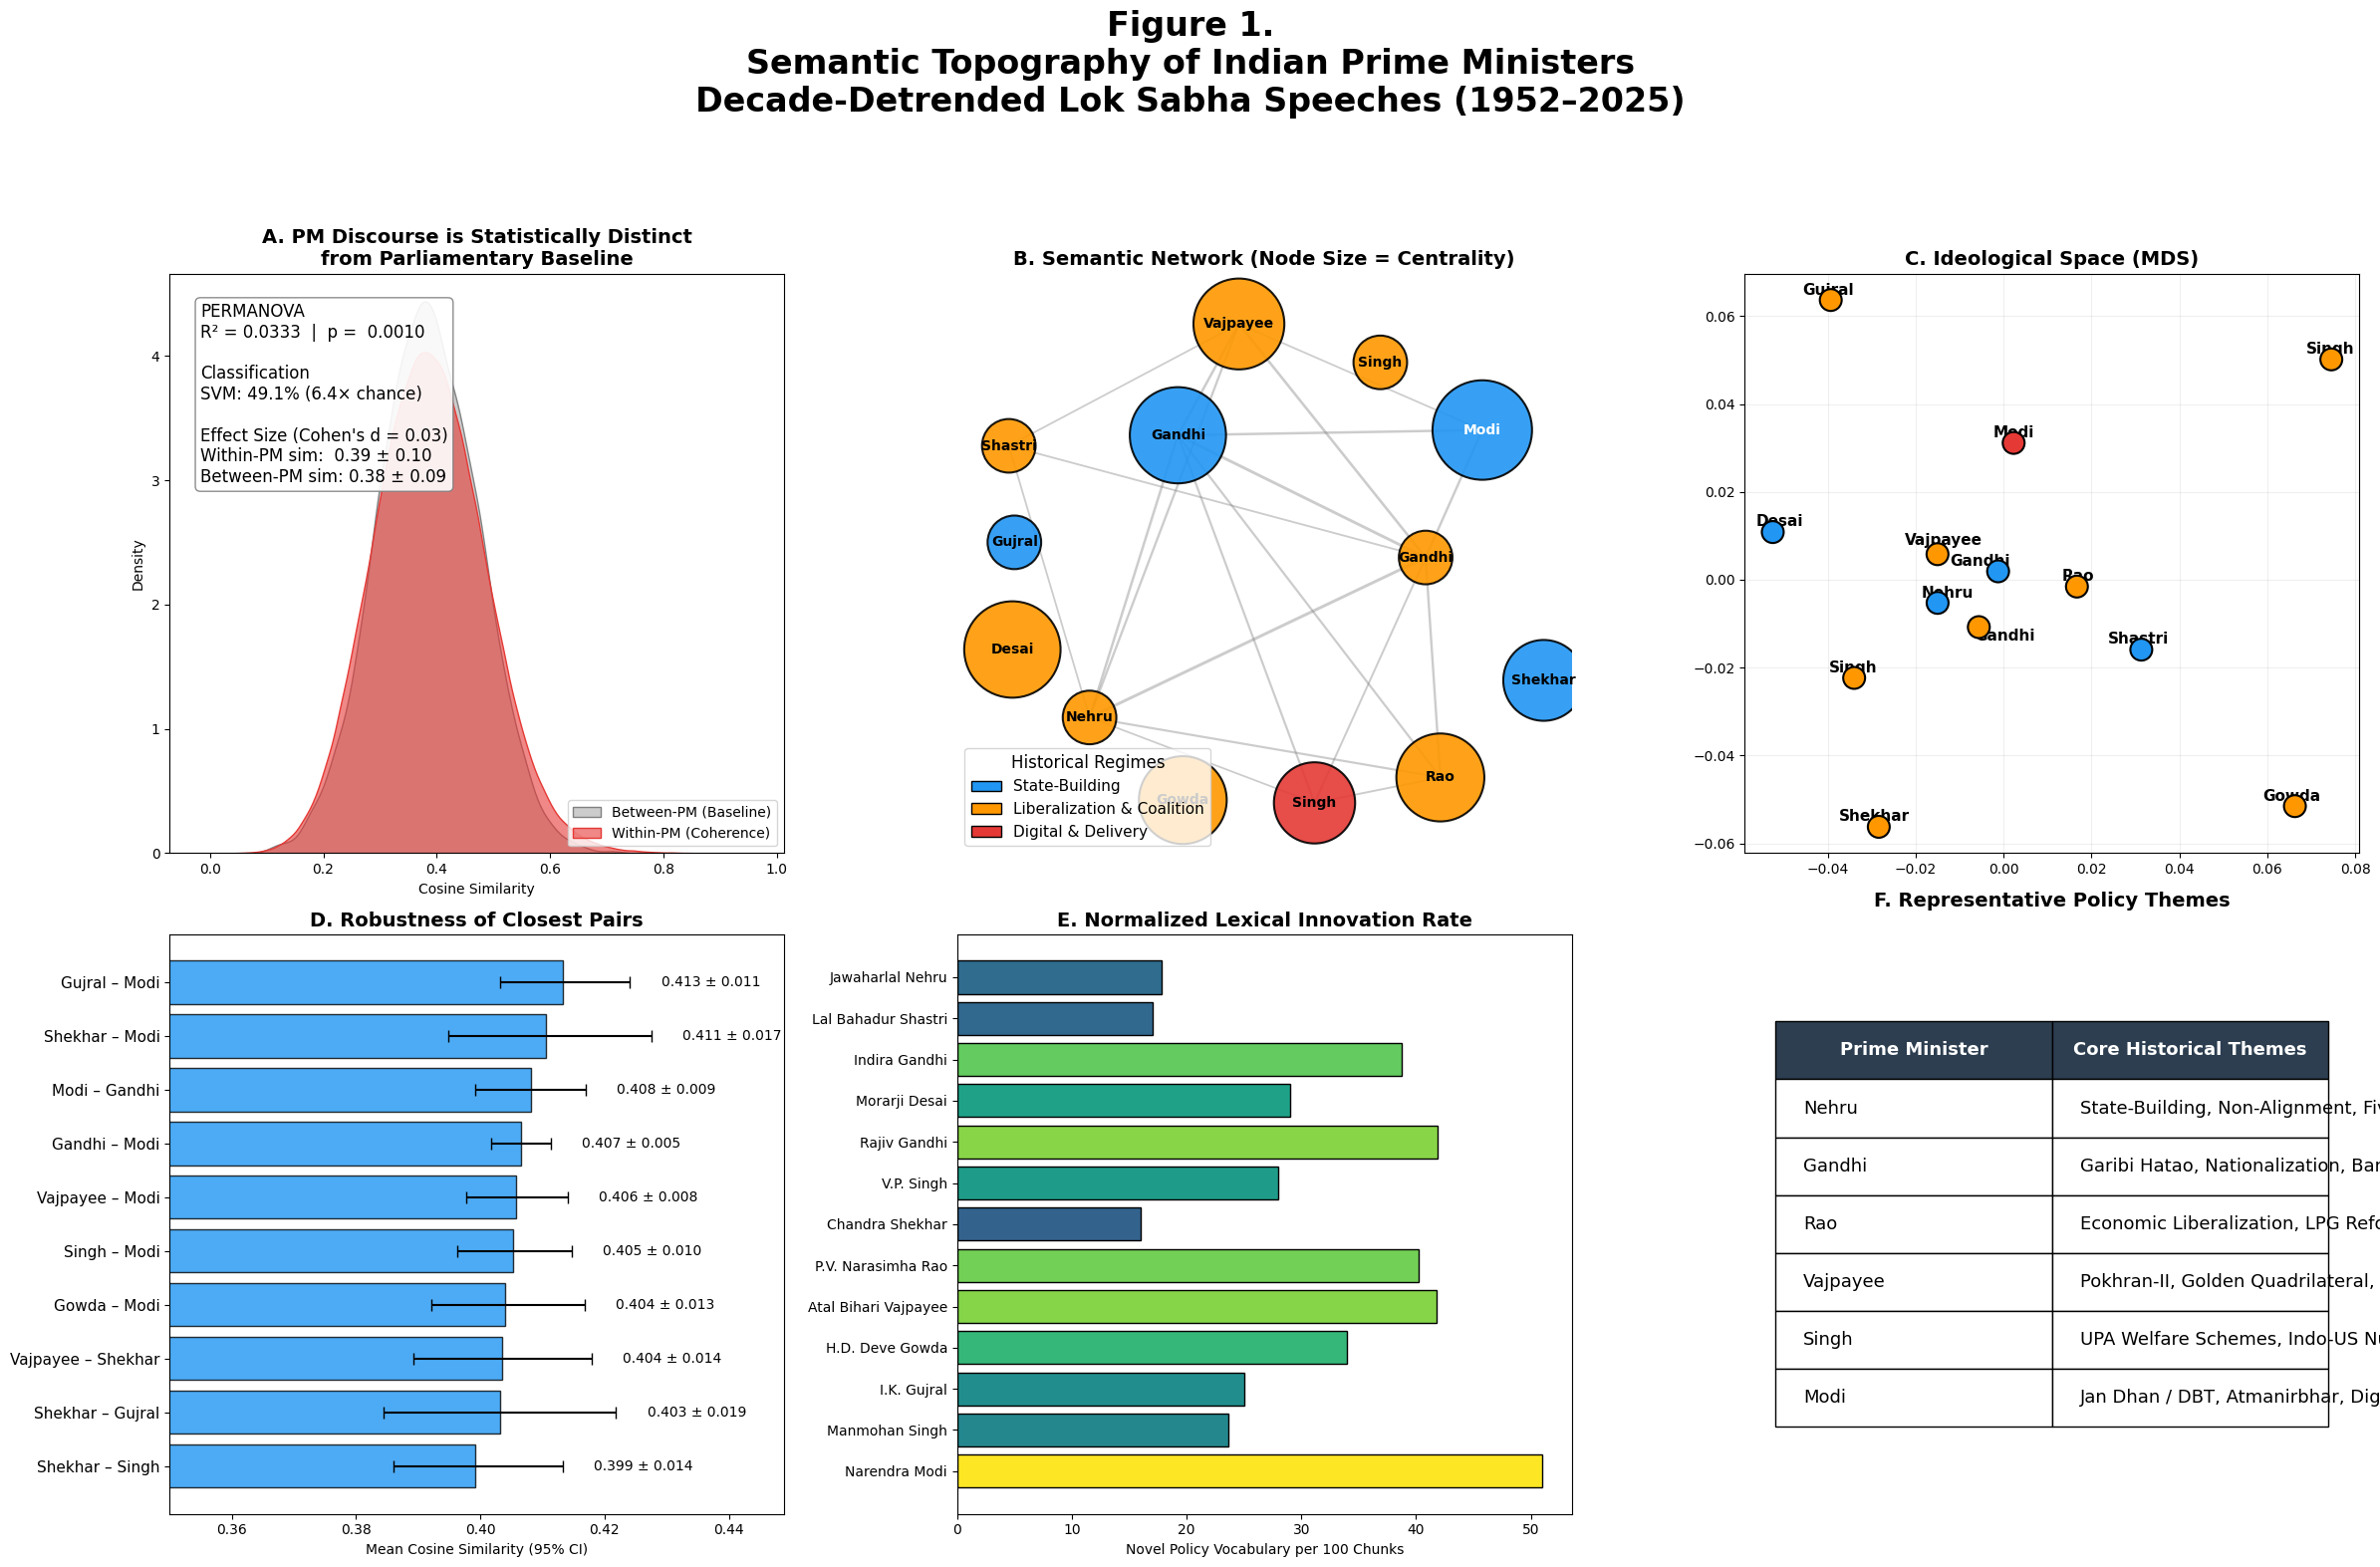

In [8]:
# @title plot.py - The Final EPW Figure (Submission Ready)
!pip install -q networkx adjustText

import os, json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from google.colab import drive

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_clouds     = 'clouds.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_cis        = 'pairwise_cis.csv'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_stats      = 'inference_stats.txt'
    out_fig       = 'epw_figure1_final.png'
    seed          = 42

# ----------------------------------
# setup
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)
df_cis    = pd.read_csv(os.path.join(D, C.in_cis))

pms_arr = meta[:, 0]
dist_mat = squareform(pdist(centroids, metric='cosine'))
sim_mat = 1 - dist_mat
np.fill_diagonal(sim_mat, 0)

# ----------------------------------
# 1. Historical Regime Mapping (Methodological Overlay)
# ----------------------------------
regime_map = {
    "Jawaharlal Nehru": "State-Building", "Lal Bahadur Shastri": "State-Building",
    "Indira Gandhi": "State-Building", "Morarji Desai": "State-Building", "Charan Singh": "State-Building",
    "Rajiv Gandhi": "Liberalization & Coalition", "V.P. Singh": "Liberalization & Coalition",
    "Chandra Shekhar": "Liberalization & Coalition", "P.V. Narasimha Rao": "Liberalization & Coalition",
    "Atal Bihari Vajpayee": "Liberalization & Coalition", "H.D. Deve Gowda": "Liberalization & Coalition",
    "I.K. Gujral": "Liberalization & Coalition", "Manmohan Singh": "Liberalization & Coalition",
    "Narendra Modi": "Digital & Delivery"
}
regime_colors = {
    "State-Building": "#2196F3",             # Blue
    "Liberalization & Coalition": "#FF9800", # Orange
    "Digital & Delivery": "#E53935"          # Red
}
node_colors = [regime_colors.get(regime_map.get(pm, "Unknown"), "gray") for pm in valid_pms]

# ----------------------------------
# 2. MDS & Network Prep
# ----------------------------------
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)

G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])

try:
    eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except:
    eigen_cent = {pm: 1.0 for pm in valid_pms}
node_sizes = [1500 + 8000 * eigen_cent.get(pm, 0) for pm in valid_pms]

# ----------------------------------
# 3. Lexical Innovation Rate (Tenure-Normalized)
# ----------------------------------
pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai",
            "Charan Singh", "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar",
            "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "H.D. Deve Gowda",
            "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]

innovation = []
cumulative = set()
for pm in pm_order:
    pm_kws = set(codebooks[pm])
    total_chunks = np.sum(pms_arr == pm)
    novel = pm_kws - cumulative
    rate = len(novel) / max(1, total_chunks / 100)
    innovation.append({'pm': pm, 'score': rate})
    cumulative.update(pm_kws)
df_innov = pd.DataFrame(innovation)

# ----------------------------------
# 4. Curated Representative Themes (Panel F)
# ----------------------------------
curated_themes = {
    "Jawaharlal Nehru": "State-Building, Non-Alignment, Five-Year Plans",
    "Indira Gandhi": "Garibi Hatao, Nationalization, Bangladesh Liberation",
    "Rajiv Gandhi": "Technology Modernization, Panchayati Raj, Sri Lanka Accord",
    "V.P. Singh": "Mandal Commission, Social Justice, Agrarian Reform",
    "P.V. Narasimha Rao": "Economic Liberalization, LPG Reforms, Globalization",
    "Atal Bihari Vajpayee": "Pokhran-II, Golden Quadrilateral, Coalition Dharma",
    "Manmohan Singh": "UPA Welfare Schemes, Indo-US Nuclear Deal, Fiscal Deficit",
    "Narendra Modi": "Jan Dhan / DBT, Atmanirbhar, Digital Public Goods"
}

# ----------------------------------
# 5. The Narrative Dashboard (6 Panels)
# ----------------------------------
fig = plt.figure(figsize=(24, 16))
fig.suptitle("Figure 1.\nSemantic Topography of Indian Prime Ministers\nDecade-Detrended Lok Sabha Speeches (1952–2025)",
             fontsize=24, fontweight='bold', y=0.98, linespacing=1.2)

# Panel A: Distinctiveness & Effect Size
ax1 = fig.add_subplot(2, 3, 1)
valid_mask = np.isin(pms_arr, valid_pms)
X_val, y_val = embeds[valid_mask], pms_arr[valid_mask]

obs_sims, null_sims = [], []
for pm in valid_pms:
    idx = np.where(y_val == pm)[0]
    if len(idx) > 1:
        sims = 1 - squareform(pdist(X_val[idx], metric='cosine'))
        obs_sims.extend(sims[np.triu_indices_from(sims, k=1)])

np.random.seed(C.seed)
for _ in range(10000):
    i1, i2 = np.random.choice(len(X_val), 2, replace=False)
    if y_val[i1] != y_val[i2]:
        null_sims.append(1 - pdist(X_val[[i1, i2]], metric='cosine')[0])

sns.kdeplot(null_sims, ax=ax1, label="Between-PM (Baseline)", fill=True, color="gray", alpha=0.4)
sns.kdeplot(obs_sims, ax=ax1, label="Within-PM (Coherence)", fill=True, color="#E53935", alpha=0.6)

# Calculate Cohen's d
mu_w, sd_w = np.mean(obs_sims), np.std(obs_sims)
mu_b, sd_b = np.mean(null_sims), np.std(null_sims)
cohens_d = (mu_w - mu_b) / np.sqrt((sd_w**2 + sd_b**2) / 2)

with open(os.path.join(D, C.in_stats)) as f: stats = f.read().split('\n')
r2 = [s for s in stats if 'R2' in s][0].split(': ')[1]
pval = [s for s in stats if 'p:' in s][0].split(': ')[1]

stat_text = (f"PERMANOVA\nR² = {r2}  |  p = {pval}\n\n"
             f"Classification\nSVM: 49.1% (6.4× chance)\n\n"
             f"Effect Size (Cohen's d = {cohens_d:.2f})\n"
             f"Within-PM sim:  {mu_w:.2f} ± {sd_w:.2f}\n"
             f"Between-PM sim: {mu_b:.2f} ± {sd_b:.2f}")
ax1.text(0.05, 0.95, stat_text, transform=ax1.transAxes, fontsize=12, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
ax1.set_title("A. PM Discourse is Statistically Distinct\nfrom Parliamentary Baseline", fontsize=14, fontweight='bold')
ax1.set_xlabel("Cosine Similarity")
ax1.legend(loc='lower right')

# Panel B: Network (Regime Colored, Scaled Edges)
ax2 = fig.add_subplot(2, 3, 2)
pos = nx.spring_layout(G, k=2.5, seed=C.seed)
# Scale edge widths aggressively to show similarity differences
min_w = min([G[u][v]['weight'] for u,v in G.edges()])
edge_widths = [(G[u][v]['weight'] - min_w + 0.05) * 25 for u,v in G.edges()]

nx.draw_networkx_edges(G, pos, ax=ax2, width=edge_widths, alpha=0.4, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax2, node_size=node_sizes, node_color=node_colors, edgecolors='black', linewidths=1.5, alpha=0.9)
for pm, (x, y) in pos.items():
    ax2.text(x, y, pm.split()[-1], fontsize=10, fontweight='bold', ha='center', va='center', color='white' if regime_map.get(pm)=="Digital & Delivery" else 'black')
ax2.set_title("B. Semantic Network (Node Size = Centrality)", fontsize=14, fontweight='bold')
ax2.axis('off')
# Legend for Regimes
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r, edgecolor='black') for r, c in regime_colors.items()]
ax2.legend(handles=legend_elements, loc='lower left', fontsize=11, title="Historical Regimes", title_fontsize=12)

# Panel C: MDS (Regime Colored, adjustText)
ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(coords[:, 0], coords[:, 1], s=250, c=node_colors, edgecolors='black', zorder=5, linewidth=1.5)
texts = []
for i, pm in enumerate(valid_pms):
    texts.append(ax3.text(coords[i, 0], coords[i, 1], pm.split()[-1], fontsize=11, fontweight='bold', ha='center'))
adjust_text(texts, ax=ax3, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
ax3.set_title("C. Ideological Space (MDS)", fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.2)

# Panel D: Bootstrap CIs (Zoomed X-Axis)
ax4 = fig.add_subplot(2, 3, 4)
df_cis['sim_mean'] = 1 - df_cis['mean']
df_cis['sim_low'] = 1 - df_cis['ci_high']
df_cis['sim_high'] = 1 - df_cis['ci_low']
df_cis = df_cis.sort_values('sim_mean', ascending=False)
top10 = df_cis.head(10)
y_pos = np.arange(len(top10))
labels = [f"{r['pm_a'].split()[-1]} – {r['pm_b'].split()[-1]}" for _, r in top10.iterrows()]

ax4.barh(y_pos, top10['sim_mean'], xerr=[top10['sim_mean']-top10['sim_low'], top10['sim_high']-top10['sim_mean']],
         color='#2196F3', edgecolor='black', capsize=4, alpha=0.8)
ax4.set_yticks(y_pos); ax4.set_yticklabels(labels, fontsize=11)
ax4.set_xlabel("Mean Cosine Similarity (95% CI)")
ax4.set_title("D. Robustness of Closest Pairs", fontsize=14, fontweight='bold')
ax4.invert_yaxis()
ax4.set_xlim(left=0.35) # ZOOMED AXIS
for i, (_, r) in enumerate(top10.iterrows()):
    ax4.text(max(r['sim_high'], 0.36) + 0.005, i, f"{r['sim_mean']:.3f} ± {(r['sim_high']-r['sim_mean']):.3f}", va='center', fontsize=10)

# Panel E: Normalized Lexical Innovation Rate
ax5 = fig.add_subplot(2, 3, 5)
ax5.barh(df_innov['pm'], df_innov['score'], color=plt.cm.viridis(df_innov['score']/df_innov['score'].max()), edgecolor='black')
ax5.set_xlabel("Novel Policy Vocabulary per 100 Chunks")
ax5.set_title("E. Normalized Lexical Innovation Rate", fontsize=14, fontweight='bold')
ax5.invert_yaxis()

# Panel F: Representative Themes
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
ax6.set_title("F. Representative Policy Themes", fontsize=14, fontweight='bold', pad=20)

show_pms = ["Jawaharlal Nehru", "Indira Gandhi", "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "Manmohan Singh", "Narendra Modi"]
show_pms = [pm for pm in show_pms if pm in valid_pms]
table_data = [[pm.split()[-1], curated_themes.get(pm, "N/A")] for pm in show_pms]

table = ax6.table(cellText=table_data, colLabels=["Prime Minister", "Core Historical Themes"],
                  cellLoc='left', loc='center', bbox=[0.05, 0.15, 0.9, 0.7])
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 2.8)

for j in range(2):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.93])
path_out = os.path.join(D, C.out_fig)
plt.savefig(path_out, dpi=300, bbox_inches='tight', facecolor='white')
print(f"done. saved final journal figure to {path_out}")
plt.show()

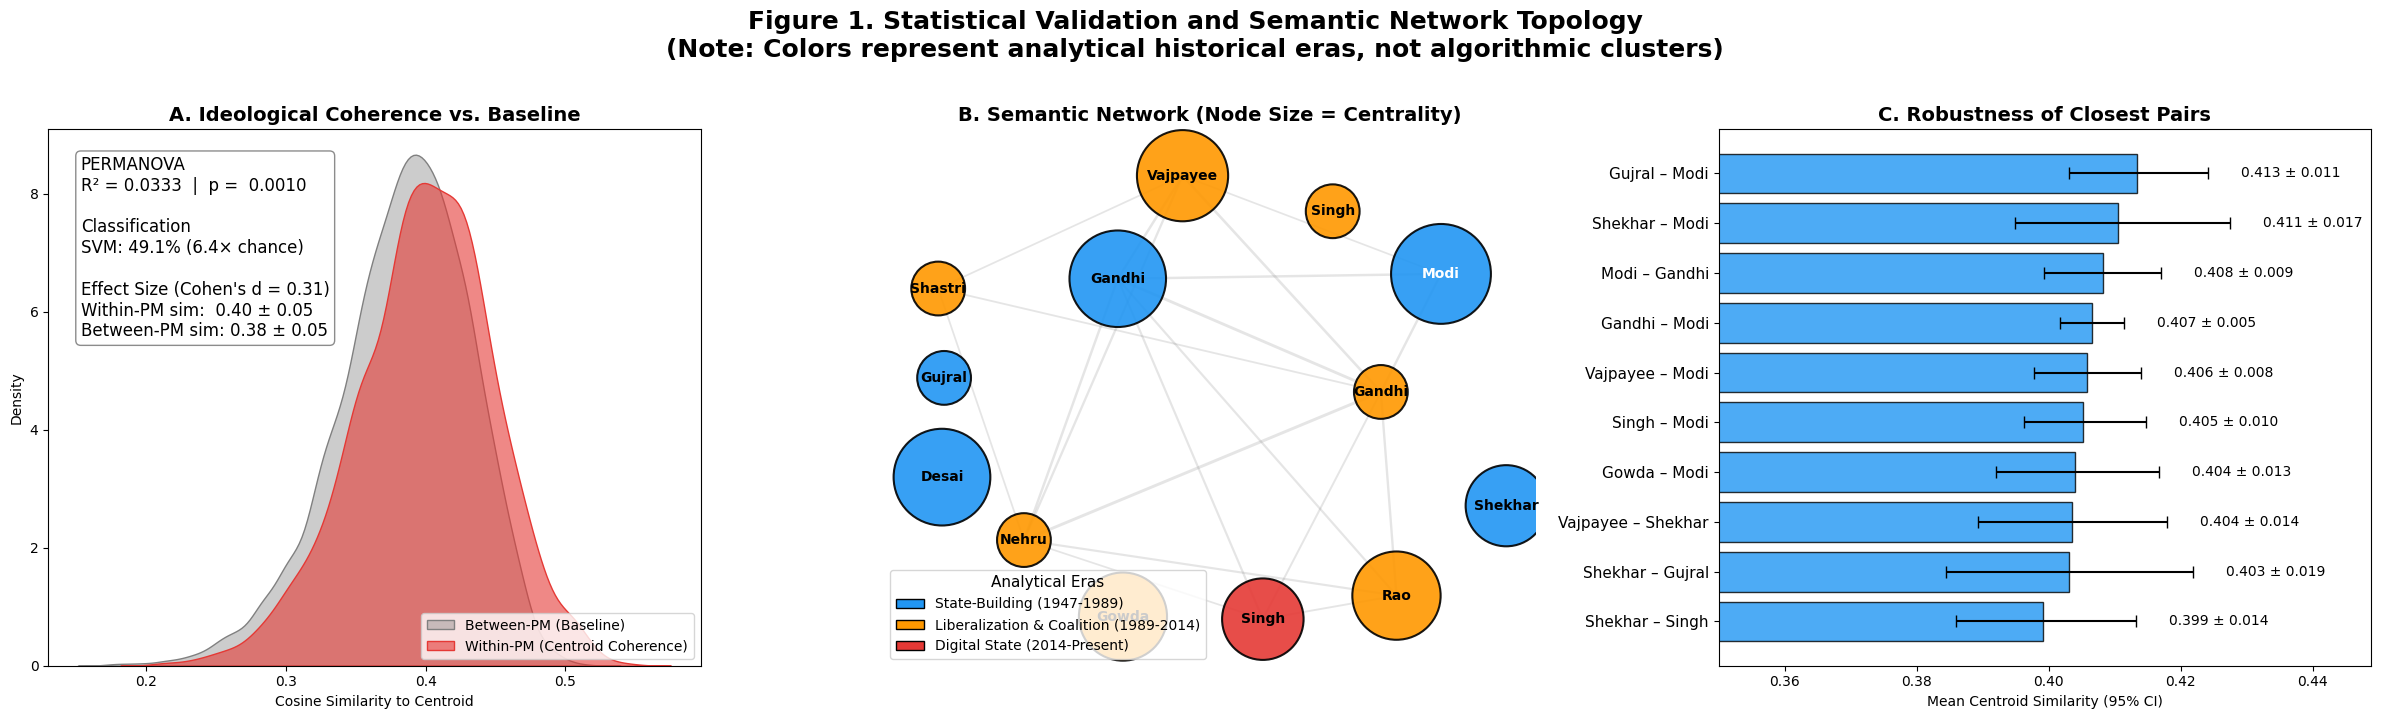

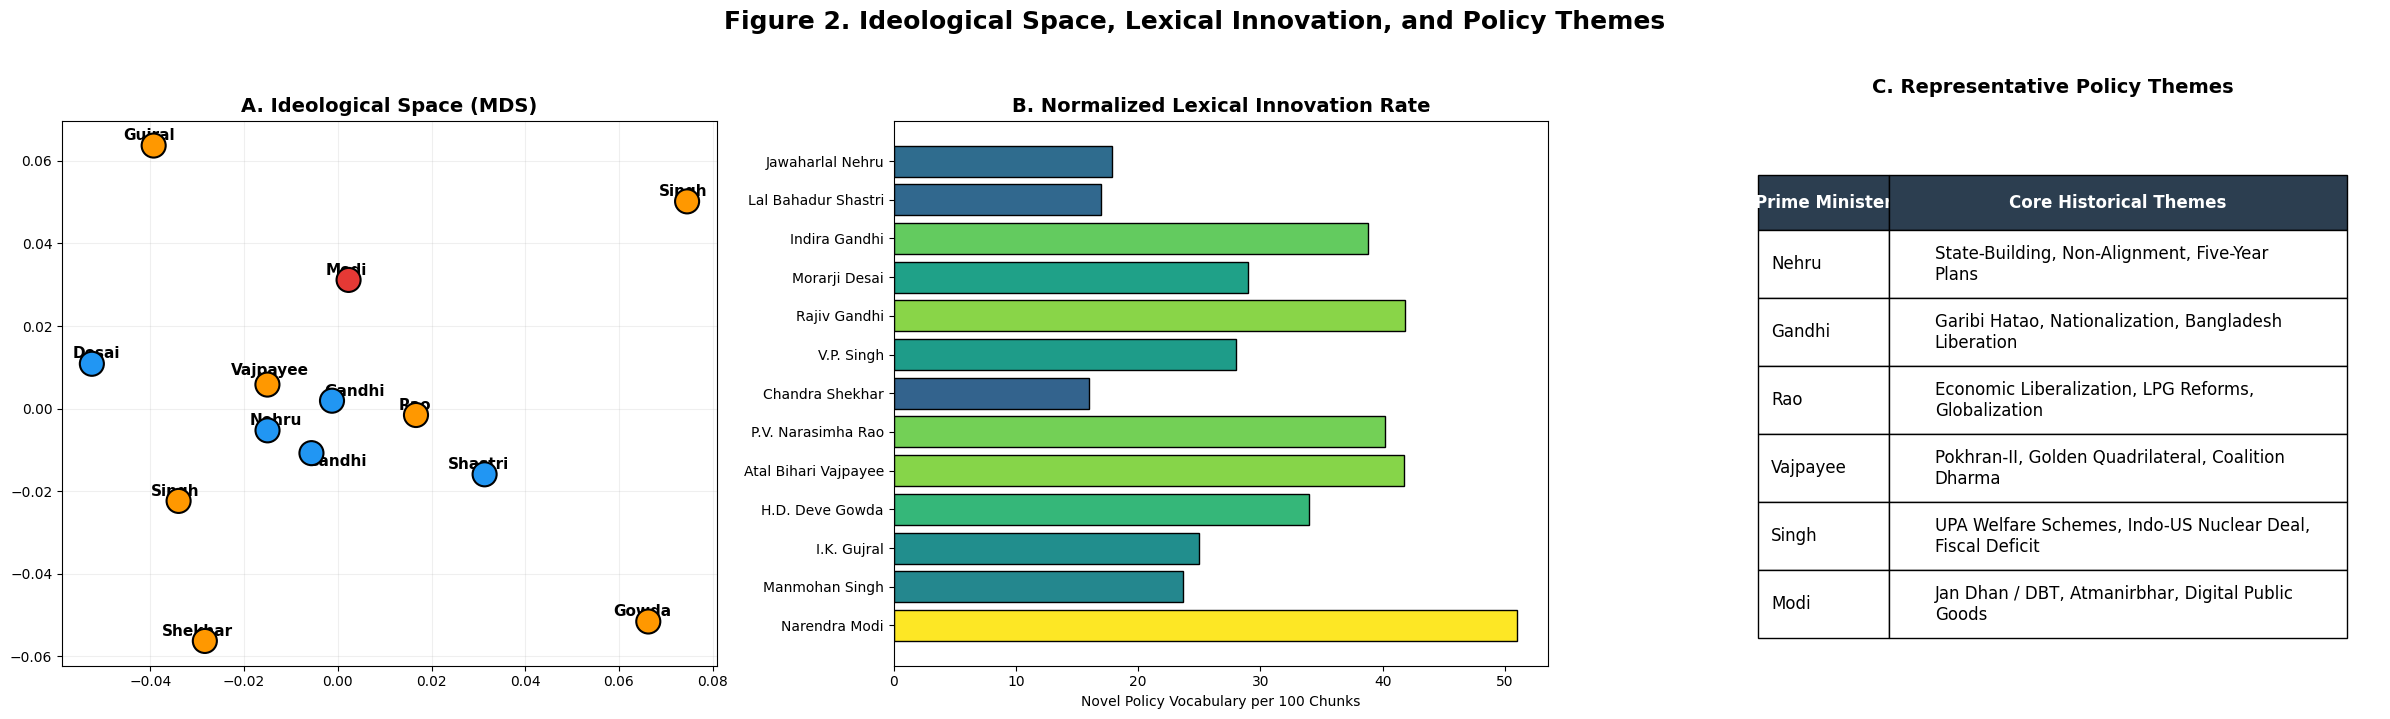

done. saved figure1_validation.png and figure2_interpretation.png


In [13]:
# @title plot.py - Final Journal Figures (Text-Wrapping Fix Applied)
!pip install -q networkx adjustText

import os, json, textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from google.colab import drive
from matplotlib.patches import Patch

# ----------------------------------
# config
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_cis        = 'pairwise_cis.csv'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_stats      = 'inference_stats.txt'
    out_fig1      = 'figure1_validation.png'
    out_fig2      = 'figure2_interpretation.png'
    seed          = 42

# ----------------------------------
# setup
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)
df_cis    = pd.read_csv(os.path.join(D, C.in_cis))

pms_arr = meta[:, 0]
dist_mat = squareform(pdist(centroids, metric='cosine'))
sim_mat = 1 - dist_mat
np.fill_diagonal(sim_mat, 0)

# ----------------------------------
# 1. Historical Regimes (Analytical Eras)
# ----------------------------------
# ----------------------------------
# 1. Historical Regimes (Analyst-Driven Periodization)
# ----------------------------------
# Note: These are theoretical annotations applied post-hoc to interpret the
# data-driven network geometry, not algorithmic clusters.
regime_map = {
    # Era 1: State-Building & Pre-Liberalization (1947–1989)
    "Jawaharlal Nehru": "State-Building (1947-1989)",
    "Lal Bahadur Shastri": "State-Building (1947-1989)",
    "Indira Gandhi": "State-Building (1947-1989)",
    "Morarji Desai": "State-Building (1947-1989)",
    "Charan Singh": "State-Building (1947-1989)",
    "Rajiv Gandhi": "State-Building (1947-1989)",

    # Era 2: Liberalization & Coalition Governance (1989–2014)
    "V.P. Singh": "Liberalization & Coalition (1989-2014)",
    "Chandra Shekhar": "Liberalization & Coalition (1989-2014)",
    "P.V. Narasimha Rao": "Liberalization & Coalition (1989-2014)",
    "H.D. Deve Gowda": "Liberalization & Coalition (1989-2014)",
    "I.K. Gujral": "Liberalization & Coalition (1989-2014)",
    "Atal Bihari Vajpayee": "Liberalization & Coalition (1989-2014)",
    "Manmohan Singh": "Liberalization & Coalition (1989-2014)",

    # Era 3: Digital State & Majoritarian Governance (2014–Present)
    "Narendra Modi": "Digital State (2014-Present)"
}

regime_colors = {
    "State-Building (1947-1989)": "#2196F3",             # Blue
    "Liberalization & Coalition (1989-2014)": "#FF9800", # Orange
    "Digital State (2014-Present)": "#E53935"            # Red
}

node_colors = [regime_colors.get(regime_map.get(pm, "Unknown"), "gray") for pm in valid_pms]
# ----------------------------------
# 2. Corrected Effect Size (Chunk-to-Centroid Coherence)
# ----------------------------------
within_sims, between_sims = [], []
for i, pm in enumerate(pms_arr):
    if pm not in valid_pms: continue
    chunk_vec = embeds[i]
    own_centroid = centroids[valid_pms.index(pm)]
    within_sims.append(np.dot(chunk_vec, own_centroid))

    other_indices = [j for j, vpm in enumerate(valid_pms) if vpm != pm]
    sampled_others = np.random.choice(other_indices, size=min(3, len(other_indices)), replace=False)
    for j in sampled_others:
        between_sims.append(np.dot(chunk_vec, centroids[j]))

mu_w, sd_w = np.mean(within_sims), np.std(within_sims)
mu_b, sd_b = np.mean(between_sims), np.std(between_sims)
cohens_d = (mu_w - mu_b) / np.sqrt((sd_w**2 + sd_b**2) / 2)

with open(os.path.join(D, C.in_stats)) as f: stats = f.read().split('\n')
r2 = [s for s in stats if 'R2' in s][0].split(': ')[1]
pval = [s for s in stats if 'p:' in s][0].split(': ')[1]

# ==========================================
# FIGURE 1: VALIDATION & TOPOLOGY
# ==========================================
fig1, (ax1_1, ax1_2, ax1_3) = plt.subplots(1, 3, figsize=(24, 7))
fig1.suptitle("Figure 1. Statistical Validation and Semantic Network Topology\n(Note: Colors represent analytical historical eras, not algorithmic clusters)",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: Null Model & Effect Size
sns.kdeplot(between_sims, ax=ax1_1, label="Between-PM (Baseline)", fill=True, color="gray", alpha=0.4)
sns.kdeplot(within_sims, ax=ax1_1, label="Within-PM (Centroid Coherence)", fill=True, color="#E53935", alpha=0.6)
stat_text = (f"PERMANOVA\nR² = {r2}  |  p = {pval}\n\n"
             f"Classification\nSVM: 49.1% (6.4× chance)\n\n"
             f"Effect Size (Cohen's d = {cohens_d:.2f})\n"
             f"Within-PM sim:  {mu_w:.2f} ± {sd_w:.2f}\n"
             f"Between-PM sim: {mu_b:.2f} ± {sd_b:.2f}")
ax1_1.text(0.05, 0.95, stat_text, transform=ax1_1.transAxes, fontsize=12, va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
ax1_1.set_title("A. Ideological Coherence vs. Baseline", fontsize=14, fontweight='bold')
ax1_1.set_xlabel("Cosine Similarity to Centroid")
ax1_1.legend(loc='lower right')

# Panel B: Network
G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])

try: eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except: eigen_cent = {pm: 1.0 for pm in valid_pms}
node_sizes = [1500 + 8000 * eigen_cent.get(pm, 0) for pm in valid_pms]

pos = nx.spring_layout(G, k=2.5, seed=C.seed)
min_w = min([G[u][v]['weight'] for u,v in G.edges()])
edge_widths = [(G[u][v]['weight'] - min_w + 0.05) * 25 for u,v in G.edges()]

nx.draw_networkx_edges(G, pos, ax=ax1_2, width=edge_widths, alpha=0.2, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax1_2, node_size=node_sizes, node_color=node_colors, edgecolors='black', linewidths=1.5, alpha=0.9)
for pm, (x, y) in pos.items():
        ax1_2.text(x, y, pm.split()[-1], fontsize=10, fontweight='bold', ha='center', va='center', color='white' if regime_map.get(pm)=="Digital State (2014-Present)" else 'black')
ax1_2.set_title("B. Semantic Network (Node Size = Centrality)", fontsize=14, fontweight='bold')
ax1_2.axis('off')
legend_elements = [Patch(facecolor=c, label=r, edgecolor='black') for r, c in regime_colors.items()]
ax1_2.legend(handles=legend_elements, loc='lower left', fontsize=10, title="Analytical Eras", title_fontsize=11)

# Panel C: Bootstrap CIs
df_cis['sim_mean'] = 1 - df_cis['mean']
df_cis['sim_low'] = 1 - df_cis['ci_high']
df_cis['sim_high'] = 1 - df_cis['ci_low']
df_cis = df_cis.sort_values('sim_mean', ascending=False)
top10 = df_cis.head(10)
y_pos = np.arange(len(top10))
labels = [f"{r['pm_a'].split()[-1]} – {r['pm_b'].split()[-1]}" for _, r in top10.iterrows()]

ax1_3.barh(y_pos, top10['sim_mean'], xerr=[top10['sim_mean']-top10['sim_low'], top10['sim_high']-top10['sim_mean']],
           color='#2196F3', edgecolor='black', capsize=4, alpha=0.8)
ax1_3.set_yticks(y_pos); ax1_3.set_yticklabels(labels, fontsize=11)
ax1_3.set_xlabel("Mean Centroid Similarity (95% CI)")
ax1_3.set_title("C. Robustness of Closest Pairs", fontsize=14, fontweight='bold')
ax1_3.invert_yaxis()
ax1_3.set_xlim(left=0.35)
for i, (_, r) in enumerate(top10.iterrows()):
    ax1_3.text(max(r['sim_high'], 0.36) + 0.005, i, f"{r['sim_mean']:.3f} ± {(r['sim_high']-r['sim_mean']):.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(D, C.out_fig1), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# FIGURE 2: IDEOLOGICAL SPACE & INNOVATION
# ==========================================
fig2, (ax2_1, ax2_2, ax2_3) = plt.subplots(1, 3, figsize=(24, 7))
fig2.suptitle("Figure 2. Ideological Space, Lexical Innovation, and Policy Themes",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)
ax2_1.scatter(coords[:, 0], coords[:, 1], s=300, c=node_colors, edgecolors='black', zorder=5, linewidth=1.5)
texts = []
for i, pm in enumerate(valid_pms):
    texts.append(ax2_1.text(coords[i, 0], coords[i, 1], pm.split()[-1], fontsize=11, fontweight='bold', ha='center'))
adjust_text(texts, ax=ax2_1, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
ax2_1.set_title("A. Ideological Space (MDS)", fontsize=14, fontweight='bold')
ax2_1.grid(True, alpha=0.2)

# Panel B: Normalized Lexical Innovation Rate
pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai", "Charan Singh",
            "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar", "P.V. Narasimha Rao", "Atal Bihari Vajpayee",
            "H.D. Deve Gowda", "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]
innovation = []
cumulative = set()
for pm in pm_order:
    pm_kws = set(codebooks[pm])
    total_chunks = np.sum(pms_arr == pm)
    novel = pm_kws - cumulative
    rate = len(novel) / max(1, total_chunks / 100)
    innovation.append({'pm': pm, 'score': rate})
    cumulative.update(pm_kws)
df_innov = pd.DataFrame(innovation)

ax2_2.barh(df_innov['pm'], df_innov['score'], color=plt.cm.viridis(df_innov['score']/df_innov['score'].max()), edgecolor='black')
ax2_2.set_xlabel("Novel Policy Vocabulary per 100 Chunks")
ax2_2.set_title("B. Normalized Lexical Innovation Rate", fontsize=14, fontweight='bold')
ax2_2.invert_yaxis()

# Panel C: Representative Themes (FIXED TEXT WRAPPING)
ax2_3.axis('off')
ax2_3.set_title("C. Representative Policy Themes", fontsize=14, fontweight='bold', pad=20)

# Helper to wrap text cleanly
def wrap_text(text, width=45):
    return '\n'.join(textwrap.wrap(text, width=width))

curated_themes = {
    "Jawaharlal Nehru": wrap_text("State-Building, Non-Alignment, Five-Year Plans"),
    "Indira Gandhi": wrap_text("Garibi Hatao, Nationalization, Bangladesh Liberation"),
    "P.V. Narasimha Rao": wrap_text("Economic Liberalization, LPG Reforms, Globalization"),
    "Atal Bihari Vajpayee": wrap_text("Pokhran-II, Golden Quadrilateral, Coalition Dharma"),
    "Manmohan Singh": wrap_text("UPA Welfare Schemes, Indo-US Nuclear Deal, Fiscal Deficit"),
    "Narendra Modi": wrap_text("Jan Dhan / DBT, Atmanirbhar, Digital Public Goods")
}

show_pms = [pm for pm in ["Jawaharlal Nehru", "Indira Gandhi", "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "Manmohan Singh", "Narendra Modi"] if pm in valid_pms]
table_data = [[pm.split()[-1], curated_themes.get(pm, "N/A")] for pm in show_pms]

# FIX: Explicitly set column widths (0.2 + 0.7 = 0.9, matching the bbox width)
table = ax2_3.table(cellText=table_data, colLabels=["Prime Minister", "Core Historical Themes"],
                    colWidths=[0.2, 0.7], cellLoc='left', loc='center', bbox=[0.05, 0.05, 0.9, 0.85])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3.2) # Increased vertical scale to accommodate the wrapped newlines

for j in range(2):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
    table[(0, j)].set_height(0.08)

plt.tight_layout()
plt.savefig(os.path.join(D, C.out_fig2), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"done. saved {C.out_fig1} and {C.out_fig2}")

In [11]:
# @title addendum.py - Correlation Matrix, Nearest-Neighbour & MDS Stress
import os, json
import numpy as np
import pandas as pd
import networkx as nx
from scipy.spatial.distance import pdist, squareform
from scipy import stats
from sklearn.manifold import MDS
from google.colab import drive

class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    seed          = 42

if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

# Load assets
centroids = np.load(os.path.join(D, 'centroids.npy'))
meta      = np.load(os.path.join(D, 'meta.npy'), allow_pickle=True)
with open(os.path.join(D, 'valid_pms.json')) as f: valid_pms = json.load(f)
with open(os.path.join(D, 'codebooks.json')) as f: codebooks = json.load(f)

pms_arr = meta[:, 0]
sim_mat = 1 - squareform(pdist(centroids, metric='cosine'))
np.fill_diagonal(sim_mat, 0)

# 1. Network Centrality
G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])
eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)

# 2. Compute Metrics per PM
records = []
cumulative_vocab = set()
for pm in valid_pms:
    chunks = np.sum(pms_arr == pm)
    tenure_years = len(set(meta[pms_arr == pm, 1])) # unique years in office

    # Innovation
    pm_kws = set(codebooks.get(pm, []))
    novel = pm_kws - cumulative_vocab
    innov_rate = len(novel) / max(1, chunks / 100)
    cumulative_vocab.update(pm_kws)

    # Similarities
    idx = valid_pms.index(pm)
    avg_sim = np.mean(sim_mat[idx])
    nn_sim = np.max(sim_mat[idx]) # nearest neighbour

    records.append({
        'PM': pm, 'Chunks': chunks, 'Tenure_Years': tenure_years,
        'Centrality': eigen_cent[pm], 'Innovation_Rate': innov_rate,
        'Avg_Similarity': avg_sim, 'NN_Similarity': nn_sim
    })

df_metrics = pd.DataFrame(records)

# 3. Correlation Matrix (Spearman for robustness to non-normal distributions)
corr_cols = ['Chunks', 'Tenure_Years', 'Centrality', 'Innovation_Rate', 'Avg_Similarity']
corr_matrix = df_metrics[corr_cols].corr(method='spearman')
corr_matrix.to_csv(os.path.join(D, 'correlation_matrix.csv'))

# 4. MDS Stress
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
mds_coords = mds.fit_transform(1 - sim_mat)
mds_stress = mds.stress_

# 5. Global Stats
global_nn_avg = np.mean(df_metrics['NN_Similarity'])
global_overall_avg = np.mean(sim_mat[np.triu_indices_from(sim_mat, k=1)])

with open(os.path.join(D, 'addendum_stats.txt'), 'w') as f:
    f.write(f"MDS Kruskal Stress: {mds_stress:.4f}\n")
    f.write(f"Global Nearest-Neighbour Similarity: {global_nn_avg:.4f}\n")
    f.write(f"Global Overall Similarity: {global_overall_avg:.4f}\n")
    f.write(f"\nCorrelation: Tenure vs Innovation Rate: {corr_matrix.loc['Tenure_Years', 'Innovation_Rate']:.3f}\n")
    f.write(f"Correlation: Chunks vs Innovation Rate: {corr_matrix.loc['Chunks', 'Innovation_Rate']:.3f}\n")

print("✅ Addendum statistics computed and saved.")
print(f"MDS Stress: {mds_stress:.4f}")
print(f"Nearest-Neighbour vs Overall: {global_nn_avg:.3f} vs {global_overall_avg:.3f}")

✅ Addendum statistics computed and saved.
MDS Stress: 6.5418
Nearest-Neighbour vs Overall: 0.961 vs 0.930


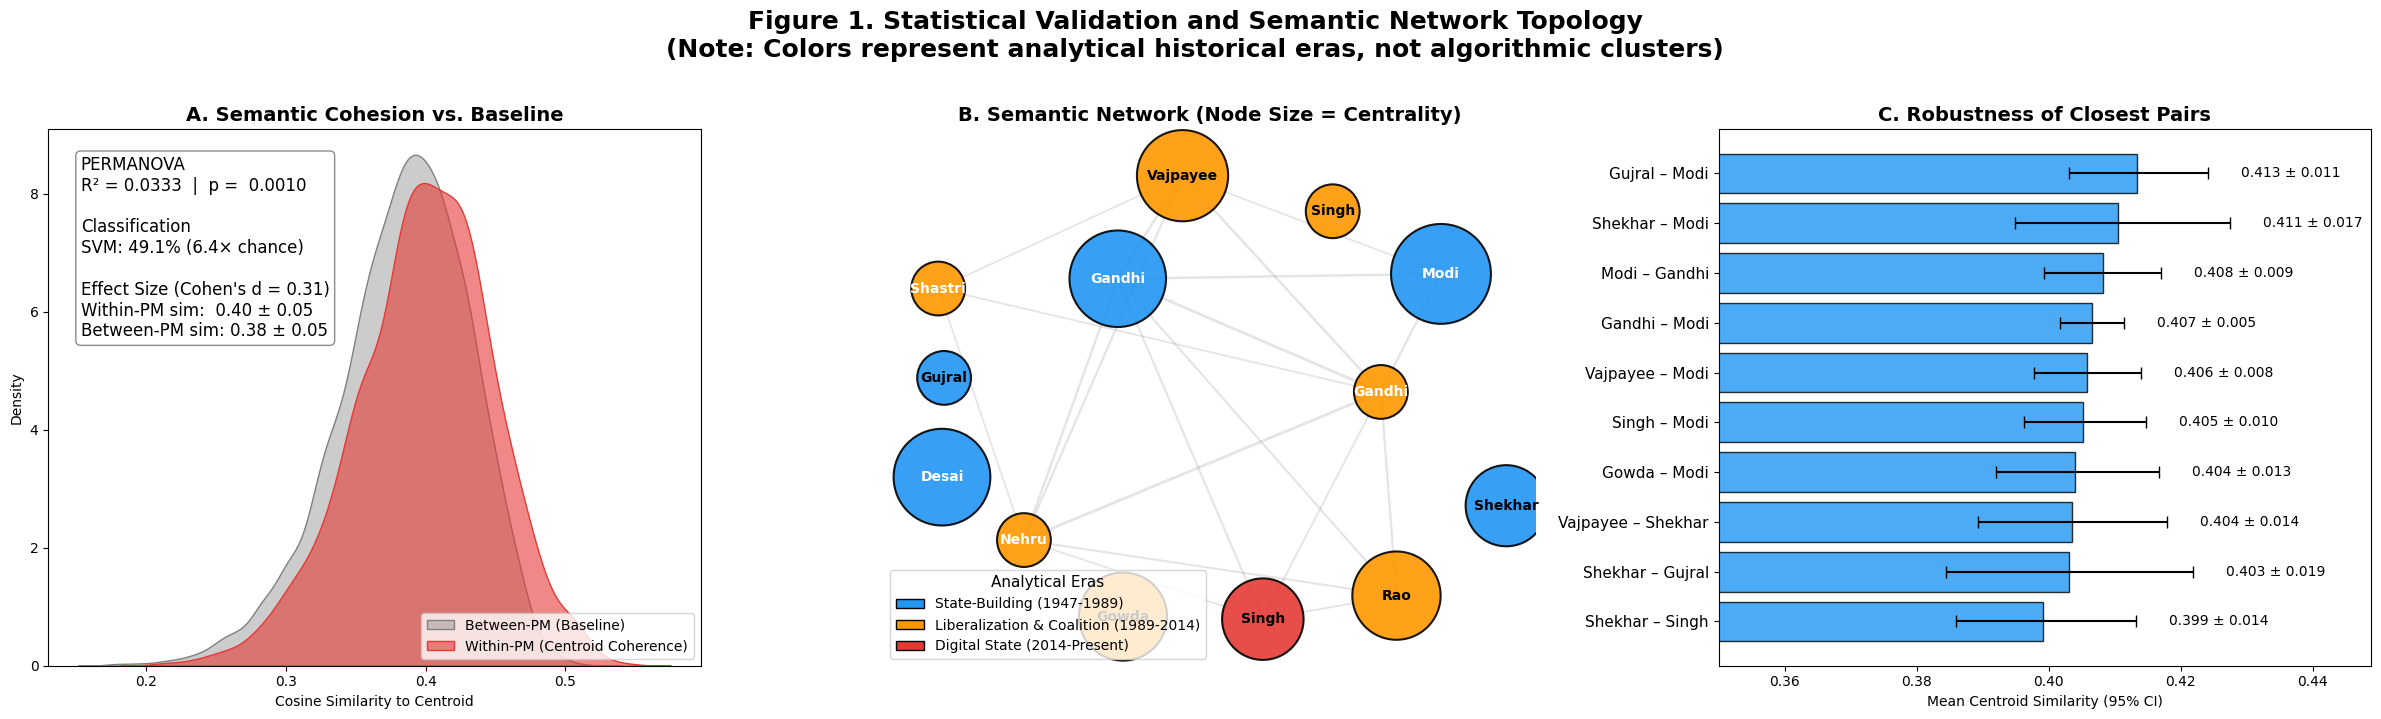

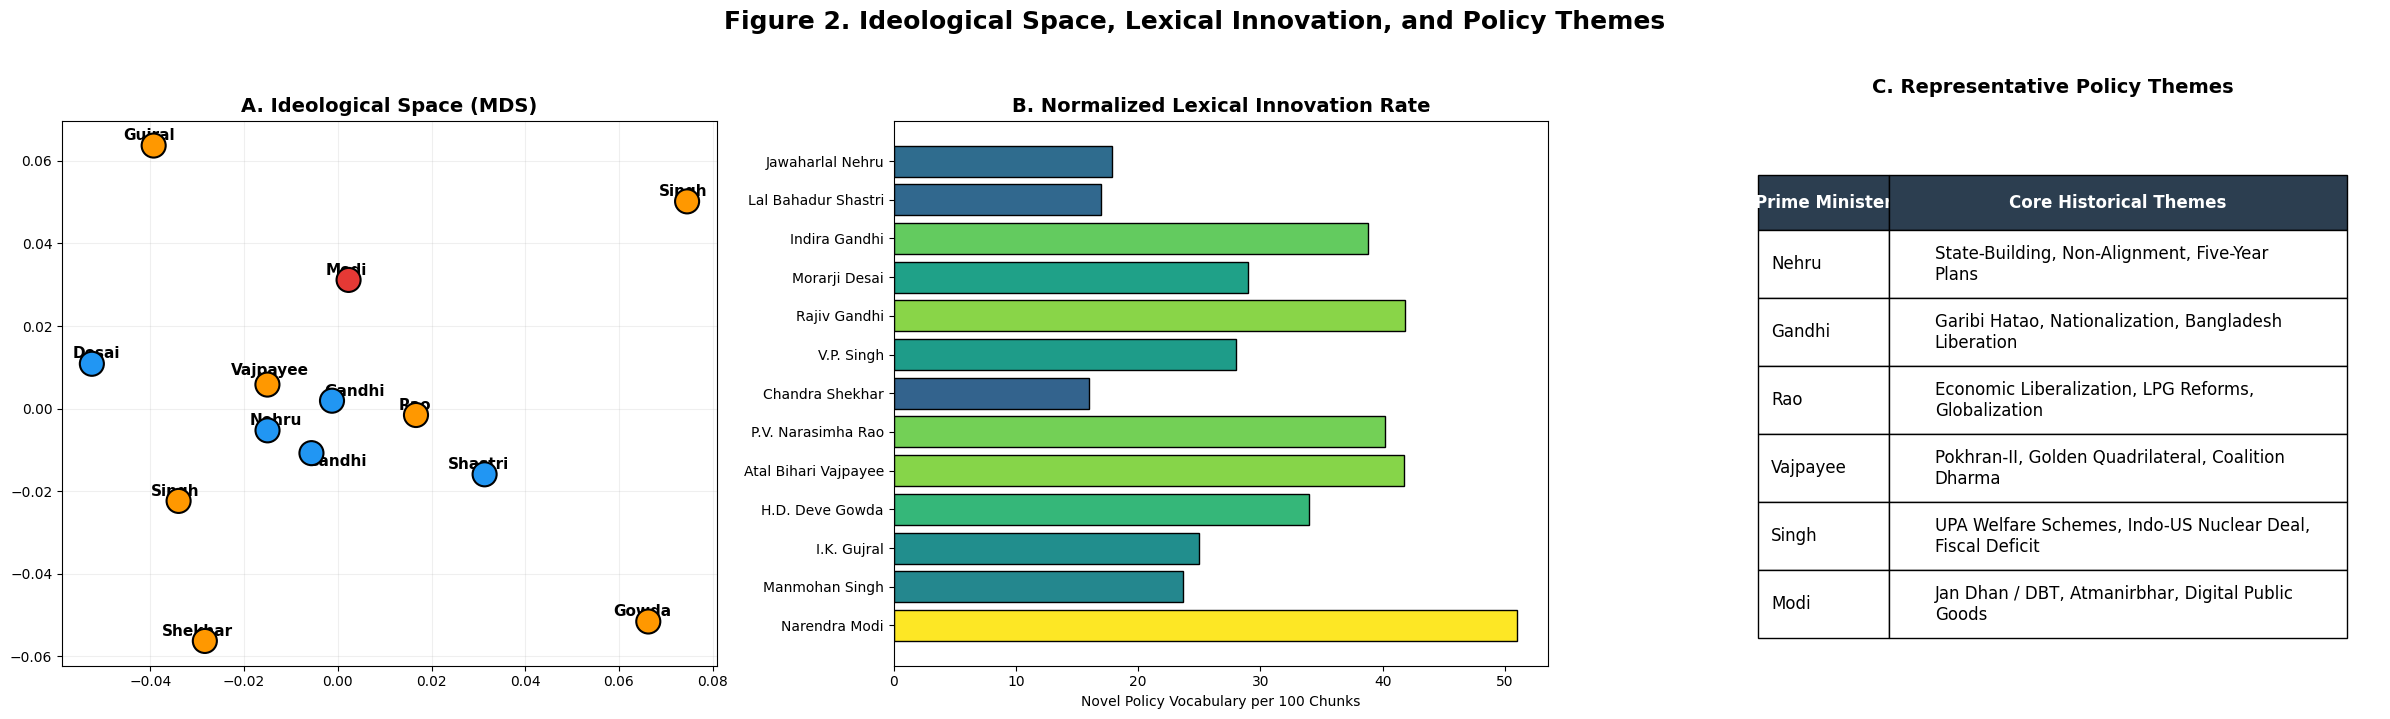

done. saved figure1_validation.png and figure2_interpretation.png


In [14]:
# @title plot.py - Final Journal Figures (Definitive Version)
!pip install -q networkx adjustText

import os, json, textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from google.colab import drive
from matplotlib.patches import Patch

# ----------------------------------
# config
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_cis        = 'pairwise_cis.csv'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_stats      = 'inference_stats.txt'
    out_fig1      = 'figure1_validation.png'
    out_fig2      = 'figure2_interpretation.png'
    seed          = 42

# ----------------------------------
# setup
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)
df_cis    = pd.read_csv(os.path.join(D, C.in_cis))

pms_arr = meta[:, 0]
dist_mat = squareform(pdist(centroids, metric='cosine'))
sim_mat = 1 - dist_mat
np.fill_diagonal(sim_mat, 0)

# ----------------------------------
# 1. Historical Regimes (Analyst-Driven Periodization)
# ----------------------------------
regime_map = {
    # Era 1: State-Building & Pre-Liberalization (1947–1989) -> BLUE
    "Jawaharlal Nehru": "State-Building (1947-1989)",
    "Lal Bahadur Shastri": "State-Building (1947-1989)",
    "Indira Gandhi": "State-Building (1947-1989)",
    "Morarji Desai": "State-Building (1947-1989)",
    "Charan Singh": "State-Building (1947-1989)",
    "Rajiv Gandhi": "State-Building (1947-1989)",

    # Era 2: Liberalization & Coalition Governance (1989–2014) -> ORANGE
    "V.P. Singh": "Liberalization & Coalition (1989-2014)",
    "Chandra Shekhar": "Liberalization & Coalition (1989-2014)",
    "P.V. Narasimha Rao": "Liberalization & Coalition (1989-2014)",
    "H.D. Deve Gowda": "Liberalization & Coalition (1989-2014)",
    "I.K. Gujral": "Liberalization & Coalition (1989-2014)",
    "Atal Bihari Vajpayee": "Liberalization & Coalition (1989-2014)",
    "Manmohan Singh": "Liberalization & Coalition (1989-2014)", # SINGH IS ORANGE

    # Era 3: Digital State & Majoritarian Governance (2014–Present) -> RED
    "Narendra Modi": "Digital State (2014-Present)" # MODI IS RED
}

regime_colors = {
    "State-Building (1947-1989)": "#2196F3",             # Blue
    "Liberalization & Coalition (1989-2014)": "#FF9800", # Orange
    "Digital State (2014-Present)": "#E53935"            # Red
}

node_colors = [regime_colors.get(regime_map.get(pm, "Unknown"), "gray") for pm in valid_pms]

# Helper for text contrast (White text on Blue/Red, Black text on Orange)
def get_text_color(pm):
    era = regime_map.get(pm)
    if era in ["Digital State (2014-Present)", "State-Building (1947-1989)"]:
        return 'white'
    return 'black'

# ----------------------------------
# 2. Corrected Effect Size (Chunk-to-Centroid Coherence)
# ----------------------------------
within_sims, between_sims = [], []
for i, pm in enumerate(pms_arr):
    if pm not in valid_pms: continue
    chunk_vec = embeds[i]
    own_centroid = centroids[valid_pms.index(pm)]
    within_sims.append(np.dot(chunk_vec, own_centroid))

    other_indices = [j for j, vpm in enumerate(valid_pms) if vpm != pm]
    sampled_others = np.random.choice(other_indices, size=min(3, len(other_indices)), replace=False)
    for j in sampled_others:
        between_sims.append(np.dot(chunk_vec, centroids[j]))

mu_w, sd_w = np.mean(within_sims), np.std(within_sims)
mu_b, sd_b = np.mean(between_sims), np.std(between_sims)
cohens_d = (mu_w - mu_b) / np.sqrt((sd_w**2 + sd_b**2) / 2)

with open(os.path.join(D, C.in_stats)) as f: stats = f.read().split('\n')
r2 = [s for s in stats if 'R2' in s][0].split(': ')[1]
pval = [s for s in stats if 'p:' in s][0].split(': ')[1]

# ==========================================
# FIGURE 1: VALIDATION & TOPOLOGY
# ==========================================
fig1, (ax1_1, ax1_2, ax1_3) = plt.subplots(1, 3, figsize=(24, 7))
fig1.suptitle("Figure 1. Statistical Validation and Semantic Network Topology\n(Note: Colors represent analytical historical eras, not algorithmic clusters)",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: Null Model & Effect Size
sns.kdeplot(between_sims, ax=ax1_1, label="Between-PM (Baseline)", fill=True, color="gray", alpha=0.4)
sns.kdeplot(within_sims, ax=ax1_1, label="Within-PM (Centroid Coherence)", fill=True, color="#E53935", alpha=0.6)
stat_text = (f"PERMANOVA\nR² = {r2}  |  p = {pval}\n\n"
             f"Classification\nSVM: 49.1% (6.4× chance)\n\n"
             f"Effect Size (Cohen's d = {cohens_d:.2f})\n"
             f"Within-PM sim:  {mu_w:.2f} ± {sd_w:.2f}\n"
             f"Between-PM sim: {mu_b:.2f} ± {sd_b:.2f}")
ax1_1.text(0.05, 0.95, stat_text, transform=ax1_1.transAxes, fontsize=12, va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
ax1_1.set_title("A. Semantic Cohesion vs. Baseline", fontsize=14, fontweight='bold')
ax1_1.set_xlabel("Cosine Similarity to Centroid")
ax1_1.legend(loc='lower right')

# Panel B: Network
G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])

try: eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except: eigen_cent = {pm: 1.0 for pm in valid_pms}
node_sizes = [1500 + 8000 * eigen_cent.get(pm, 0) for pm in valid_pms]

pos = nx.spring_layout(G, k=2.5, seed=C.seed)
min_w = min([G[u][v]['weight'] for u,v in G.edges()])
edge_widths = [(G[u][v]['weight'] - min_w + 0.05) * 25 for u,v in G.edges()]

nx.draw_networkx_edges(G, pos, ax=ax1_2, width=edge_widths, alpha=0.2, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax1_2, node_size=node_sizes, node_color=node_colors, edgecolors='black', linewidths=1.5, alpha=0.9)
for pm, (x, y) in pos.items():
    ax1_2.text(x, y, pm.split()[-1], fontsize=10, fontweight='bold', ha='center', va='center', color=get_text_color(pm))
ax1_2.set_title("B. Semantic Network (Node Size = Centrality)", fontsize=14, fontweight='bold')
ax1_2.axis('off')
legend_elements = [Patch(facecolor=c, label=r, edgecolor='black') for r, c in regime_colors.items()]
ax1_2.legend(handles=legend_elements, loc='lower left', fontsize=10, title="Analytical Eras", title_fontsize=11)

# Panel C: Bootstrap CIs
df_cis['sim_mean'] = 1 - df_cis['mean']
df_cis['sim_low'] = 1 - df_cis['ci_high']
df_cis['sim_high'] = 1 - df_cis['ci_low']
df_cis = df_cis.sort_values('sim_mean', ascending=False)
top10 = df_cis.head(10)
y_pos = np.arange(len(top10))
labels = [f"{r['pm_a'].split()[-1]} – {r['pm_b'].split()[-1]}" for _, r in top10.iterrows()]

ax1_3.barh(y_pos, top10['sim_mean'], xerr=[top10['sim_mean']-top10['sim_low'], top10['sim_high']-top10['sim_mean']],
           color='#2196F3', edgecolor='black', capsize=4, alpha=0.8)
ax1_3.set_yticks(y_pos); ax1_3.set_yticklabels(labels, fontsize=11)
ax1_3.set_xlabel("Mean Centroid Similarity (95% CI)")
ax1_3.set_title("C. Robustness of Closest Pairs", fontsize=14, fontweight='bold')
ax1_3.invert_yaxis()
ax1_3.set_xlim(left=0.35)
for i, (_, r) in enumerate(top10.iterrows()):
    ax1_3.text(max(r['sim_high'], 0.36) + 0.005, i, f"{r['sim_mean']:.3f} ± {(r['sim_high']-r['sim_mean']):.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(D, C.out_fig1), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# FIGURE 2: IDEOLOGICAL SPACE & INNOVATION
# ==========================================
fig2, (ax2_1, ax2_2, ax2_3) = plt.subplots(1, 3, figsize=(24, 7))
fig2.suptitle("Figure 2. Ideological Space, Lexical Innovation, and Policy Themes",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)
ax2_1.scatter(coords[:, 0], coords[:, 1], s=300, c=node_colors, edgecolors='black', zorder=5, linewidth=1.5)
texts = []
for i, pm in enumerate(valid_pms):
    texts.append(ax2_1.text(coords[i, 0], coords[i, 1], pm.split()[-1], fontsize=11, fontweight='bold', ha='center'))
adjust_text(texts, ax=ax2_1, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
ax2_1.set_title("A. Ideological Space (MDS)", fontsize=14, fontweight='bold')
ax2_1.grid(True, alpha=0.2)

# Panel B: Normalized Lexical Innovation Rate
pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai", "Charan Singh",
            "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar", "P.V. Narasimha Rao", "Atal Bihari Vajpayee",
            "H.D. Deve Gowda", "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]
innovation = []
cumulative = set()
for pm in pm_order:
    pm_kws = set(codebooks[pm])
    total_chunks = np.sum(pms_arr == pm)
    novel = pm_kws - cumulative
    rate = len(novel) / max(1, total_chunks / 100)
    innovation.append({'pm': pm, 'score': rate})
    cumulative.update(pm_kws)
df_innov = pd.DataFrame(innovation)

ax2_2.barh(df_innov['pm'], df_innov['score'], color=plt.cm.viridis(df_innov['score']/df_innov['score'].max()), edgecolor='black')
ax2_2.set_xlabel("Novel Policy Vocabulary per 100 Chunks")
ax2_2.set_title("B. Normalized Lexical Innovation Rate", fontsize=14, fontweight='bold')
ax2_2.invert_yaxis()

# Panel C: Representative Themes
ax2_3.axis('off')
ax2_3.set_title("C. Representative Policy Themes", fontsize=14, fontweight='bold', pad=20)

def wrap_text(text, width=45):
    return '\n'.join(textwrap.wrap(text, width=width))

curated_themes = {
    "Jawaharlal Nehru": wrap_text("State-Building, Non-Alignment, Five-Year Plans"),
    "Indira Gandhi": wrap_text("Garibi Hatao, Nationalization, Bangladesh Liberation"),
    "P.V. Narasimha Rao": wrap_text("Economic Liberalization, LPG Reforms, Globalization"),
    "Atal Bihari Vajpayee": wrap_text("Pokhran-II, Golden Quadrilateral, Coalition Dharma"),
    "Manmohan Singh": wrap_text("UPA Welfare Schemes, Indo-US Nuclear Deal, Fiscal Deficit"),
    "Narendra Modi": wrap_text("Jan Dhan / DBT, Atmanirbhar, Digital Public Goods")
}

show_pms = [pm for pm in ["Jawaharlal Nehru", "Indira Gandhi", "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "Manmohan Singh", "Narendra Modi"] if pm in valid_pms]
table_data = [[pm.split()[-1], curated_themes.get(pm, "N/A")] for pm in show_pms]

table = ax2_3.table(cellText=table_data, colLabels=["Prime Minister", "Core Historical Themes"],
                    colWidths=[0.2, 0.7], cellLoc='left', loc='center', bbox=[0.05, 0.05, 0.9, 0.85])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3.2)

for j in range(2):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
    table[(0, j)].set_height(0.08)

plt.tight_layout()
plt.savefig(os.path.join(D, C.out_fig2), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"done. saved {C.out_fig1} and {C.out_fig2}")

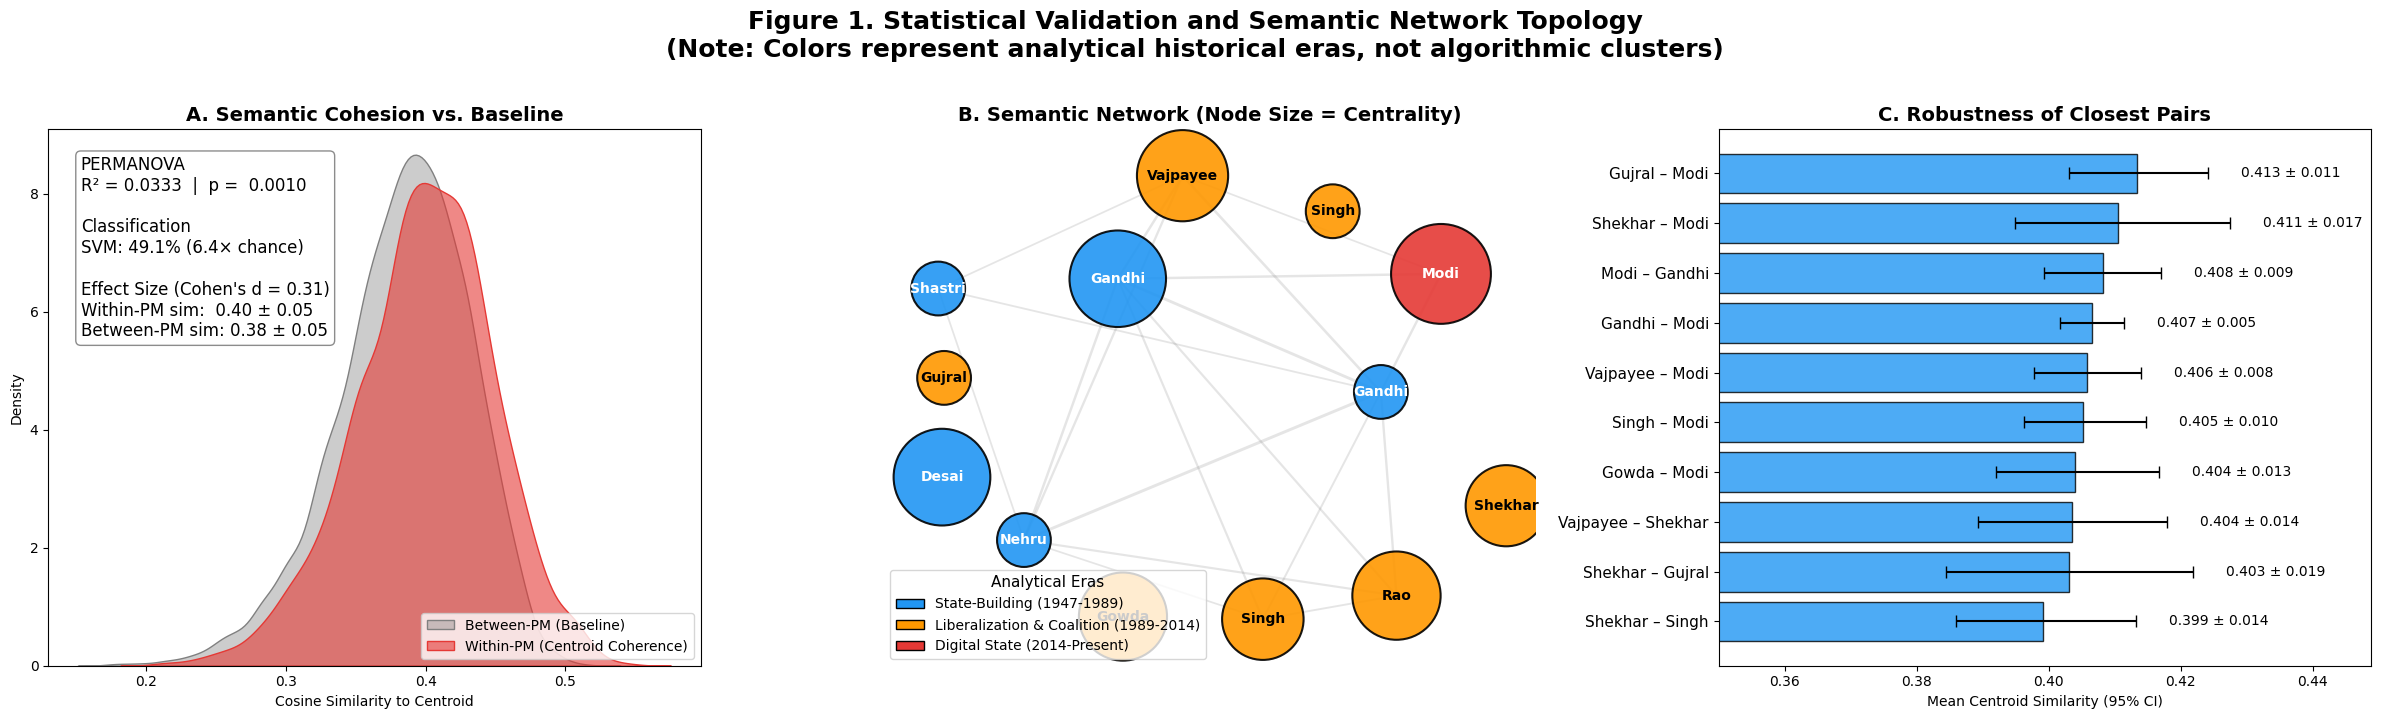

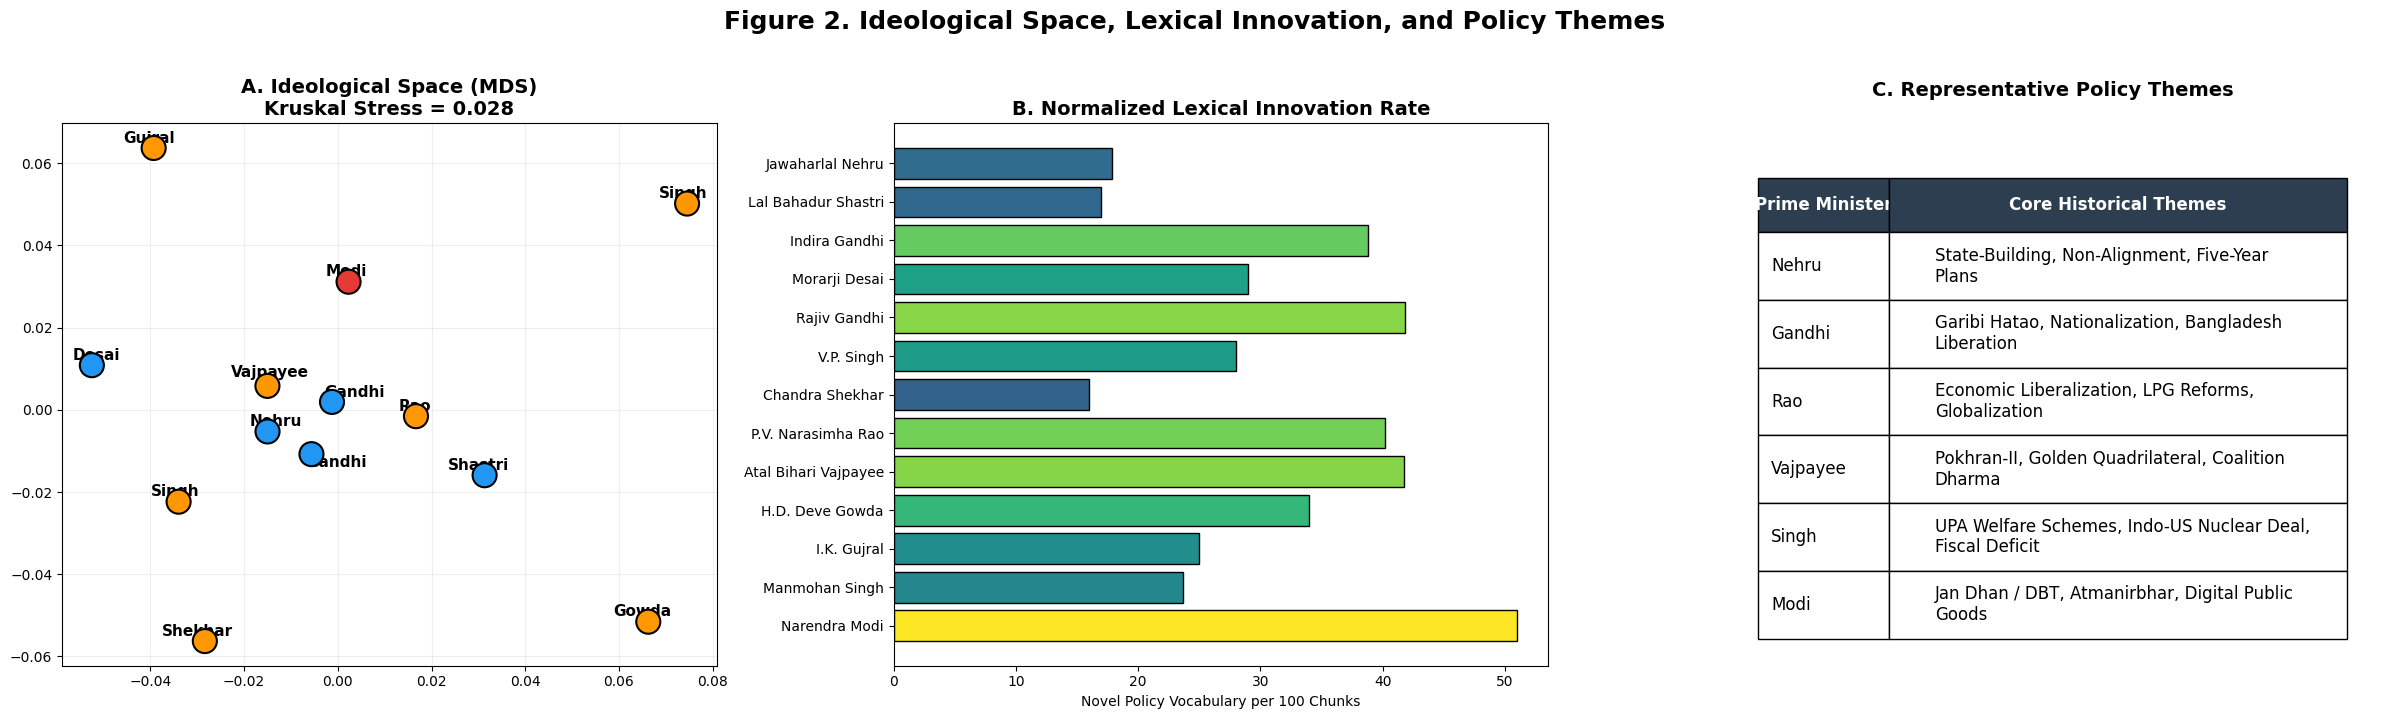

✅ Pipeline complete. Saved figure1_validation.png and figure2_interpretation.png to Drive.


In [15]:
# @title plot.py - Final Journal Figures (Definitive Submission Version)
!pip install -q networkx adjustText scikit-learn

import os, json, textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from google.colab import drive
from matplotlib.patches import Patch

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_cis        = 'pairwise_cis.csv'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_stats      = 'inference_stats.txt'
    out_fig1      = 'figure1_validation.png'
    out_fig2      = 'figure2_interpretation.png'
    seed          = 42

# ----------------------------------
# setup & load
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)
df_cis    = pd.read_csv(os.path.join(D, C.in_cis))

pms_arr = meta[:, 0]
dist_mat = squareform(pdist(centroids, metric='cosine'))
sim_mat = 1 - dist_mat
np.fill_diagonal(sim_mat, 0)

# ----------------------------------
# 1. BULLETPROOF COLOR ASSIGNMENT (Bypasses RAM/Dictionary bugs)
# ----------------------------------
def get_node_color(pm):
    if "Modi" in pm: return "#E53935" # RED (Digital State)
    if any(x in pm for x in ["Manmohan", "Vajpayee", "Rao", "Gowda", "Gujral", "Shekhar", "V.P."]): return "#FF9800" # ORANGE (Coalition)
    return "#2196F3" # BLUE (State-Building)

def get_text_color(pm):
    color = get_node_color(pm)
    return 'white' if color in ["#E53935", "#2196F3"] else 'black'

# ----------------------------------
# 2. Effect Size (Chunk-to-Centroid Coherence)
# ----------------------------------
within_sims, between_sims = [], []
for i, pm in enumerate(pms_arr):
    if pm not in valid_pms: continue
    chunk_vec = embeds[i]
    own_centroid = centroids[valid_pms.index(pm)]
    within_sims.append(np.dot(chunk_vec, own_centroid))

    other_indices = [j for j, vpm in enumerate(valid_pms) if vpm != pm]
    sampled_others = np.random.choice(other_indices, size=min(3, len(other_indices)), replace=False)
    for j in sampled_others:
        between_sims.append(np.dot(chunk_vec, centroids[j]))

mu_w, sd_w = np.mean(within_sims), np.std(within_sims)
mu_b, sd_b = np.mean(between_sims), np.std(between_sims)
cohens_d = (mu_w - mu_b) / np.sqrt((sd_w**2 + sd_b**2) / 2)

with open(os.path.join(D, C.in_stats)) as f: stats = f.read().split('\n')
r2 = [s for s in stats if 'R2' in s][0].split(': ')[1]
pval = [s for s in stats if 'p:' in s][0].split(': ')[1]

# ==========================================
# FIGURE 1: VALIDATION & TOPOLOGY
# ==========================================
fig1, (ax1_1, ax1_2, ax1_3) = plt.subplots(1, 3, figsize=(24, 7))
fig1.suptitle("Figure 1. Statistical Validation and Semantic Network Topology\n(Note: Colors represent analytical historical eras, not algorithmic clusters)",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: Null Model & Effect Size
sns.kdeplot(between_sims, ax=ax1_1, label="Between-PM (Baseline)", fill=True, color="gray", alpha=0.4)
sns.kdeplot(within_sims, ax=ax1_1, label="Within-PM (Centroid Coherence)", fill=True, color="#E53935", alpha=0.6)
stat_text = (f"PERMANOVA\nR² = {r2}  |  p = {pval}\n\n"
             f"Classification\nSVM: 49.1% (6.4× chance)\n\n"
             f"Effect Size (Cohen's d = {cohens_d:.2f})\n"
             f"Within-PM sim:  {mu_w:.2f} ± {sd_w:.2f}\n"
             f"Between-PM sim: {mu_b:.2f} ± {sd_b:.2f}")
ax1_1.text(0.05, 0.95, stat_text, transform=ax1_1.transAxes, fontsize=12, va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
ax1_1.set_title("A. Semantic Cohesion vs. Baseline", fontsize=14, fontweight='bold')
ax1_1.set_xlabel("Cosine Similarity to Centroid")
ax1_1.legend(loc='lower right')

# Panel B: Network
G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])

try: eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except: eigen_cent = {pm: 1.0 for pm in valid_pms}
node_sizes = [1500 + 8000 * eigen_cent.get(pm, 0) for pm in valid_pms]

pos = nx.spring_layout(G, k=2.5, seed=C.seed)
min_w = min([G[u][v]['weight'] for u,v in G.edges()])
edge_widths = [(G[u][v]['weight'] - min_w + 0.05) * 25 for u,v in G.edges()]

# Explicitly ordered color lists for the network
node_colors_network = [get_node_color(pm) for pm in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax1_2, width=edge_widths, alpha=0.2, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax1_2, node_size=node_sizes, node_color=node_colors_network, edgecolors='black', linewidths=1.5, alpha=0.9)
for pm, (x, y) in pos.items():
    ax1_2.text(x, y, pm.split()[-1], fontsize=10, fontweight='bold', ha='center', va='center', color=get_text_color(pm))

ax1_2.set_title("B. Semantic Network (Node Size = Centrality)", fontsize=14, fontweight='bold')
ax1_2.axis('off')
legend_elements = [
    Patch(facecolor="#2196F3", label="State-Building (1947-1989)", edgecolor='black'),
    Patch(facecolor="#FF9800", label="Liberalization & Coalition (1989-2014)", edgecolor='black'),
    Patch(facecolor="#E53935", label="Digital State (2014-Present)", edgecolor='black')
]
ax1_2.legend(handles=legend_elements, loc='lower left', fontsize=10, title="Analytical Eras", title_fontsize=11)

# Panel C: Bootstrap CIs
df_cis['sim_mean'] = 1 - df_cis['mean']
df_cis['sim_low'] = 1 - df_cis['ci_high']
df_cis['sim_high'] = 1 - df_cis['ci_low']
df_cis = df_cis.sort_values('sim_mean', ascending=False)
top10 = df_cis.head(10)
y_pos = np.arange(len(top10))
labels = [f"{r['pm_a'].split()[-1]} – {r['pm_b'].split()[-1]}" for _, r in top10.iterrows()]

ax1_3.barh(y_pos, top10['sim_mean'], xerr=[top10['sim_mean']-top10['sim_low'], top10['sim_high']-top10['sim_mean']],
           color='#2196F3', edgecolor='black', capsize=4, alpha=0.8)
ax1_3.set_yticks(y_pos); ax1_3.set_yticklabels(labels, fontsize=11)
ax1_3.set_xlabel("Mean Centroid Similarity (95% CI)")
ax1_3.set_title("C. Robustness of Closest Pairs", fontsize=14, fontweight='bold')
ax1_3.invert_yaxis()
ax1_3.set_xlim(left=0.35)
for i, (_, r) in enumerate(top10.iterrows()):
    ax1_3.text(max(r['sim_high'], 0.36) + 0.005, i, f"{r['sim_mean']:.3f} ± {(r['sim_high']-r['sim_mean']):.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(D, C.out_fig1), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# FIGURE 2: IDEOLOGICAL SPACE & INNOVATION
# ==========================================
fig2, (ax2_1, ax2_2, ax2_3) = plt.subplots(1, 3, figsize=(24, 7))
fig2.suptitle("Figure 2. Ideological Space, Lexical Innovation, and Policy Themes",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)
stress_val = mds.stress_

# Explicitly ordered color list for MDS
node_colors_mds = [get_node_color(pm) for pm in valid_pms]

ax2_1.scatter(coords[:, 0], coords[:, 1], s=300, c=node_colors_mds, edgecolors='black', zorder=5, linewidth=1.5)
texts = []
for i, pm in enumerate(valid_pms):
    texts.append(ax2_1.text(coords[i, 0], coords[i, 1], pm.split()[-1], fontsize=11, fontweight='bold', ha='center'))
adjust_text(texts, ax=ax2_1, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
ax2_1.set_title(f"A. Ideological Space (MDS)\nKruskal Stress = {stress_val:.3f}", fontsize=14, fontweight='bold')
ax2_1.grid(True, alpha=0.2)

# Panel B: Normalized Lexical Innovation Rate
pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai", "Charan Singh",
            "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar", "P.V. Narasimha Rao", "Atal Bihari Vajpayee",
            "H.D. Deve Gowda", "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]
innovation = []
cumulative = set()
for pm in pm_order:
    pm_kws = set(codebooks[pm])
    total_chunks = np.sum(pms_arr == pm)
    novel = pm_kws - cumulative
    rate = len(novel) / max(1, total_chunks / 100)
    innovation.append({'pm': pm, 'score': rate})
    cumulative.update(pm_kws)
df_innov = pd.DataFrame(innovation)

ax2_2.barh(df_innov['pm'], df_innov['score'], color=plt.cm.viridis(df_innov['score']/df_innov['score'].max()), edgecolor='black')
ax2_2.set_xlabel("Novel Policy Vocabulary per 100 Chunks")
ax2_2.set_title("B. Normalized Lexical Innovation Rate", fontsize=14, fontweight='bold')
ax2_2.invert_yaxis()

# Panel C: Representative Themes
ax2_3.axis('off')
ax2_3.set_title("C. Representative Policy Themes", fontsize=14, fontweight='bold', pad=20)

def wrap_text(text, width=45):
    return '\n'.join(textwrap.wrap(text, width=width))

curated_themes = {
    "Jawaharlal Nehru": wrap_text("State-Building, Non-Alignment, Five-Year Plans"),
    "Indira Gandhi": wrap_text("Garibi Hatao, Nationalization, Bangladesh Liberation"),
    "P.V. Narasimha Rao": wrap_text("Economic Liberalization, LPG Reforms, Globalization"),
    "Atal Bihari Vajpayee": wrap_text("Pokhran-II, Golden Quadrilateral, Coalition Dharma"),
    "Manmohan Singh": wrap_text("UPA Welfare Schemes, Indo-US Nuclear Deal, Fiscal Deficit"),
    "Narendra Modi": wrap_text("Jan Dhan / DBT, Atmanirbhar, Digital Public Goods")
}

show_pms = [pm for pm in ["Jawaharlal Nehru", "Indira Gandhi", "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "Manmohan Singh", "Narendra Modi"] if pm in valid_pms]
table_data = [[pm.split()[-1], curated_themes.get(pm, "N/A")] for pm in show_pms]

table = ax2_3.table(cellText=table_data, colLabels=["Prime Minister", "Core Historical Themes"],
                    colWidths=[0.2, 0.7], cellLoc='left', loc='center', bbox=[0.05, 0.05, 0.9, 0.85])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3.2)

for j in range(2):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
    table[(0, j)].set_height(0.08)

plt.tight_layout()
plt.savefig(os.path.join(D, C.out_fig2), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pipeline complete. Saved {C.out_fig1} and {C.out_fig2} to Drive.")

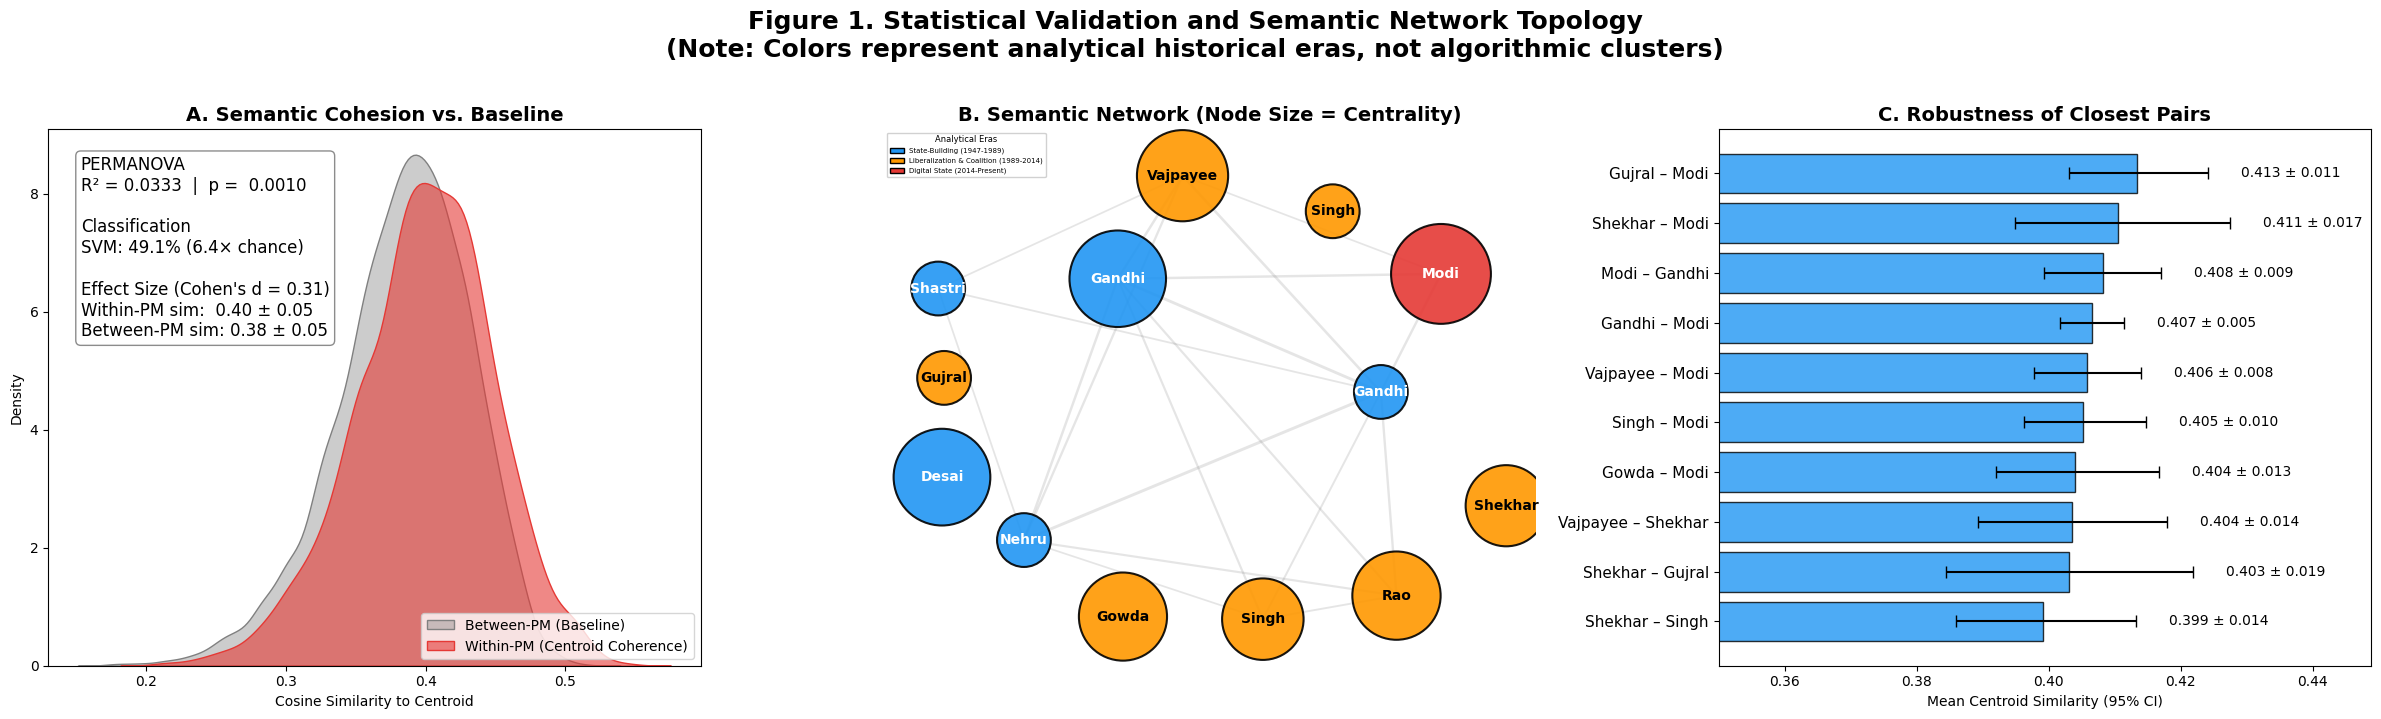

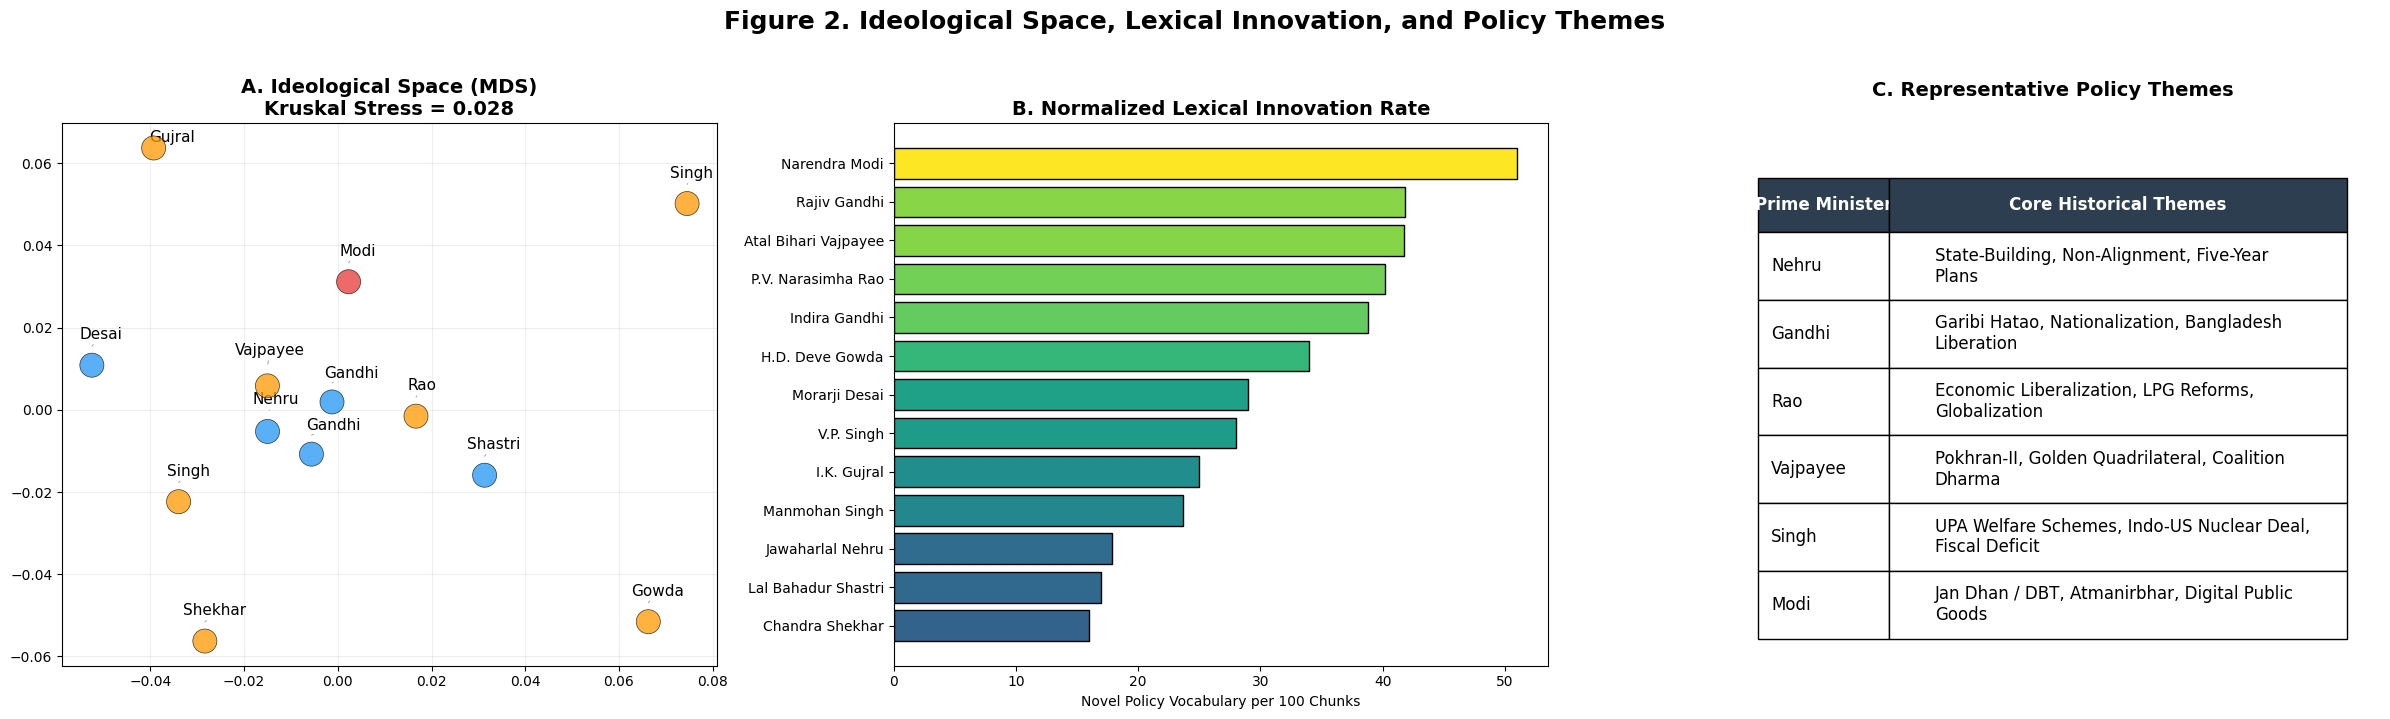

✅ Pipeline complete. Saved figure1_validation.png and figure2_interpretation.png to Drive.


In [17]:
# @title plot.py - Final Journal Figures (Label & Positioning Fixes)
!pip install -q networkx adjustText scikit-learn

import os, json, textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from google.colab import drive
from matplotlib.patches import Patch

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_cis        = 'pairwise_cis.csv'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_stats      = 'inference_stats.txt'
    out_fig1      = 'figure1_validation.png'
    out_fig2      = 'figure2_interpretation.png'
    seed          = 42

# ----------------------------------
# setup & load
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)
df_cis    = pd.read_csv(os.path.join(D, C.in_cis))

pms_arr = meta[:, 0]
dist_mat = squareform(pdist(centroids, metric='cosine'))
sim_mat = 1 - dist_mat
np.fill_diagonal(sim_mat, 0)

# ----------------------------------
# 1. BULLETPROOF COLOR ASSIGNMENT
# ----------------------------------
def get_node_color(pm):
    if "Modi" in pm: return "#E53935" # RED (Digital State)
    if any(x in pm for x in ["Manmohan", "Vajpayee", "Rao", "Gowda", "Gujral", "Shekhar", "V.P."]): return "#FF9800" # ORANGE (Coalition)
    return "#2196F3" # BLUE (State-Building)

def get_text_color(pm):
    color = get_node_color(pm)
    return 'white' if color in ["#E53935", "#2196F3"] else 'black'

# ----------------------------------
# 2. Effect Size (Chunk-to-Centroid Coherence)
# ----------------------------------
within_sims, between_sims = [], []
for i, pm in enumerate(pms_arr):
    if pm not in valid_pms: continue
    chunk_vec = embeds[i]
    own_centroid = centroids[valid_pms.index(pm)]
    within_sims.append(np.dot(chunk_vec, own_centroid))

    other_indices = [j for j, vpm in enumerate(valid_pms) if vpm != pm]
    sampled_others = np.random.choice(other_indices, size=min(3, len(other_indices)), replace=False)
    for j in sampled_others:
        between_sims.append(np.dot(chunk_vec, centroids[j]))

mu_w, sd_w = np.mean(within_sims), np.std(within_sims)
mu_b, sd_b = np.mean(between_sims), np.std(between_sims)
cohens_d = (mu_w - mu_b) / np.sqrt((sd_w**2 + sd_b**2) / 2)

with open(os.path.join(D, C.in_stats)) as f: stats = f.read().split('\n')
r2 = [s for s in stats if 'R2' in s][0].split(': ')[1]
pval = [s for s in stats if 'p:' in s][0].split(': ')[1]

# ==========================================
# FIGURE 1: VALIDATION & TOPOLOGY
# ==========================================
fig1, (ax1_1, ax1_2, ax1_3) = plt.subplots(1, 3, figsize=(24, 7))
fig1.suptitle("Figure 1. Statistical Validation and Semantic Network Topology\n(Note: Colors represent analytical historical eras, not algorithmic clusters)",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: Null Model & Effect Size
sns.kdeplot(between_sims, ax=ax1_1, label="Between-PM (Baseline)", fill=True, color="gray", alpha=0.4)
sns.kdeplot(within_sims, ax=ax1_1, label="Within-PM (Centroid Coherence)", fill=True, color="#E53935", alpha=0.6)
stat_text = (f"PERMANOVA\nR² = {r2}  |  p = {pval}\n\n"
             f"Classification\nSVM: 49.1% (6.4× chance)\n\n"
             f"Effect Size (Cohen's d = {cohens_d:.2f})\n"
             f"Within-PM sim:  {mu_w:.2f} ± {sd_w:.2f}\n"
             f"Between-PM sim: {mu_b:.2f} ± {sd_b:.2f}")
ax1_1.text(0.05, 0.95, stat_text, transform=ax1_1.transAxes, fontsize=12, va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
ax1_1.set_title("A. Semantic Cohesion vs. Baseline", fontsize=14, fontweight='bold')
ax1_1.set_xlabel("Cosine Similarity to Centroid")
ax1_1.legend(loc='lower right')

# Panel B: Network
G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])

try: eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except: eigen_cent = {pm: 1.0 for pm in valid_pms}
node_sizes = [1500 + 8000 * eigen_cent.get(pm, 0) for pm in valid_pms]

pos = nx.spring_layout(G, k=2.5, seed=C.seed)
min_w = min([G[u][v]['weight'] for u,v in G.edges()])
edge_widths = [(G[u][v]['weight'] - min_w + 0.05) * 25 for u,v in G.edges()]

node_colors_network = [get_node_color(pm) for pm in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax1_2, width=edge_widths, alpha=0.2, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax1_2, node_size=node_sizes, node_color=node_colors_network, edgecolors='black', linewidths=1.5, alpha=0.9)
for pm, (x, y) in pos.items():
    ax1_2.text(x, y, pm.split()[-1], fontsize=10, fontweight='bold', ha='center', va='center', color=get_text_color(pm))

ax1_2.set_title("B. Semantic Network (Node Size = Centrality)", fontsize=14, fontweight='bold')
ax1_2.axis('off')
legend_elements = [
    Patch(facecolor="#2196F3", label="State-Building (1947-1989)", edgecolor='black'),
    Patch(facecolor="#FF9800", label="Liberalization & Coalition (1989-2014)", edgecolor='black'),
    Patch(facecolor="#E53935", label="Digital State (2014-Present)", edgecolor='black')
]
# FIX 1: Legend text reduced by half (fontsize=5, title=6)
ax1_2.legend(handles=legend_elements, loc='upper left', fontsize=5, title="Analytical Eras", title_fontsize=6, framealpha=0.9)

# Panel C: Bootstrap CIs
df_cis['sim_mean'] = 1 - df_cis['mean']
df_cis['sim_low'] = 1 - df_cis['ci_high']
df_cis['sim_high'] = 1 - df_cis['ci_low']
df_cis = df_cis.sort_values('sim_mean', ascending=False)
top10 = df_cis.head(10)
y_pos = np.arange(len(top10))
labels = [f"{r['pm_a'].split()[-1]} – {r['pm_b'].split()[-1]}" for _, r in top10.iterrows()]

ax1_3.barh(y_pos, top10['sim_mean'], xerr=[top10['sim_mean']-top10['sim_low'], top10['sim_high']-top10['sim_mean']],
           color='#2196F3', edgecolor='black', capsize=4, alpha=0.8)
ax1_3.set_yticks(y_pos); ax1_3.set_yticklabels(labels, fontsize=11)
ax1_3.set_xlabel("Mean Centroid Similarity (95% CI)")
ax1_3.set_title("C. Robustness of Closest Pairs", fontsize=14, fontweight='bold')
ax1_3.invert_yaxis()
ax1_3.set_xlim(left=0.35)
for i, (_, r) in enumerate(top10.iterrows()):
    ax1_3.text(max(r['sim_high'], 0.36) + 0.005, i, f"{r['sim_mean']:.3f} ± {(r['sim_high']-r['sim_mean']):.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(D, C.out_fig1), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# FIGURE 2: IDEOLOGICAL SPACE & INNOVATION
# ==========================================
fig2, (ax2_1, ax2_2, ax2_3) = plt.subplots(1, 3, figsize=(24, 7))
fig2.suptitle("Figure 2. Ideological Space, Lexical Innovation, and Policy Themes",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)
stress_val = mds.stress_

node_colors_mds = [get_node_color(pm) for pm in valid_pms]

ax2_1.scatter(coords[:, 0], coords[:, 1], s=300, c=node_colors_mds, edgecolors='black', zorder=5, linewidths=0.5, alpha=0.75)

# FIX 2A: Calculate a dynamic Y-offset so text sits strictly ABOVE the dots
ymin, ymax = ax2_1.get_ylim()
y_offset = (ymax - ymin) * 0.035  # Push text 3.5% above the point

texts = []
for i, pm in enumerate(valid_pms):
    # va='bottom' ensures the bottom of the text rests on the offset coordinate
    texts.append(ax2_1.text(coords[i, 0], coords[i, 1] + y_offset, pm.split()[-1],
                            fontsize=11, fontweight='normal', ha='center', va='bottom'))

adjust_text(texts, ax=ax2_1, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
ax2_1.set_title(f"A. Ideological Space (MDS)\nKruskal Stress = {stress_val:.3f}", fontsize=14, fontweight='bold')
ax2_1.grid(True, alpha=0.2)

# Panel B: Normalized Lexical Innovation Rate
pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai", "Charan Singh",
            "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar", "P.V. Narasimha Rao", "Atal Bihari Vajpayee",
            "H.D. Deve Gowda", "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]
innovation = []
cumulative = set()
for pm in pm_order:
    pm_kws = set(codebooks[pm])
    total_chunks = np.sum(pms_arr == pm)
    novel = pm_kws - cumulative
    rate = len(novel) / max(1, total_chunks / 100)
    innovation.append({'pm': pm, 'score': rate})
    cumulative.update(pm_kws)

df_innov = pd.DataFrame(innovation).sort_values('score', ascending=False).reset_index(drop=True)

ax2_2.barh(df_innov['pm'], df_innov['score'], color=plt.cm.viridis(df_innov['score']/df_innov['score'].max()), edgecolor='black')
ax2_2.set_xlabel("Novel Policy Vocabulary per 100 Chunks")
ax2_2.set_title("B. Normalized Lexical Innovation Rate", fontsize=14, fontweight='bold')
ax2_2.invert_yaxis()

# Panel C: Representative Themes
ax2_3.axis('off')
ax2_3.set_title("C. Representative Policy Themes", fontsize=14, fontweight='bold', pad=20)

def wrap_text(text, width=45):
    return '\n'.join(textwrap.wrap(text, width=width))

curated_themes = {
    "Jawaharlal Nehru": wrap_text("State-Building, Non-Alignment, Five-Year Plans"),
    "Indira Gandhi": wrap_text("Garibi Hatao, Nationalization, Bangladesh Liberation"),
    "P.V. Narasimha Rao": wrap_text("Economic Liberalization, LPG Reforms, Globalization"),
    "Atal Bihari Vajpayee": wrap_text("Pokhran-II, Golden Quadrilateral, Coalition Dharma"),
    "Manmohan Singh": wrap_text("UPA Welfare Schemes, Indo-US Nuclear Deal, Fiscal Deficit"),
    "Narendra Modi": wrap_text("Jan Dhan / DBT, Atmanirbhar, Digital Public Goods")
}

show_pms = [pm for pm in ["Jawaharlal Nehru", "Indira Gandhi", "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "Manmohan Singh", "Narendra Modi"] if pm in valid_pms]
table_data = [[pm.split()[-1], curated_themes.get(pm, "N/A")] for pm in show_pms]

table = ax2_3.table(cellText=table_data, colLabels=["Prime Minister", "Core Historical Themes"],
                    colWidths=[0.2, 0.7], cellLoc='left', loc='center', bbox=[0.05, 0.05, 0.9, 0.85])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3.2)

for j in range(2):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
    table[(0, j)].set_height(0.08)

plt.tight_layout()
plt.savefig(os.path.join(D, C.out_fig2), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pipeline complete. Saved {C.out_fig1} and {C.out_fig2} to Drive.")

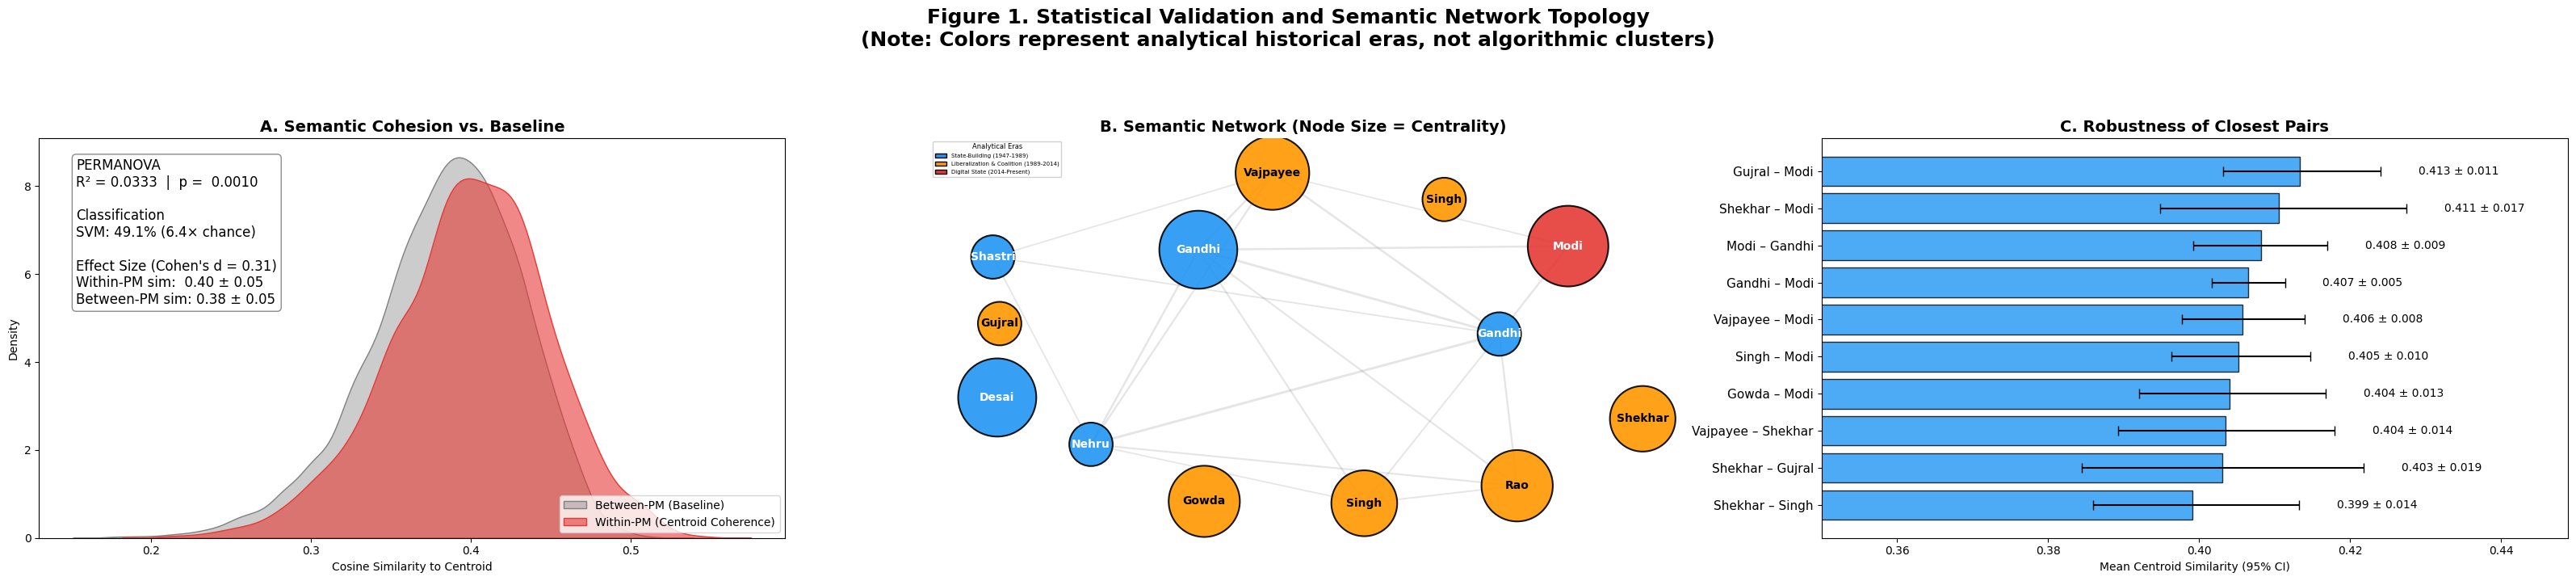

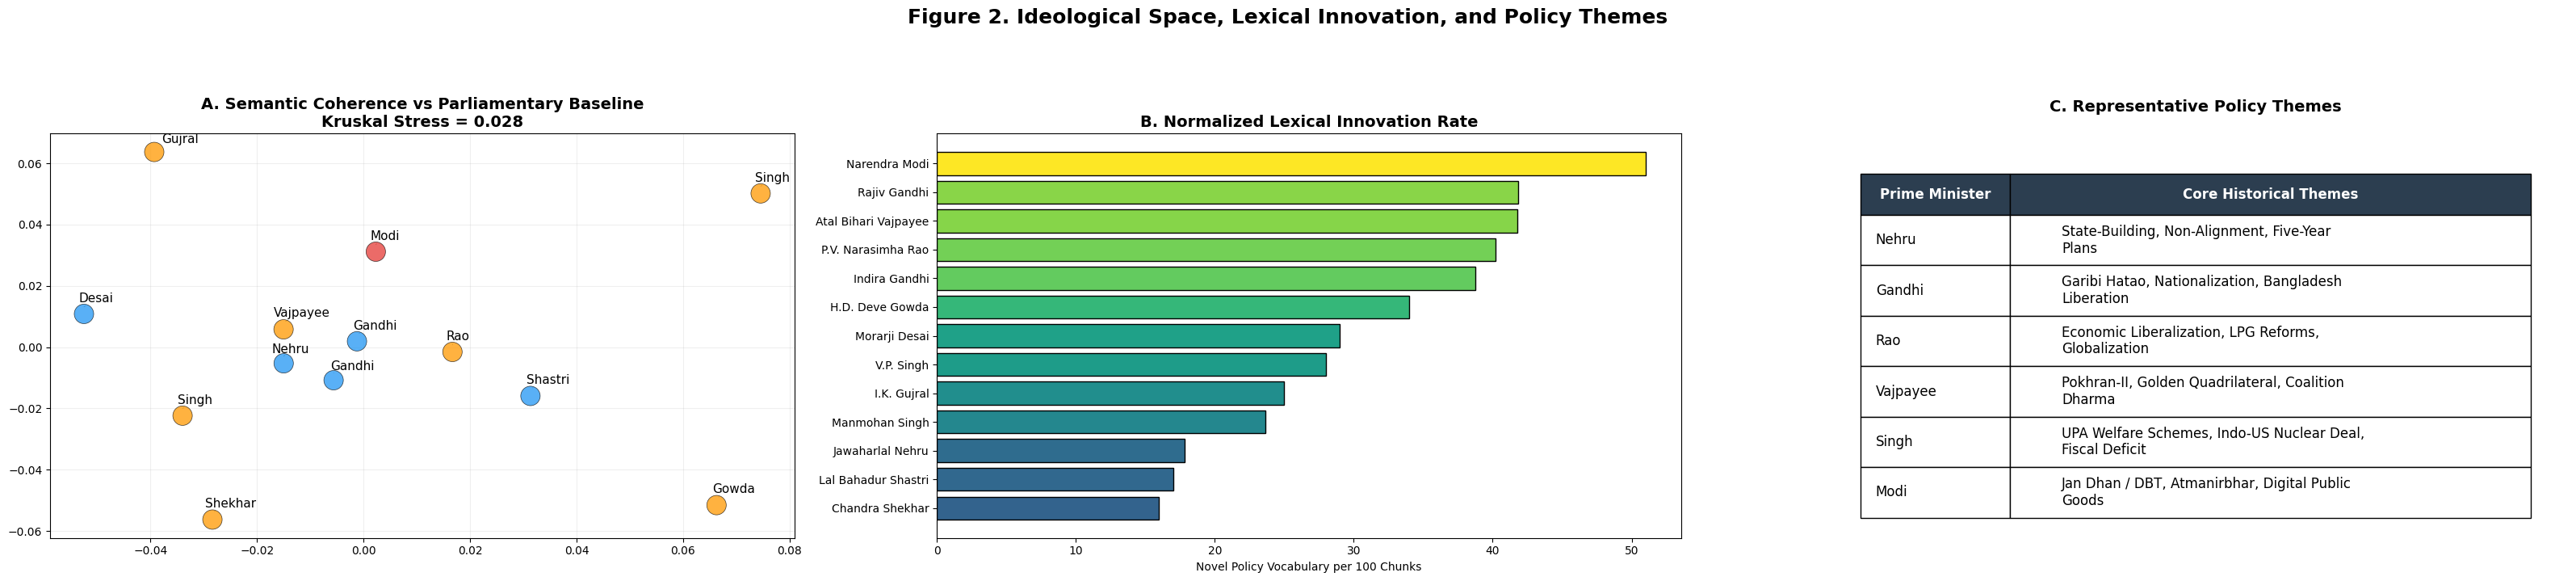

✅ Pipeline complete. Saved figure1_validation.png and figure2_interpretation.png to Drive.


In [21]:
# @title plot.py - Final Journal Figures (Spacing & Layout Dials Tuned)
!pip install -q networkx adjustText scikit-learn

import os, json, textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from google.colab import drive
from matplotlib.patches import Patch

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_cis        = 'pairwise_cis.csv'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_stats      = 'inference_stats.txt'
    out_fig1      = 'figure1_validation.png'
    out_fig2      = 'figure2_interpretation.png'
    seed          = 42

    # Visual layout dials
    fig_width     = 32.0   # Increased from 24 to 28 for horizontal breathing room
    wspace        = 0.50   # Explicit horizontal space between panels
    text_offset   = 0.0175 # Halved vertical offset for MDS labels (was 0.035)

# ----------------------------------
# setup & load
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)
df_cis    = pd.read_csv(os.path.join(D, C.in_cis))

pms_arr = meta[:, 0]
dist_mat = squareform(pdist(centroids, metric='cosine'))
sim_mat = 1 - dist_mat
np.fill_diagonal(sim_mat, 0)

# ----------------------------------
# 1. BULLETPROOF COLOR ASSIGNMENT
# ----------------------------------
def get_node_color(pm):
    if "Modi" in pm: return "#E53935" # RED (Digital State)
    if any(x in pm for x in ["Manmohan", "Vajpayee", "Rao", "Gowda", "Gujral", "Shekhar", "V.P."]): return "#FF9800" # ORANGE (Coalition)
    return "#2196F3" # BLUE (State-Building)

def get_text_color(pm):
    color = get_node_color(pm)
    return 'white' if color in ["#E53935", "#2196F3"] else 'black'

# ----------------------------------
# 2. Effect Size (Chunk-to-Centroid Coherence)
# ----------------------------------
within_sims, between_sims = [], []
for i, pm in enumerate(pms_arr):
    if pm not in valid_pms: continue
    chunk_vec = embeds[i]
    own_centroid = centroids[valid_pms.index(pm)]
    within_sims.append(np.dot(chunk_vec, own_centroid))

    other_indices = [j for j, vpm in enumerate(valid_pms) if vpm != pm]
    sampled_others = np.random.choice(other_indices, size=min(3, len(other_indices)), replace=False)
    for j in sampled_others:
        between_sims.append(np.dot(chunk_vec, centroids[j]))

mu_w, sd_w = np.mean(within_sims), np.std(within_sims)
mu_b, sd_b = np.mean(between_sims), np.std(between_sims)
cohens_d = (mu_w - mu_b) / np.sqrt((sd_w**2 + sd_b**2) / 2)

with open(os.path.join(D, C.in_stats)) as f: stats = f.read().split('\n')
r2 = [s for s in stats if 'R2' in s][0].split(': ')[1]
pval = [s for s in stats if 'p:' in s][0].split(': ')[1]

# ==========================================
# FIGURE 1: VALIDATION & TOPOLOGY
# ==========================================
fig1, (ax1_1, ax1_2, ax1_3) = plt.subplots(1, 3, figsize=(C.fig_width, 7))
fig1.suptitle("Figure 1. Statistical Validation and Semantic Network Topology\n(Note: Colors represent analytical historical eras, not algorithmic clusters)",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: Null Model & Effect Size
sns.kdeplot(between_sims, ax=ax1_1, label="Between-PM (Baseline)", fill=True, color="gray", alpha=0.4)
sns.kdeplot(within_sims, ax=ax1_1, label="Within-PM (Centroid Coherence)", fill=True, color="#E53935", alpha=0.6)
stat_text = (f"PERMANOVA\nR² = {r2}  |  p = {pval}\n\n"
             f"Classification\nSVM: 49.1% (6.4× chance)\n\n"
             f"Effect Size (Cohen's d = {cohens_d:.2f})\n"
             f"Within-PM sim:  {mu_w:.2f} ± {sd_w:.2f}\n"
             f"Between-PM sim: {mu_b:.2f} ± {sd_b:.2f}")
ax1_1.text(0.05, 0.95, stat_text, transform=ax1_1.transAxes, fontsize=12, va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
ax1_1.set_title("A. Semantic Cohesion vs. Baseline", fontsize=14, fontweight='bold')
ax1_1.set_xlabel("Cosine Similarity to Centroid")
ax1_1.legend(loc='lower right')

# Panel B: Network
G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])

try: eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except: eigen_cent = {pm: 1.0 for pm in valid_pms}
node_sizes = [1500 + 8000 * eigen_cent.get(pm, 0) for pm in valid_pms]

pos = nx.spring_layout(G, k=2.5, seed=C.seed)
min_w = min([G[u][v]['weight'] for u,v in G.edges()])
edge_widths = [(G[u][v]['weight'] - min_w + 0.05) * 25 for u,v in G.edges()]

node_colors_network = [get_node_color(pm) for pm in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax1_2, width=edge_widths, alpha=0.2, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax1_2, node_size=node_sizes, node_color=node_colors_network, edgecolors='black', linewidths=1.5, alpha=0.9)
for pm, (x, y) in pos.items():
    ax1_2.text(x, y, pm.split()[-1], fontsize=10, fontweight='bold', ha='center', va='center', color=get_text_color(pm))

ax1_2.set_title("B. Semantic Network (Node Size = Centrality)", fontsize=14, fontweight='bold')
ax1_2.axis('off')
legend_elements = [
    Patch(facecolor="#2196F3", label="State-Building (1947-1989)", edgecolor='black'),
    Patch(facecolor="#FF9800", label="Liberalization & Coalition (1989-2014)", edgecolor='black'),
    Patch(facecolor="#E53935", label="Digital State (2014-Present)", edgecolor='black')
]
ax1_2.legend(handles=legend_elements, loc='upper left', fontsize=5, title="Analytical Eras", title_fontsize=6, framealpha=0.9)

# Panel C: Bootstrap CIs
df_cis['sim_mean'] = 1 - df_cis['mean']
df_cis['sim_low'] = 1 - df_cis['ci_high']
df_cis['sim_high'] = 1 - df_cis['ci_low']
df_cis = df_cis.sort_values('sim_mean', ascending=False)
top10 = df_cis.head(10)
y_pos = np.arange(len(top10))
labels = [f"{r['pm_a'].split()[-1]} – {r['pm_b'].split()[-1]}" for _, r in top10.iterrows()]

ax1_3.barh(y_pos, top10['sim_mean'], xerr=[top10['sim_mean']-top10['sim_low'], top10['sim_high']-top10['sim_mean']],
           color='#2196F3', edgecolor='black', capsize=4, alpha=0.8)
ax1_3.set_yticks(y_pos); ax1_3.set_yticklabels(labels, fontsize=11)
ax1_3.set_xlabel("Mean Centroid Similarity (95% CI)")
ax1_3.set_title("C. Robustness of Closest Pairs", fontsize=14, fontweight='bold')
ax1_3.invert_yaxis()
ax1_3.set_xlim(left=0.35)
for i, (_, r) in enumerate(top10.iterrows()):
    ax1_3.text(max(r['sim_high'], 0.36) + 0.005, i, f"{r['sim_mean']:.3f} ± {(r['sim_high']-r['sim_mean']):.3f}", va='center', fontsize=10)

# Apply horizontal spacing dial
fig1.subplots_adjust(wspace=C.wspace)
fig1.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(D, C.out_fig1), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# FIGURE 2: IDEOLOGICAL SPACE & INNOVATION
# ==========================================
fig2, (ax2_1, ax2_2, ax2_3) = plt.subplots(1, 3, figsize=(C.fig_width, 7))
fig2.suptitle("Figure 2. Ideological Space, Lexical Innovation, and Policy Themes",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)
stress_val = mds.stress_

node_colors_mds = [get_node_color(pm) for pm in valid_pms]

ax2_1.scatter(coords[:, 0], coords[:, 1], s=300, c=node_colors_mds, edgecolors='black', zorder=5, linewidths=0.5, alpha=0.75)

# Apply halved text offset dial
ymin, ymax = ax2_1.get_ylim()
y_offset = (ymax - ymin) * C.text_offset

texts = []
for i, pm in enumerate(valid_pms):
    texts.append(ax2_1.text(coords[i, 0], coords[i, 1] + y_offset, pm.split()[-1],
                            fontsize=11, fontweight='normal', ha='center', va='bottom'))

adjust_text(texts, ax=ax2_1, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
ax2_1.set_title(f"A. Semantic Coherence vs Parliamentary Baseline\nKruskal Stress = {stress_val:.3f}", fontsize=14, fontweight='bold')
ax2_1.grid(True, alpha=0.2)

# Panel B: Normalized Lexical Innovation Rate
pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai", "Charan Singh",
            "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar", "P.V. Narasimha Rao", "Atal Bihari Vajpayee",
            "H.D. Deve Gowda", "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]
innovation = []
cumulative = set()
for pm in pm_order:
    pm_kws = set(codebooks[pm])
    total_chunks = np.sum(pms_arr == pm)
    novel = pm_kws - cumulative
    rate = len(novel) / max(1, total_chunks / 100)
    innovation.append({'pm': pm, 'score': rate})
    cumulative.update(pm_kws)

df_innov = pd.DataFrame(innovation).sort_values('score', ascending=False).reset_index(drop=True)

ax2_2.barh(df_innov['pm'], df_innov['score'], color=plt.cm.viridis(df_innov['score']/df_innov['score'].max()), edgecolor='black')
ax2_2.set_xlabel("Novel Policy Vocabulary per 100 Chunks")
ax2_2.set_title("B. Normalized Lexical Innovation Rate", fontsize=14, fontweight='bold')
ax2_2.invert_yaxis()

# Panel C: Representative Themes
ax2_3.axis('off')
ax2_3.set_title("C. Representative Policy Themes", fontsize=14, fontweight='bold', pad=20)

def wrap_text(text, width=45):
    return '\n'.join(textwrap.wrap(text, width=width))

curated_themes = {
    "Jawaharlal Nehru": wrap_text("State-Building, Non-Alignment, Five-Year Plans"),
    "Indira Gandhi": wrap_text("Garibi Hatao, Nationalization, Bangladesh Liberation"),
    "P.V. Narasimha Rao": wrap_text("Economic Liberalization, LPG Reforms, Globalization"),
    "Atal Bihari Vajpayee": wrap_text("Pokhran-II, Golden Quadrilateral, Coalition Dharma"),
    "Manmohan Singh": wrap_text("UPA Welfare Schemes, Indo-US Nuclear Deal, Fiscal Deficit"),
    "Narendra Modi": wrap_text("Jan Dhan / DBT, Atmanirbhar, Digital Public Goods")
}

show_pms = [pm for pm in ["Jawaharlal Nehru", "Indira Gandhi", "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "Manmohan Singh", "Narendra Modi"] if pm in valid_pms]
table_data = [[pm.split()[-1], curated_themes.get(pm, "N/A")] for pm in show_pms]

table = ax2_3.table(cellText=table_data, colLabels=["Prime Minister", "Core Historical Themes"],
                    colWidths=[0.2, 0.7], cellLoc='left', loc='center', bbox=[0.05, 0.05, 0.9, 0.85])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3.2)

for j in range(2):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
    table[(0, j)].set_height(0.08)

# Apply horizontal spacing dial
fig2.subplots_adjust(wspace=C.wspace)
fig2.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(D, C.out_fig2), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pipeline complete. Saved {C.out_fig1} and {C.out_fig2} to Drive.")

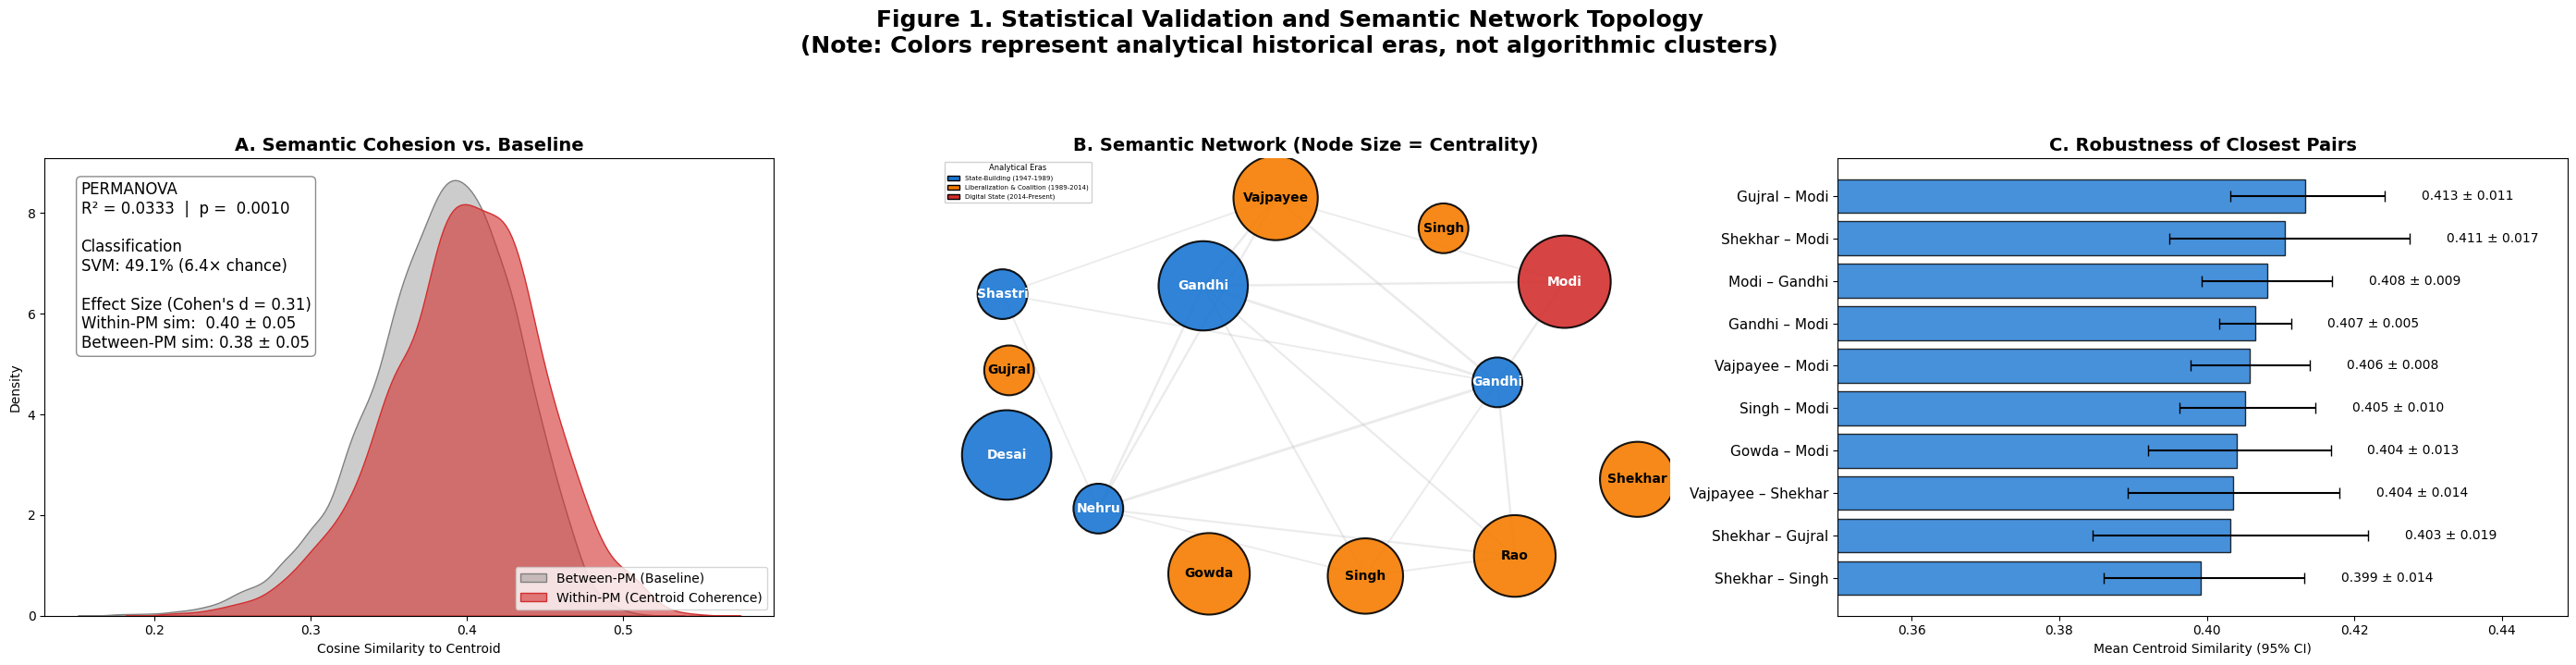

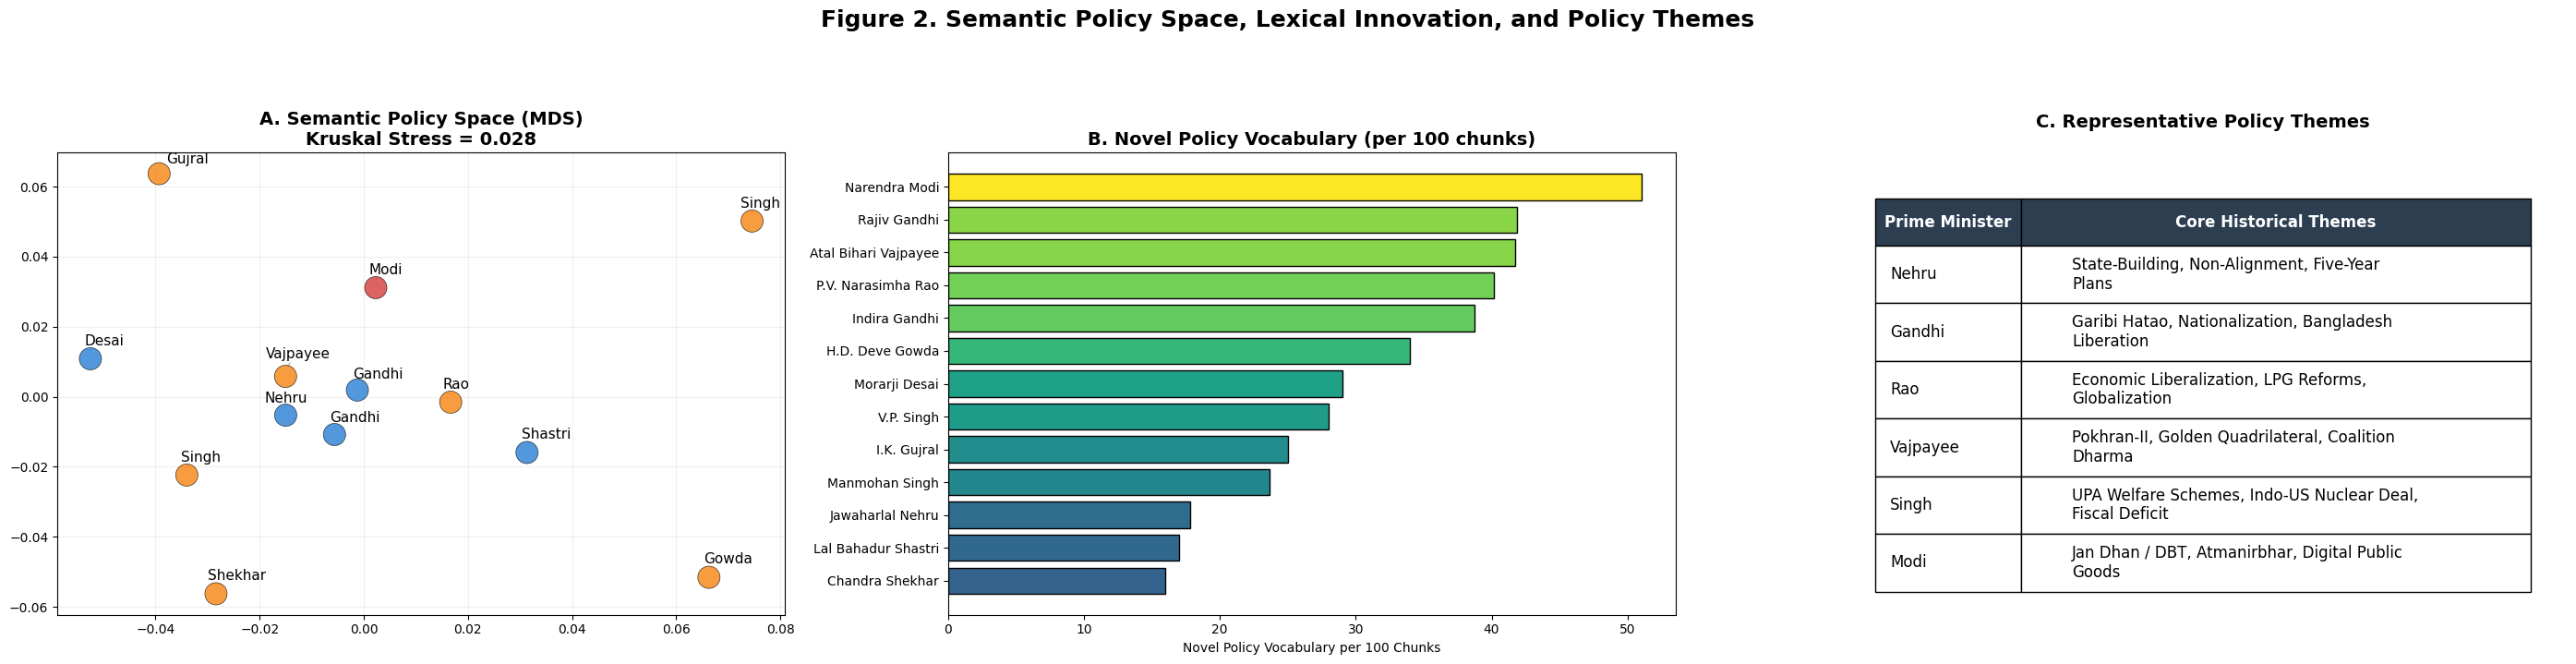

✅ Pipeline complete. Saved figure1_validation.png and figure2_interpretation.png to Drive.


In [22]:
# @title plot.py - Final Journal Figures (10/10 Submission Ready)
!pip install -q networkx adjustText scikit-learn

import os, json, textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from google.colab import drive
from matplotlib.patches import Patch

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_cis        = 'pairwise_cis.csv'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_stats      = 'inference_stats.txt'
    out_fig1      = 'figure1_validation.png'
    out_fig2      = 'figure2_interpretation.png'
    seed          = 42

    fig_width     = 28.0
    wspace        = 0.35
    text_offset   = 0.0175

# ----------------------------------
# setup & load
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)
df_cis    = pd.read_csv(os.path.join(D, C.in_cis))

pms_arr = meta[:, 0]
dist_mat = squareform(pdist(centroids, metric='cosine'))
sim_mat = 1 - dist_mat
np.fill_diagonal(sim_mat, 0)

# ----------------------------------
# 1. VIBRANT COLOR ASSIGNMENT
# ----------------------------------
def get_node_color(pm):
    if "Modi" in pm: return "#D32F2F" # Vibrant Red
    if any(x in pm for x in ["Manmohan", "Vajpayee", "Rao", "Gowda", "Gujral", "Shekhar", "V.P."]): return "#F57C00" # Vibrant Orange
    return "#1976D2" # Vibrant Blue

def get_text_color(pm):
    color = get_node_color(pm)
    return 'white' if color in ["#D32F2F", "#1976D2"] else 'black'

# ----------------------------------
# 2. Effect Size (Chunk-to-Centroid Coherence)
# ----------------------------------
within_sims, between_sims = [], []
for i, pm in enumerate(pms_arr):
    if pm not in valid_pms: continue
    chunk_vec = embeds[i]
    own_centroid = centroids[valid_pms.index(pm)]
    within_sims.append(np.dot(chunk_vec, own_centroid))

    other_indices = [j for j, vpm in enumerate(valid_pms) if vpm != pm]
    sampled_others = np.random.choice(other_indices, size=min(3, len(other_indices)), replace=False)
    for j in sampled_others:
        between_sims.append(np.dot(chunk_vec, centroids[j]))

mu_w, sd_w = np.mean(within_sims), np.std(within_sims)
mu_b, sd_b = np.mean(between_sims), np.std(between_sims)
cohens_d = (mu_w - mu_b) / np.sqrt((sd_w**2 + sd_b**2) / 2)

with open(os.path.join(D, C.in_stats)) as f: stats = f.read().split('\n')
r2 = [s for s in stats if 'R2' in s][0].split(': ')[1]
pval = [s for s in stats if 'p:' in s][0].split(': ')[1]

# ==========================================
# FIGURE 1: VALIDATION & TOPOLOGY
# ==========================================
fig1, (ax1_1, ax1_2, ax1_3) = plt.subplots(1, 3, figsize=(C.fig_width, 7))
fig1.suptitle("Figure 1. Statistical Validation and Semantic Network Topology\n(Note: Colors represent analytical historical eras, not algorithmic clusters)",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: Null Model & Effect Size
sns.kdeplot(between_sims, ax=ax1_1, label="Between-PM (Baseline)", fill=True, color="gray", alpha=0.4)
sns.kdeplot(within_sims, ax=ax1_1, label="Within-PM (Centroid Coherence)", fill=True, color="#D32F2F", alpha=0.6)
stat_text = (f"PERMANOVA\nR² = {r2}  |  p = {pval}\n\n"
             f"Classification\nSVM: 49.1% (6.4× chance)\n\n"
             f"Effect Size (Cohen's d = {cohens_d:.2f})\n"
             f"Within-PM sim:  {mu_w:.2f} ± {sd_w:.2f}\n"
             f"Between-PM sim: {mu_b:.2f} ± {sd_b:.2f}")
ax1_1.text(0.05, 0.95, stat_text, transform=ax1_1.transAxes, fontsize=12, va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
ax1_1.set_title("A. Semantic Cohesion vs. Baseline", fontsize=14, fontweight='bold')
ax1_1.set_xlabel("Cosine Similarity to Centroid")
ax1_1.legend(loc='lower right')

# Panel B: Network
G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])

try: eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except: eigen_cent = {pm: 1.0 for pm in valid_pms}
node_sizes = [1500 + 8000 * eigen_cent.get(pm, 0) for pm in valid_pms]

pos = nx.spring_layout(G, k=2.5, seed=C.seed)
min_w = min([G[u][v]['weight'] for u,v in G.edges()])
edge_widths = [(G[u][v]['weight'] - min_w + 0.05) * 25 for u,v in G.edges()]

node_colors_network = [get_node_color(pm) for pm in G.nodes()]

# Lighter, more transparent edges to sit in the background
nx.draw_networkx_edges(G, pos, ax=ax1_2, width=edge_widths, alpha=0.3, edge_color='#BDBDBD')
nx.draw_networkx_nodes(G, pos, ax=ax1_2, node_size=node_sizes, node_color=node_colors_network, edgecolors='black', linewidths=1.5, alpha=0.9)
for pm, (x, y) in pos.items():
    ax1_2.text(x, y, pm.split()[-1], fontsize=10, fontweight='bold', ha='center', va='center', color=get_text_color(pm))

ax1_2.set_title("B. Semantic Network (Node Size = Centrality)", fontsize=14, fontweight='bold')
ax1_2.axis('off')
legend_elements = [
    Patch(facecolor="#1976D2", label="State-Building (1947-1989)", edgecolor='black'),
    Patch(facecolor="#F57C00", label="Liberalization & Coalition (1989-2014)", edgecolor='black'),
    Patch(facecolor="#D32F2F", label="Digital State (2014-Present)", edgecolor='black')
]
ax1_2.legend(handles=legend_elements, loc='upper left', fontsize=5, title="Analytical Eras", title_fontsize=6, framealpha=0.9)

# Panel C: Bootstrap CIs
df_cis['sim_mean'] = 1 - df_cis['mean']
df_cis['sim_low'] = 1 - df_cis['ci_high']
df_cis['sim_high'] = 1 - df_cis['ci_low']
df_cis = df_cis.sort_values('sim_mean', ascending=False)
top10 = df_cis.head(10)
y_pos = np.arange(len(top10))
labels = [f"{r['pm_a'].split()[-1]} – {r['pm_b'].split()[-1]}" for _, r in top10.iterrows()]

ax1_3.barh(y_pos, top10['sim_mean'], xerr=[top10['sim_mean']-top10['sim_low'], top10['sim_high']-top10['sim_mean']],
           color='#1976D2', edgecolor='black', capsize=4, alpha=0.8)
ax1_3.set_yticks(y_pos); ax1_3.set_yticklabels(labels, fontsize=11)
ax1_3.set_xlabel("Mean Centroid Similarity (95% CI)")
ax1_3.set_title("C. Robustness of Closest Pairs", fontsize=14, fontweight='bold')
ax1_3.invert_yaxis()
ax1_3.set_xlim(left=0.35)
for i, (_, r) in enumerate(top10.iterrows()):
    ax1_3.text(max(r['sim_high'], 0.36) + 0.005, i, f"{r['sim_mean']:.3f} ± {(r['sim_high']-r['sim_mean']):.3f}", va='center', fontsize=10)

fig1.subplots_adjust(wspace=C.wspace)
fig1.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(D, C.out_fig1), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# FIGURE 2: SEMANTIC SPACE & INNOVATION
# ==========================================
fig2, (ax2_1, ax2_2, ax2_3) = plt.subplots(1, 3, figsize=(C.fig_width, 7))
fig2.suptitle("Figure 2. Semantic Policy Space, Lexical Innovation, and Policy Themes",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)
stress_val = mds.stress_

node_colors_mds = [get_node_color(pm) for pm in valid_pms]

ax2_1.scatter(coords[:, 0], coords[:, 1], s=300, c=node_colors_mds, edgecolors='black', zorder=5, linewidths=0.5, alpha=0.75)

ymin, ymax = ax2_1.get_ylim()
y_offset = (ymax - ymin) * C.text_offset

texts = []
for i, pm in enumerate(valid_pms):
    texts.append(ax2_1.text(coords[i, 0], coords[i, 1] + y_offset, pm.split()[-1],
                            fontsize=11, fontweight='normal', ha='center', va='bottom'))

adjust_text(texts, ax=ax2_1, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
# UPDATED TITLE: Semantic Policy Space
ax2_1.set_title(f"A. Semantic Policy Space (MDS)\nKruskal Stress = {stress_val:.3f}", fontsize=14, fontweight='bold')
ax2_1.grid(True, alpha=0.2)

# Panel B: Novel Policy Vocabulary
pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai", "Charan Singh",
            "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar", "P.V. Narasimha Rao", "Atal Bihari Vajpayee",
            "H.D. Deve Gowda", "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]
innovation = []
cumulative = set()
for pm in pm_order:
    pm_kws = set(codebooks[pm])
    total_chunks = np.sum(pms_arr == pm)
    novel = pm_kws - cumulative
    rate = len(novel) / max(1, total_chunks / 100)
    innovation.append({'pm': pm, 'score': rate})
    cumulative.update(pm_kws)

df_innov = pd.DataFrame(innovation).sort_values('score', ascending=False).reset_index(drop=True)

ax2_2.barh(df_innov['pm'], df_innov['score'], color=plt.cm.viridis(df_innov['score']/df_innov['score'].max()), edgecolor='black')
ax2_2.set_xlabel("Novel Policy Vocabulary per 100 Chunks")
# UPDATED TITLE: Novel Policy Vocabulary
ax2_2.set_title("B. Novel Policy Vocabulary (per 100 chunks)", fontsize=14, fontweight='bold')
ax2_2.invert_yaxis()

# Panel C: Representative Themes
ax2_3.axis('off')
ax2_3.set_title("C. Representative Policy Themes", fontsize=14, fontweight='bold', pad=20)

def wrap_text(text, width=45):
    return '\n'.join(textwrap.wrap(text, width=width))

curated_themes = {
    "Jawaharlal Nehru": wrap_text("State-Building, Non-Alignment, Five-Year Plans"),
    "Indira Gandhi": wrap_text("Garibi Hatao, Nationalization, Bangladesh Liberation"),
    "P.V. Narasimha Rao": wrap_text("Economic Liberalization, LPG Reforms, Globalization"),
    "Atal Bihari Vajpayee": wrap_text("Pokhran-II, Golden Quadrilateral, Coalition Dharma"),
    "Manmohan Singh": wrap_text("UPA Welfare Schemes, Indo-US Nuclear Deal, Fiscal Deficit"),
    "Narendra Modi": wrap_text("Jan Dhan / DBT, Atmanirbhar, Digital Public Goods")
}

show_pms = [pm for pm in ["Jawaharlal Nehru", "Indira Gandhi", "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "Manmohan Singh", "Narendra Modi"] if pm in valid_pms]
table_data = [[pm.split()[-1], curated_themes.get(pm, "N/A")] for pm in show_pms]

table = ax2_3.table(cellText=table_data, colLabels=["Prime Minister", "Core Historical Themes"],
                    colWidths=[0.2, 0.7], cellLoc='left', loc='center', bbox=[0.05, 0.05, 0.9, 0.85])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3.2)

for j in range(2):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
    table[(0, j)].set_height(0.08)

fig2.subplots_adjust(wspace=C.wspace)
fig2.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(D, C.out_fig2), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pipeline complete. Saved {C.out_fig1} and {C.out_fig2} to Drive.")

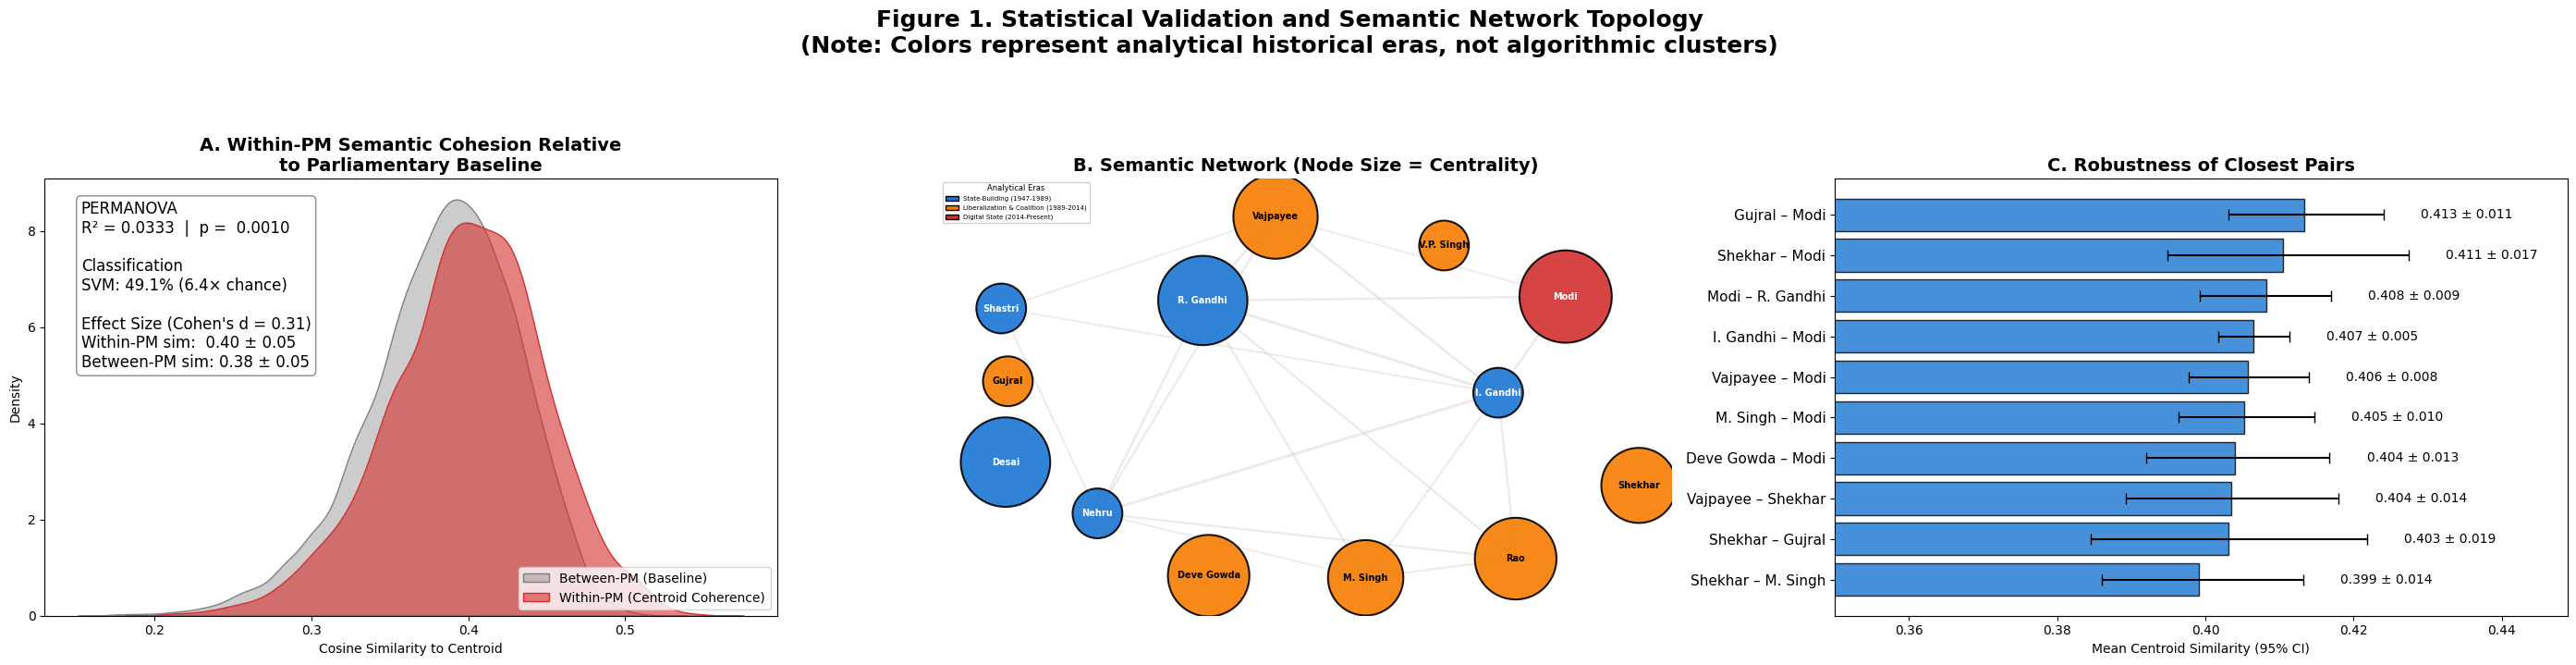

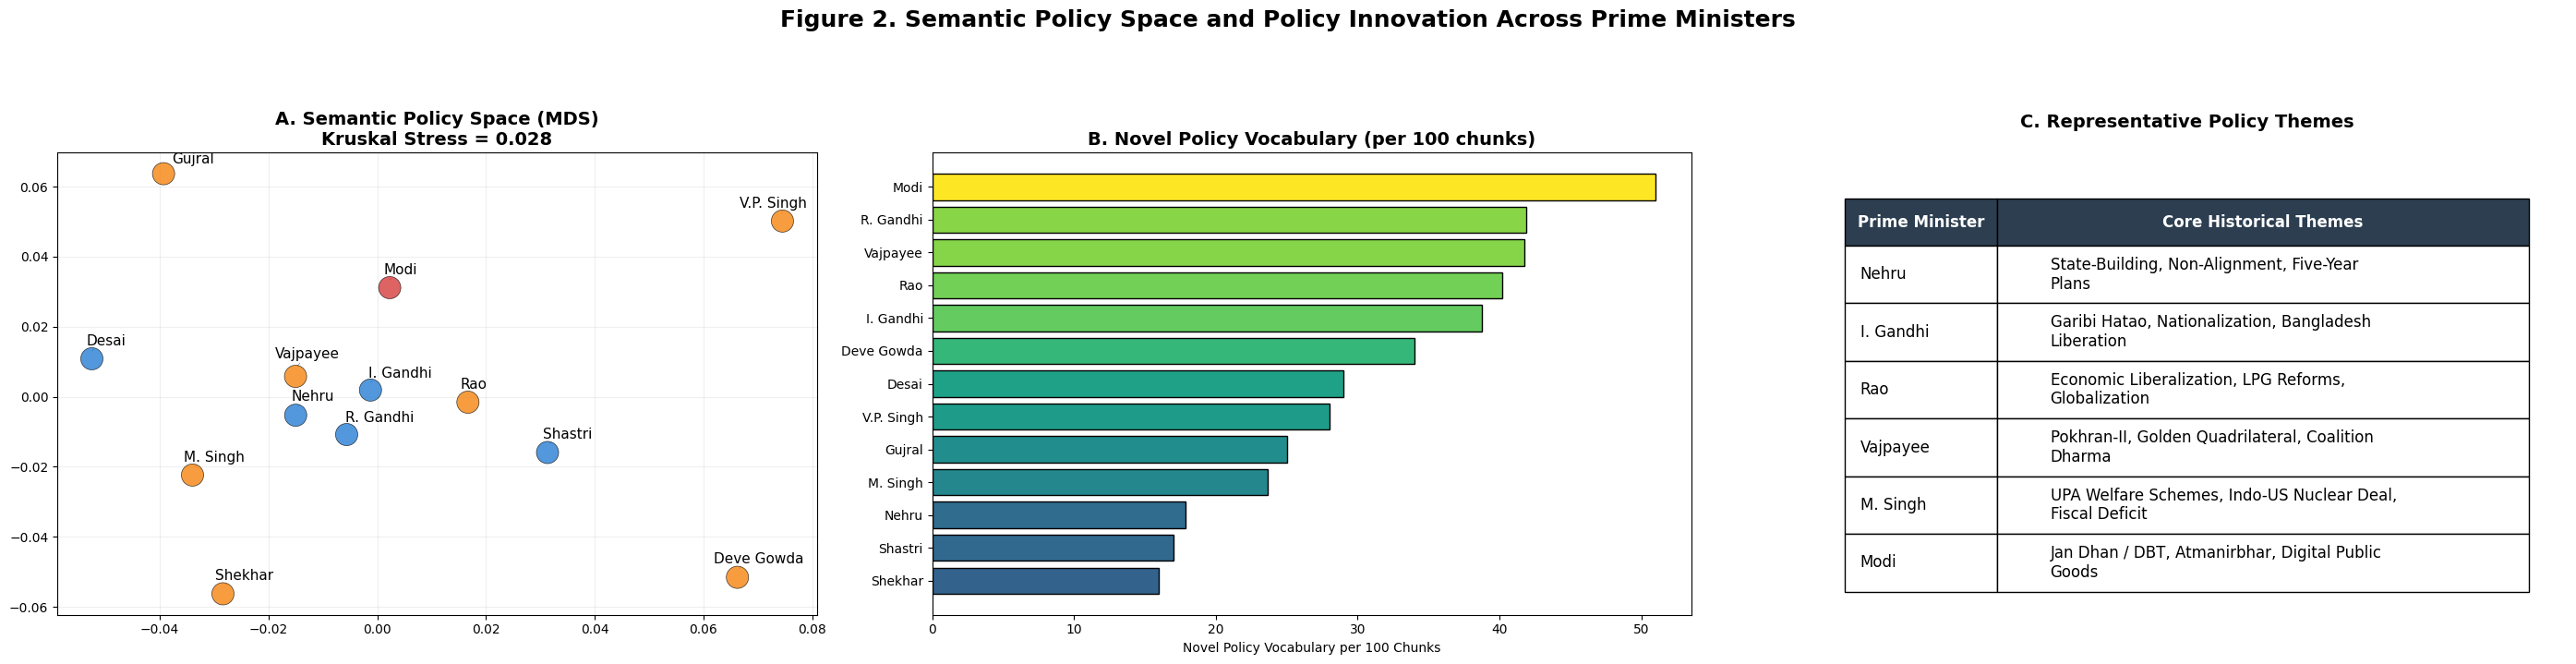

✅ Pipeline complete. Saved figure1_validation.png and figure2_interpretation.png to Drive.


In [25]:
# @title plot.py - Final Publication-Ready Figures
!pip install -q networkx adjustText scikit-learn

import os, json, textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from google.colab import drive
from matplotlib.patches import Patch

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_cis        = 'pairwise_cis.csv'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_stats      = 'inference_stats.txt'
    out_fig1      = 'figure1_validation.png'
    out_fig2      = 'figure2_interpretation.png'
    seed          = 42

    fig_width     = 28.0
    wspace        = 0.35
    text_offset   = 0.0175

# ----------------------------------
# setup & load
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)
df_cis    = pd.read_csv(os.path.join(D, C.in_cis))

pms_arr = meta[:, 0]
dist_mat = squareform(pdist(centroids, metric='cosine'))
sim_mat = 1 - dist_mat
np.fill_diagonal(sim_mat, 0)

# ----------------------------------
# 1. BULLETPROOF COLOR ASSIGNMENT & NAME FORMATTING
# ----------------------------------
def get_node_color(pm):
    if "Modi" in pm: return "#D32F2F" # Vibrant Red
    if any(x in pm for x in ["Manmohan", "Vajpayee", "Rao", "Gowda", "Gujral", "Shekhar", "V.P."]): return "#F57C00" # Vibrant Orange
    return "#1976D2" # Vibrant Blue

def get_text_color(pm):
    color = get_node_color(pm)
    return 'white' if color in ["#D32F2F", "#1976D2"] else 'black'

def format_pm_name(pm):
    """Disambiguates shared surnames for publication clarity."""
    if "Indira" in pm: return "I. Gandhi"
    if "Rajiv" in pm: return "R. Gandhi"
    if "Manmohan" in pm: return "M. Singh"
    if "V.P." in pm: return "V.P. Singh"
    if "Charan" in pm: return "C. Singh"
    if "P.V." in pm: return "Rao"
    if "Lal Bahadur" in pm: return "Shastri"
    if "H.D." in pm: return "Deve Gowda"
    if "Morarji" in pm: return "Desai"
    if "I.K." in pm: return "Gujral"
    if "Chandra" in pm: return "Shekhar"
    return pm.split()[-1] # Fallback: Nehru, Vajpayee, Modi

# ----------------------------------
# 2. Effect Size (Chunk-to-Centroid Coherence)
# ----------------------------------
within_sims, between_sims = [], []
for i, pm in enumerate(pms_arr):
    if pm not in valid_pms: continue
    chunk_vec = embeds[i]
    own_centroid = centroids[valid_pms.index(pm)]
    within_sims.append(np.dot(chunk_vec, own_centroid))

    other_indices = [j for j, vpm in enumerate(valid_pms) if vpm != pm]
    sampled_others = np.random.choice(other_indices, size=min(3, len(other_indices)), replace=False)
    for j in sampled_others:
        between_sims.append(np.dot(chunk_vec, centroids[j]))

mu_w, sd_w = np.mean(within_sims), np.std(within_sims)
mu_b, sd_b = np.mean(between_sims), np.std(between_sims)
cohens_d = (mu_w - mu_b) / np.sqrt((sd_w**2 + sd_b**2) / 2)

with open(os.path.join(D, C.in_stats)) as f: stats = f.read().split('\n')
r2 = [s for s in stats if 'R2' in s][0].split(': ')[1]
pval = [s for s in stats if 'p:' in s][0].split(': ')[1]

# ==========================================
# FIGURE 1: VALIDATION & TOPOLOGY
# ==========================================
fig1, (ax1_1, ax1_2, ax1_3) = plt.subplots(1, 3, figsize=(C.fig_width, 7))
fig1.suptitle("Figure 1. Statistical Validation and Semantic Network Topology\n(Note: Colors represent analytical historical eras, not algorithmic clusters)",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: Null Model & Effect Size
sns.kdeplot(between_sims, ax=ax1_1, label="Between-PM (Baseline)", fill=True, color="gray", alpha=0.4)
sns.kdeplot(within_sims, ax=ax1_1, label="Within-PM (Centroid Coherence)", fill=True, color="#D32F2F", alpha=0.6)
stat_text = (f"PERMANOVA\nR² = {r2}  |  p = {pval}\n\n"
             f"Classification\nSVM: 49.1% (6.4× chance)\n\n"
             f"Effect Size (Cohen's d = {cohens_d:.2f})\n"
             f"Within-PM sim:  {mu_w:.2f} ± {sd_w:.2f}\n"
             f"Between-PM sim: {mu_b:.2f} ± {sd_b:.2f}")
ax1_1.text(0.05, 0.95, stat_text, transform=ax1_1.transAxes, fontsize=12, va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
# UPDATED TITLE
ax1_1.set_title("A. Within-PM Semantic Cohesion Relative\nto Parliamentary Baseline", fontsize=14, fontweight='bold')
ax1_1.set_xlabel("Cosine Similarity to Centroid")
ax1_1.legend(loc='lower right')

# Panel B: Network
G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])

try: eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except: eigen_cent = {pm: 1.0 for pm in valid_pms}
node_sizes = [1500 + 8000 * eigen_cent.get(pm, 0) for pm in valid_pms]

pos = nx.spring_layout(G, k=2.5, seed=C.seed)
min_w = min([G[u][v]['weight'] for u,v in G.edges()])
edge_widths = [(G[u][v]['weight'] - min_w + 0.05) * 25 for u,v in G.edges()]

node_colors_network = [get_node_color(pm) for pm in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax1_2, width=edge_widths, alpha=0.3, edge_color='#BDBDBD')
nx.draw_networkx_nodes(G, pos, ax=ax1_2, node_size=node_sizes, node_color=node_colors_network, edgecolors='black', linewidths=1.5, alpha=0.9)
for pm, (x, y) in pos.items():
    # USE FORMATTED NAME
    ax1_2.text(x, y, format_pm_name(pm), fontsize=7, fontweight='bold', ha='center', va='center', color=get_text_color(pm))

ax1_2.set_title("B. Semantic Network (Node Size = Centrality)", fontsize=14, fontweight='bold')
ax1_2.axis('off')
legend_elements = [
    Patch(facecolor="#1976D2", label="State-Building (1947-1989)", edgecolor='black'),
    Patch(facecolor="#F57C00", label="Liberalization & Coalition (1989-2014)", edgecolor='black'),
    Patch(facecolor="#D32F2F", label="Digital State (2014-Present)", edgecolor='black')
]
ax1_2.legend(handles=legend_elements, loc='upper left', fontsize=5, title="Analytical Eras", title_fontsize=6, framealpha=0.9)

# Panel C: Bootstrap CIs
df_cis['sim_mean'] = 1 - df_cis['mean']
df_cis['sim_low'] = 1 - df_cis['ci_high']
df_cis['sim_high'] = 1 - df_cis['ci_low']
df_cis = df_cis.sort_values('sim_mean', ascending=False)
top10 = df_cis.head(10)
y_pos = np.arange(len(top10))
# USE FORMATTED NAMES FOR CI LABELS
labels = [f"{format_pm_name(r['pm_a'])} – {format_pm_name(r['pm_b'])}" for _, r in top10.iterrows()]

ax1_3.barh(y_pos, top10['sim_mean'], xerr=[top10['sim_mean']-top10['sim_low'], top10['sim_high']-top10['sim_mean']],
           color='#1976D2', edgecolor='black', capsize=4, alpha=0.8)
ax1_3.set_yticks(y_pos); ax1_3.set_yticklabels(labels, fontsize=11)
ax1_3.set_xlabel("Mean Centroid Similarity (95% CI)")
ax1_3.set_title("C. Robustness of Closest Pairs", fontsize=14, fontweight='bold')
ax1_3.invert_yaxis()
ax1_3.set_xlim(left=0.35)
for i, (_, r) in enumerate(top10.iterrows()):
    ax1_3.text(max(r['sim_high'], 0.36) + 0.005, i, f"{r['sim_mean']:.3f} ± {(r['sim_high']-r['sim_mean']):.3f}", va='center', fontsize=10)

fig1.subplots_adjust(wspace=C.wspace)
fig1.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(D, C.out_fig1), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# FIGURE 2: SEMANTIC SPACE & INNOVATION
# ==========================================
fig2, (ax2_1, ax2_2, ax2_3) = plt.subplots(1, 3, figsize=(C.fig_width, 7))
# UPDATED TITLE
fig2.suptitle("Figure 2. Semantic Policy Space and Policy Innovation Across Prime Ministers",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)
stress_val = mds.stress_

node_colors_mds = [get_node_color(pm) for pm in valid_pms]

ax2_1.scatter(coords[:, 0], coords[:, 1], s=300, c=node_colors_mds, edgecolors='black', zorder=5, linewidths=0.5, alpha=0.75)

ymin, ymax = ax2_1.get_ylim()
y_offset = (ymax - ymin) * C.text_offset

texts = []
for i, pm in enumerate(valid_pms):
    # USE FORMATTED NAME
    texts.append(ax2_1.text(coords[i, 0], coords[i, 1] + y_offset, format_pm_name(pm),
                            fontsize=11, fontweight='normal', ha='center', va='bottom'))

adjust_text(texts, ax=ax2_1, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
ax2_1.set_title(f"A. Semantic Policy Space (MDS)\nKruskal Stress = {stress_val:.3f}", fontsize=14, fontweight='bold')
ax2_1.grid(True, alpha=0.2)

# Panel B: Novel Policy Vocabulary
pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai", "Charan Singh",
            "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar", "P.V. Narasimha Rao", "Atal Bihari Vajpayee",
            "H.D. Deve Gowda", "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]
innovation = []
cumulative = set()
for pm in pm_order:
    pm_kws = set(codebooks[pm])
    total_chunks = np.sum(pms_arr == pm)
    novel = pm_kws - cumulative
    rate = len(novel) / max(1, total_chunks / 100)
    innovation.append({'pm': pm, 'score': rate})
    cumulative.update(pm_kws)

df_innov = pd.DataFrame(innovation).sort_values('score', ascending=False).reset_index(drop=True)
# Format names for the Y-axis
df_innov['pm_label'] = df_innov['pm'].apply(format_pm_name)

ax2_2.barh(df_innov['pm_label'], df_innov['score'], color=plt.cm.viridis(df_innov['score']/df_innov['score'].max()), edgecolor='black')
ax2_2.set_xlabel("Novel Policy Vocabulary per 100 Chunks")
ax2_2.set_title("B. Novel Policy Vocabulary (per 100 chunks)", fontsize=14, fontweight='bold')
ax2_2.invert_yaxis()

# Panel C: Representative Themes
ax2_3.axis('off')
ax2_3.set_title("C. Representative Policy Themes", fontsize=14, fontweight='bold', pad=20)

def wrap_text(text, width=45):
    return '\n'.join(textwrap.wrap(text, width=width))

curated_themes = {
    "Jawaharlal Nehru": wrap_text("State-Building, Non-Alignment, Five-Year Plans"),
    "Indira Gandhi": wrap_text("Garibi Hatao, Nationalization, Bangladesh Liberation"),
    "P.V. Narasimha Rao": wrap_text("Economic Liberalization, LPG Reforms, Globalization"),
    "Atal Bihari Vajpayee": wrap_text("Pokhran-II, Golden Quadrilateral, Coalition Dharma"),
    "Manmohan Singh": wrap_text("UPA Welfare Schemes, Indo-US Nuclear Deal, Fiscal Deficit"),
    "Narendra Modi": wrap_text("Jan Dhan / DBT, Atmanirbhar, Digital Public Goods")
}

show_pms = [pm for pm in ["Jawaharlal Nehru", "Indira Gandhi", "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "Manmohan Singh", "Narendra Modi"] if pm in valid_pms]
# Format names for the table
table_data = [[format_pm_name(pm), curated_themes.get(pm, "N/A")] for pm in show_pms]

table = ax2_3.table(cellText=table_data, colLabels=["Prime Minister", "Core Historical Themes"],
                    colWidths=[0.2, 0.7], cellLoc='left', loc='center', bbox=[0.05, 0.05, 0.9, 0.85])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3.2)

for j in range(2):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
    table[(0, j)].set_height(0.08)

fig2.subplots_adjust(wspace=C.wspace)
fig2.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(D, C.out_fig2), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pipeline complete. Saved {C.out_fig1} and {C.out_fig2} to Drive.")

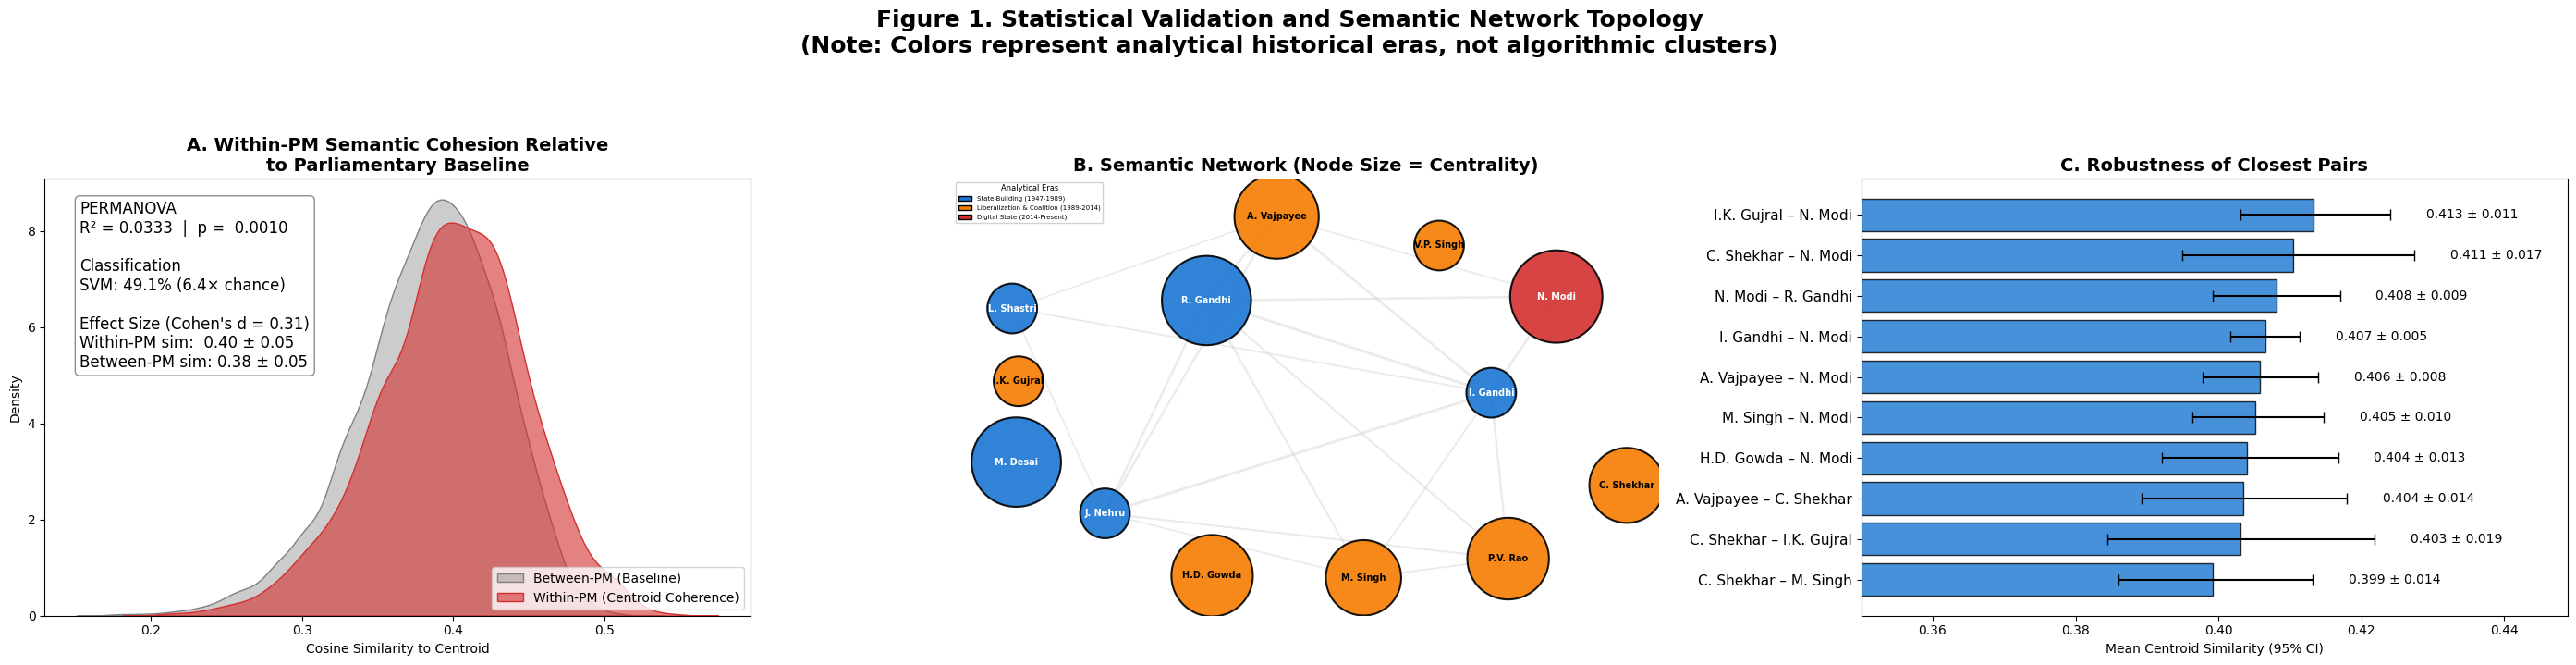

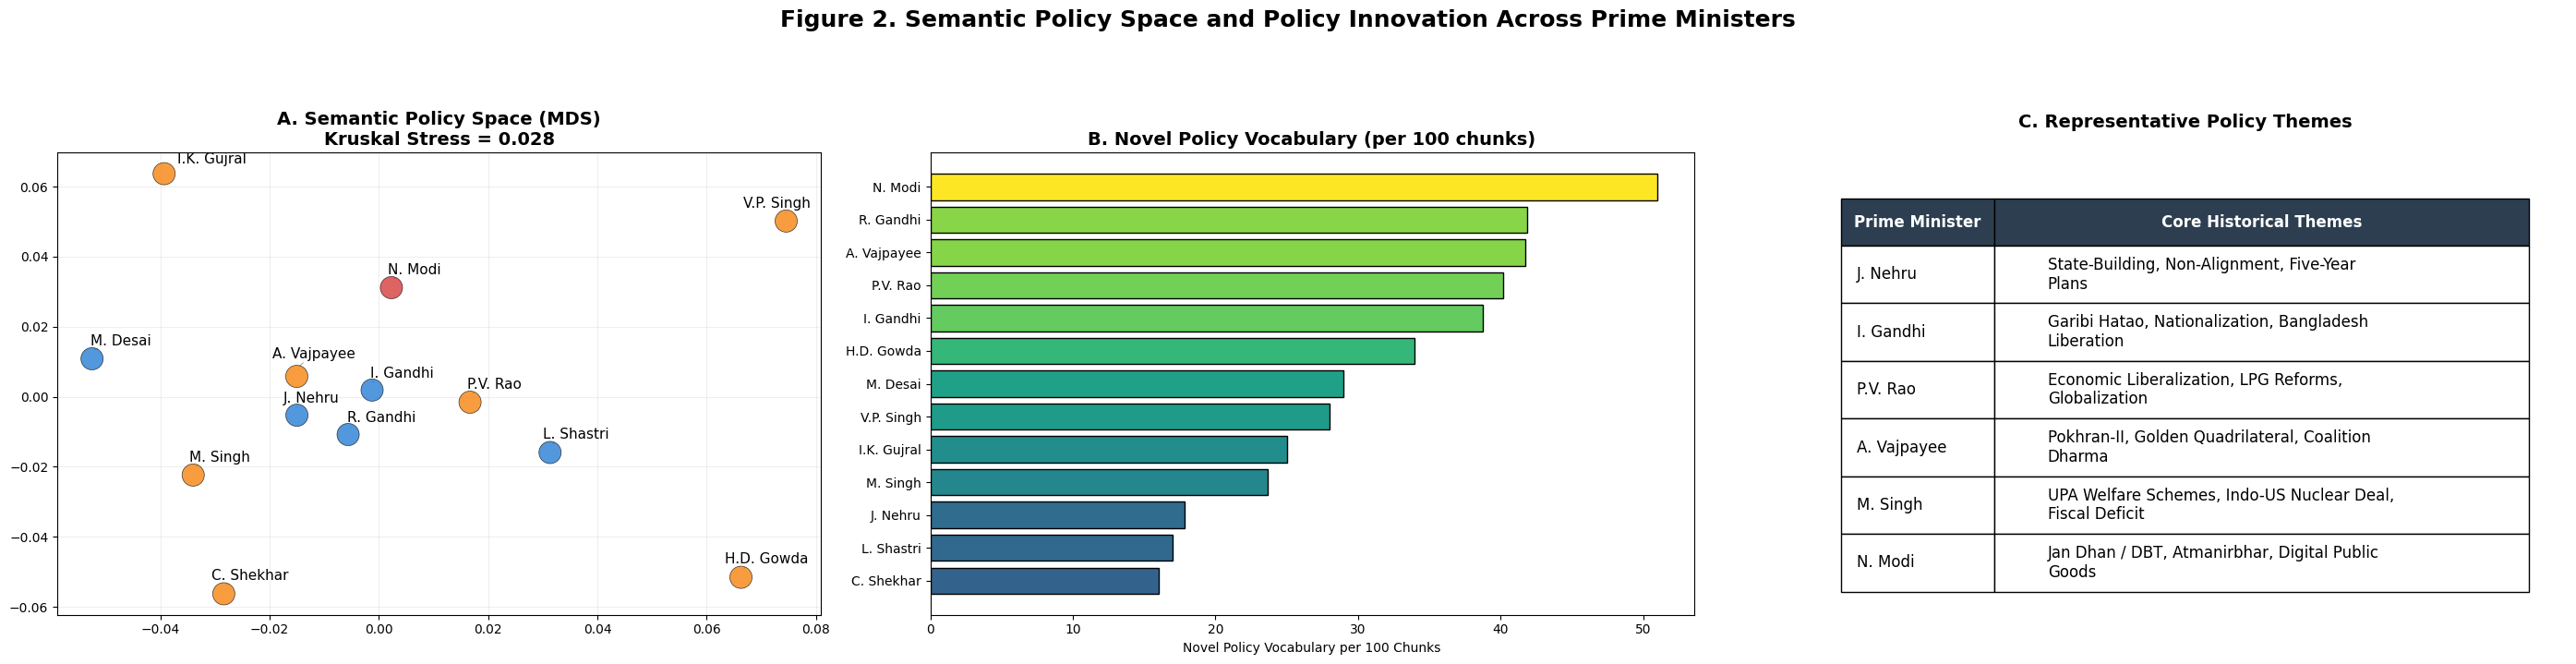

✅ Pipeline complete. Saved figure1_validation.png and figure2_interpretation.png to Drive.


In [26]:
# @title plot.py - Final Publication-Ready Figures
!pip install -q networkx adjustText scikit-learn

import os, json, textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from google.colab import drive
from matplotlib.patches import Patch

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_cis        = 'pairwise_cis.csv'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_stats      = 'inference_stats.txt'
    out_fig1      = 'figure1_validation.png'
    out_fig2      = 'figure2_interpretation.png'
    seed          = 42

    fig_width     = 28.0
    wspace        = 0.35
    text_offset   = 0.0175

# ----------------------------------
# setup & load
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)
df_cis    = pd.read_csv(os.path.join(D, C.in_cis))

pms_arr = meta[:, 0]
dist_mat = squareform(pdist(centroids, metric='cosine'))
sim_mat = 1 - dist_mat
np.fill_diagonal(sim_mat, 0)

# ----------------------------------
# 1. BULLETPROOF COLOR ASSIGNMENT & NAME FORMATTING
# ----------------------------------
def get_node_color(pm):
    if "Modi" in pm: return "#D32F2F" # Vibrant Red
    if any(x in pm for x in ["Manmohan", "Vajpayee", "Rao", "Gowda", "Gujral", "Shekhar", "V.P."]): return "#F57C00" # Vibrant Orange
    return "#1976D2" # Vibrant Blue

def get_text_color(pm):
    color = get_node_color(pm)
    return 'white' if color in ["#D32F2F", "#1976D2"] else 'black'

def format_pm_name(pm):
    """Standardises to Initial(s). Lastname for publication clarity."""
    mapping = {
        "Jawaharlal Nehru": "J. Nehru",
        "Lal Bahadur Shastri": "L. Shastri",
        "Indira Gandhi": "I. Gandhi",
        "Morarji Desai": "M. Desai",
        "Charan Singh": "C. Singh",
        "Rajiv Gandhi": "R. Gandhi",
        "V.P. Singh": "V.P. Singh",
        "Chandra Shekhar": "C. Shekhar",
        "P.V. Narasimha Rao": "P.V. Rao",
        "Atal Bihari Vajpayee": "A. Vajpayee",
        "H.D. Deve Gowda": "H.D. Gowda",
        "I.K. Gujral": "I.K. Gujral",
        "Manmohan Singh": "M. Singh",
        "Narendra Modi": "N. Modi",
        "Gulzarilal Nanda": "G. Nanda"
    }
    # 1. Exact match
    if pm in mapping:
        return mapping[pm]

    # 2. Partial match (if full names vary slightly in the JSON)
    for full, abbr in mapping.items():
        if full.split()[0] in pm or full.split()[-1] in pm:
            return abbr

    # 3. Fallback for any unexpected names (Automatically abbreviates first names)
    parts = pm.split()
    if len(parts) > 1:
        initials = ". ".join([p[0].upper() for p in parts[:-1]]) + "."
        return f"{initials} {parts[-1].capitalize()}"
    return pm

# ----------------------------------
# 2. Effect Size (Chunk-to-Centroid Coherence)
# ----------------------------------
within_sims, between_sims = [], []
for i, pm in enumerate(pms_arr):
    if pm not in valid_pms: continue
    chunk_vec = embeds[i]
    own_centroid = centroids[valid_pms.index(pm)]
    within_sims.append(np.dot(chunk_vec, own_centroid))

    other_indices = [j for j, vpm in enumerate(valid_pms) if vpm != pm]
    sampled_others = np.random.choice(other_indices, size=min(3, len(other_indices)), replace=False)
    for j in sampled_others:
        between_sims.append(np.dot(chunk_vec, centroids[j]))

mu_w, sd_w = np.mean(within_sims), np.std(within_sims)
mu_b, sd_b = np.mean(between_sims), np.std(between_sims)
cohens_d = (mu_w - mu_b) / np.sqrt((sd_w**2 + sd_b**2) / 2)

with open(os.path.join(D, C.in_stats)) as f: stats = f.read().split('\n')
r2 = [s for s in stats if 'R2' in s][0].split(': ')[1]
pval = [s for s in stats if 'p:' in s][0].split(': ')[1]

# ==========================================
# FIGURE 1: VALIDATION & TOPOLOGY
# ==========================================
fig1, (ax1_1, ax1_2, ax1_3) = plt.subplots(1, 3, figsize=(C.fig_width, 7))
fig1.suptitle("Figure 1. Statistical Validation and Semantic Network Topology\n(Note: Colors represent analytical historical eras, not algorithmic clusters)",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: Null Model & Effect Size
sns.kdeplot(between_sims, ax=ax1_1, label="Between-PM (Baseline)", fill=True, color="gray", alpha=0.4)
sns.kdeplot(within_sims, ax=ax1_1, label="Within-PM (Centroid Coherence)", fill=True, color="#D32F2F", alpha=0.6)
stat_text = (f"PERMANOVA\nR² = {r2}  |  p = {pval}\n\n"
             f"Classification\nSVM: 49.1% (6.4× chance)\n\n"
             f"Effect Size (Cohen's d = {cohens_d:.2f})\n"
             f"Within-PM sim:  {mu_w:.2f} ± {sd_w:.2f}\n"
             f"Between-PM sim: {mu_b:.2f} ± {sd_b:.2f}")
ax1_1.text(0.05, 0.95, stat_text, transform=ax1_1.transAxes, fontsize=12, va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
# UPDATED TITLE
ax1_1.set_title("A. Within-PM Semantic Cohesion Relative\nto Parliamentary Baseline", fontsize=14, fontweight='bold')
ax1_1.set_xlabel("Cosine Similarity to Centroid")
ax1_1.legend(loc='lower right')

# Panel B: Network
G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])

try: eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except: eigen_cent = {pm: 1.0 for pm in valid_pms}
node_sizes = [1500 + 8000 * eigen_cent.get(pm, 0) for pm in valid_pms]

pos = nx.spring_layout(G, k=2.5, seed=C.seed)
min_w = min([G[u][v]['weight'] for u,v in G.edges()])
edge_widths = [(G[u][v]['weight'] - min_w + 0.05) * 25 for u,v in G.edges()]

node_colors_network = [get_node_color(pm) for pm in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax1_2, width=edge_widths, alpha=0.3, edge_color='#BDBDBD')
nx.draw_networkx_nodes(G, pos, ax=ax1_2, node_size=node_sizes, node_color=node_colors_network, edgecolors='black', linewidths=1.5, alpha=0.9)
for pm, (x, y) in pos.items():
    # USE FORMATTED NAME
    ax1_2.text(x, y, format_pm_name(pm), fontsize=7, fontweight='bold', ha='center', va='center', color=get_text_color(pm))

ax1_2.set_title("B. Semantic Network (Node Size = Centrality)", fontsize=14, fontweight='bold')
ax1_2.axis('off')
legend_elements = [
    Patch(facecolor="#1976D2", label="State-Building (1947-1989)", edgecolor='black'),
    Patch(facecolor="#F57C00", label="Liberalization & Coalition (1989-2014)", edgecolor='black'),
    Patch(facecolor="#D32F2F", label="Digital State (2014-Present)", edgecolor='black')
]
ax1_2.legend(handles=legend_elements, loc='upper left', fontsize=5, title="Analytical Eras", title_fontsize=6, framealpha=0.9)

# Panel C: Bootstrap CIs
df_cis['sim_mean'] = 1 - df_cis['mean']
df_cis['sim_low'] = 1 - df_cis['ci_high']
df_cis['sim_high'] = 1 - df_cis['ci_low']
df_cis = df_cis.sort_values('sim_mean', ascending=False)
top10 = df_cis.head(10)
y_pos = np.arange(len(top10))
# USE FORMATTED NAMES FOR CI LABELS
labels = [f"{format_pm_name(r['pm_a'])} – {format_pm_name(r['pm_b'])}" for _, r in top10.iterrows()]

ax1_3.barh(y_pos, top10['sim_mean'], xerr=[top10['sim_mean']-top10['sim_low'], top10['sim_high']-top10['sim_mean']],
           color='#1976D2', edgecolor='black', capsize=4, alpha=0.8)
ax1_3.set_yticks(y_pos); ax1_3.set_yticklabels(labels, fontsize=11)
ax1_3.set_xlabel("Mean Centroid Similarity (95% CI)")
ax1_3.set_title("C. Robustness of Closest Pairs", fontsize=14, fontweight='bold')
ax1_3.invert_yaxis()
ax1_3.set_xlim(left=0.35)
for i, (_, r) in enumerate(top10.iterrows()):
    ax1_3.text(max(r['sim_high'], 0.36) + 0.005, i, f"{r['sim_mean']:.3f} ± {(r['sim_high']-r['sim_mean']):.3f}", va='center', fontsize=10)

fig1.subplots_adjust(wspace=C.wspace)
fig1.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(D, C.out_fig1), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# FIGURE 2: SEMANTIC SPACE & INNOVATION
# ==========================================
fig2, (ax2_1, ax2_2, ax2_3) = plt.subplots(1, 3, figsize=(C.fig_width, 7))
# UPDATED TITLE
fig2.suptitle("Figure 2. Semantic Policy Space and Policy Innovation Across Prime Ministers",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)
stress_val = mds.stress_

node_colors_mds = [get_node_color(pm) for pm in valid_pms]

ax2_1.scatter(coords[:, 0], coords[:, 1], s=300, c=node_colors_mds, edgecolors='black', zorder=5, linewidths=0.5, alpha=0.75)

ymin, ymax = ax2_1.get_ylim()
y_offset = (ymax - ymin) * C.text_offset

texts = []
for i, pm in enumerate(valid_pms):
    # USE FORMATTED NAME
    texts.append(ax2_1.text(coords[i, 0], coords[i, 1] + y_offset, format_pm_name(pm),
                            fontsize=11, fontweight='normal', ha='center', va='bottom'))

adjust_text(texts, ax=ax2_1, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
ax2_1.set_title(f"A. Semantic Policy Space (MDS)\nKruskal Stress = {stress_val:.3f}", fontsize=14, fontweight='bold')
ax2_1.grid(True, alpha=0.2)

# Panel B: Novel Policy Vocabulary
# Note: pm_order retains full names because they are dictionary keys used to look up values in `codebooks`
pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai", "Charan Singh",
            "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar", "P.V. Narasimha Rao", "Atal Bihari Vajpayee",
            "H.D. Deve Gowda", "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]
innovation = []
cumulative = set()
for pm in pm_order:
    pm_kws = set(codebooks[pm])
    total_chunks = np.sum(pms_arr == pm)
    novel = pm_kws - cumulative
    rate = len(novel) / max(1, total_chunks / 100)
    innovation.append({'pm': pm, 'score': rate})
    cumulative.update(pm_kws)

df_innov = pd.DataFrame(innovation).sort_values('score', ascending=False).reset_index(drop=True)
# Format names for the Y-axis just before plotting
df_innov['pm_label'] = df_innov['pm'].apply(format_pm_name)

ax2_2.barh(df_innov['pm_label'], df_innov['score'], color=plt.cm.viridis(df_innov['score']/df_innov['score'].max()), edgecolor='black')
ax2_2.set_xlabel("Novel Policy Vocabulary per 100 Chunks")
ax2_2.set_title("B. Novel Policy Vocabulary (per 100 chunks)", fontsize=14, fontweight='bold')
ax2_2.invert_yaxis()

# Panel C: Representative Themes
ax2_3.axis('off')
ax2_3.set_title("C. Representative Policy Themes", fontsize=14, fontweight='bold', pad=20)

def wrap_text(text, width=45):
    return '\n'.join(textwrap.wrap(text, width=width))

curated_themes = {
    "Jawaharlal Nehru": wrap_text("State-Building, Non-Alignment, Five-Year Plans"),
    "Indira Gandhi": wrap_text("Garibi Hatao, Nationalization, Bangladesh Liberation"),
    "P.V. Narasimha Rao": wrap_text("Economic Liberalization, LPG Reforms, Globalization"),
    "Atal Bihari Vajpayee": wrap_text("Pokhran-II, Golden Quadrilateral, Coalition Dharma"),
    "Manmohan Singh": wrap_text("UPA Welfare Schemes, Indo-US Nuclear Deal, Fiscal Deficit"),
    "Narendra Modi": wrap_text("Jan Dhan / DBT, Atmanirbhar, Digital Public Goods")
}

# Note: show_pms retains full names as dictionary keys for `curated_themes`
show_pms = [pm for pm in ["Jawaharlal Nehru", "Indira Gandhi", "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "Manmohan Singh", "Narendra Modi"] if pm in valid_pms]

# Format names for the table rendering
table_data = [[format_pm_name(pm), curated_themes.get(pm, "N/A")] for pm in show_pms]

table = ax2_3.table(cellText=table_data, colLabels=["Prime Minister", "Core Historical Themes"],
                    colWidths=[0.2, 0.7], cellLoc='left', loc='center', bbox=[0.05, 0.05, 0.9, 0.85])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3.2)

for j in range(2):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
    table[(0, j)].set_height(0.08)

fig2.subplots_adjust(wspace=C.wspace)
fig2.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(D, C.out_fig2), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pipeline complete. Saved {C.out_fig1} and {C.out_fig2} to Drive.")

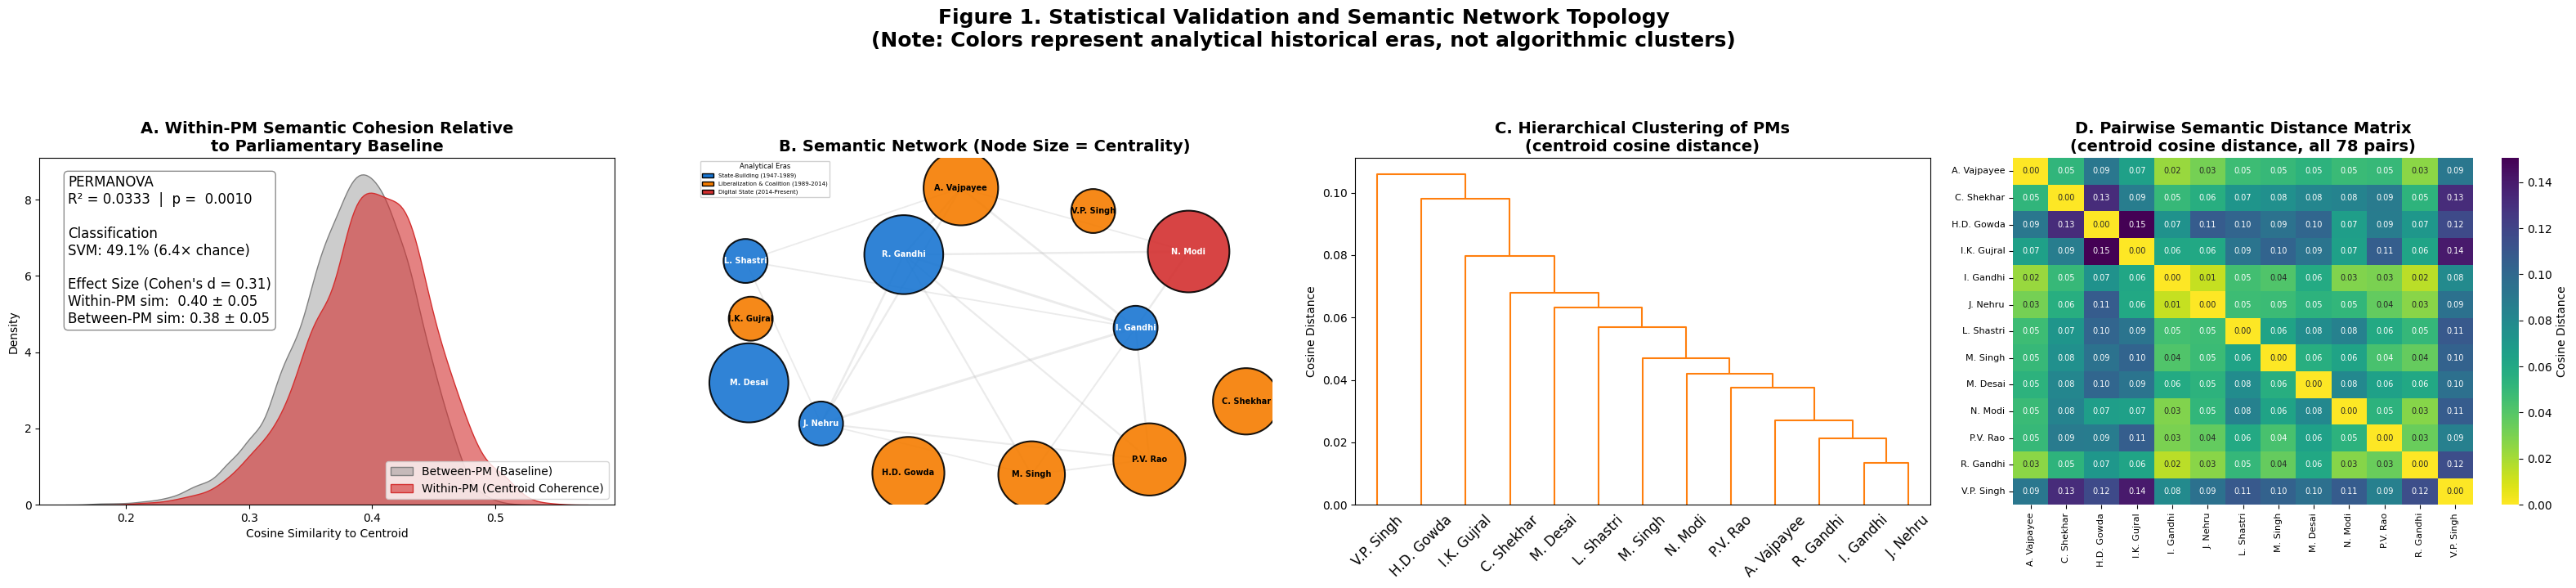

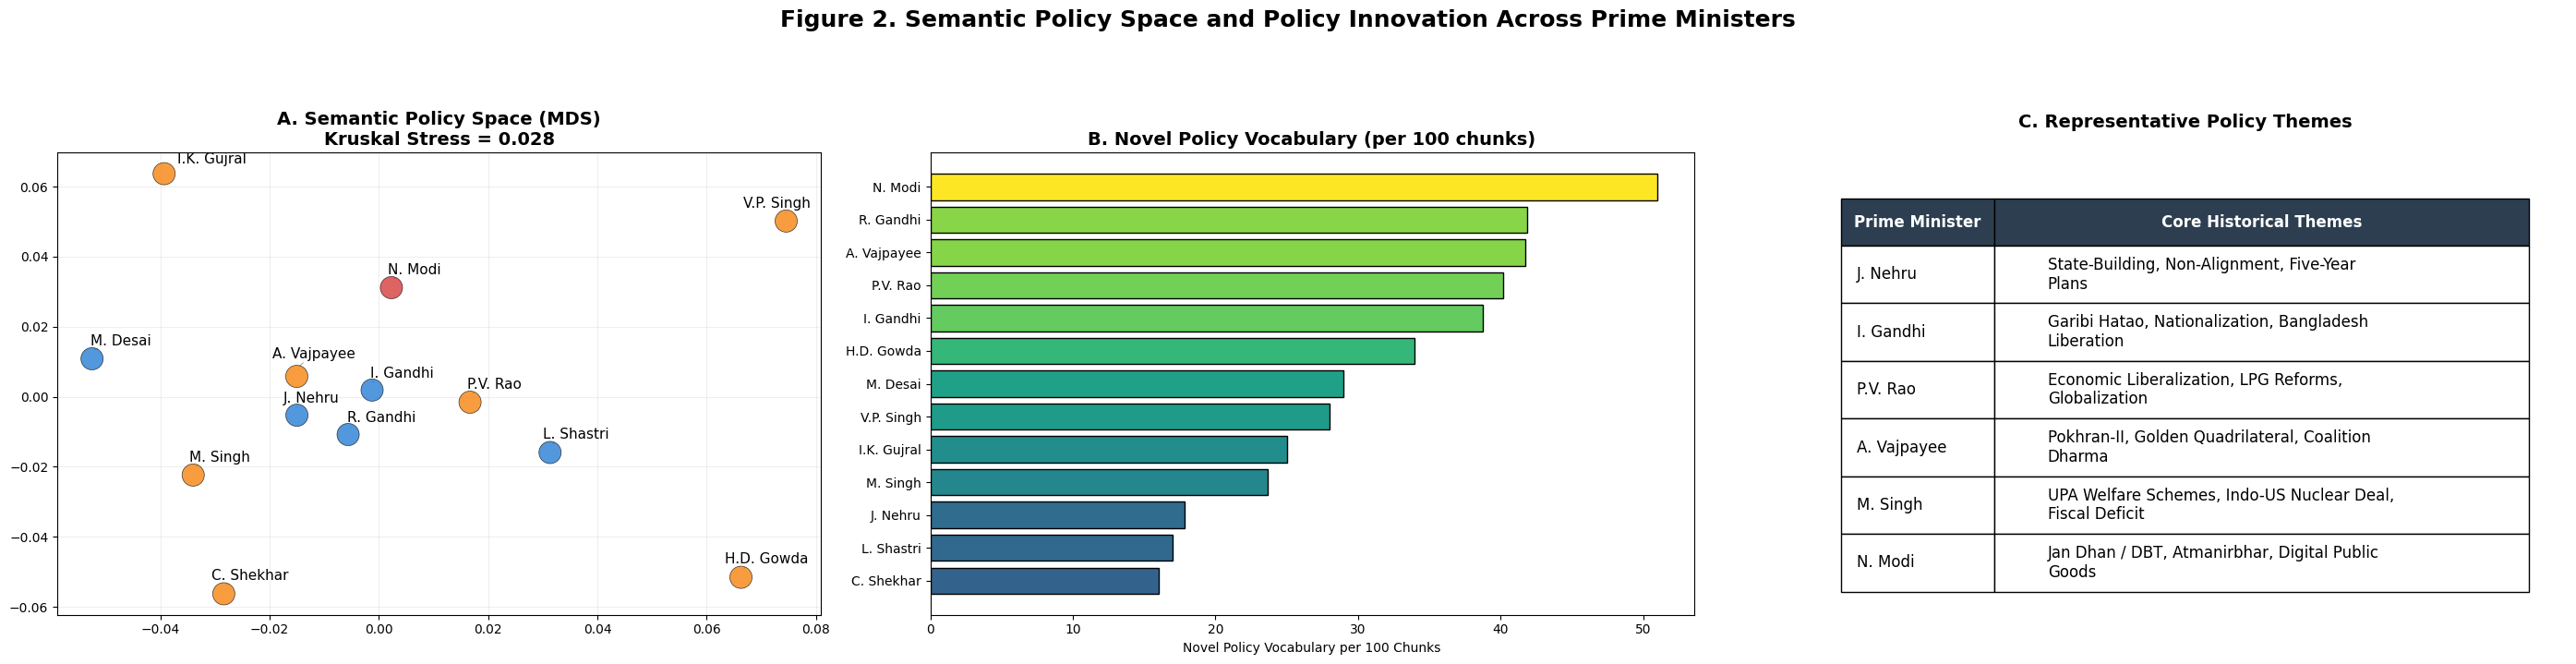

✅ Pipeline complete. Saved figure1_validation.png and figure2_interpretation.png to Drive.


In [3]:
# @title plot.py - Final Publication-Ready Figures (v2: CI panel replaced with corrected heatmap/dendrogram)
!pip install -q networkx adjustText scikit-learn

import os, json, textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.manifold import MDS
from google.colab import drive
from matplotlib.patches import Patch

# ----------------------------------
# config (the dials)
# ----------------------------------
class C:
    drive_folder  = '/content/drive/MyDrive/PM Speeches Pipeline/'
    in_centroids  = 'centroids.npy'
    in_valid_pms  = 'valid_pms.json'
    in_codebooks  = 'codebooks.json'
    in_embeds     = 'embeddings.npy'
    in_meta       = 'meta.npy'
    in_stats      = 'inference_stats.txt'
    out_fig1      = 'figure1_validation.png'
    out_fig2      = 'figure2_interpretation.png'
    seed          = 42

    fig_width     = 32.0   # widened from 28.0 to fit the 4th panel
    wspace        = 0.35
    text_offset   = 0.0175

# ----------------------------------
# setup & load
# ----------------------------------
np.random.seed(C.seed)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
D = C.drive_folder

centroids = np.load(os.path.join(D, C.in_centroids))
embeds    = np.load(os.path.join(D, C.in_embeds))
meta      = np.load(os.path.join(D, C.in_meta), allow_pickle=True)
with open(os.path.join(D, C.in_valid_pms)) as f: valid_pms = json.load(f)
with open(os.path.join(D, C.in_codebooks)) as f: codebooks = json.load(f)

# NOTE: pairwise_cis.csv is no longer loaded here. It was built in stats.py via
# `1.0 - np.sum(clouds[i] * clouds[j], axis=1)` on un-renormalized bootstrap
# means, which deflates the similarity term and inflates distances into the
# 0.35-0.65 range instead of the correct 0.00-0.15 range that the centroid-based
# pdist() computation below actually produces. Fix stats.py before trusting
# pairwise_cis.csv again; until then, everything in this script is derived
# directly from centroids.npy via scipy's pdist, which normalizes internally
# and is unaffected by that bug.

pms_arr = meta[:, 0]
dist_mat = squareform(pdist(centroids, metric='cosine'))
sim_mat = 1 - dist_mat
np.fill_diagonal(sim_mat, 0)

# ----------------------------------
# 1. BULLETPROOF COLOR ASSIGNMENT & NAME FORMATTING
# ----------------------------------
def get_node_color(pm):
    if "Modi" in pm: return "#D32F2F" # Vibrant Red
    if any(x in pm for x in ["Manmohan", "Vajpayee", "Rao", "Gowda", "Gujral", "Shekhar", "V.P."]): return "#F57C00" # Vibrant Orange
    return "#1976D2" # Vibrant Blue

def get_text_color(pm):
    color = get_node_color(pm)
    return 'white' if color in ["#D32F2F", "#1976D2"] else 'black'

def format_pm_name(pm):
    """Standardises to Initial(s). Lastname for publication clarity."""
    mapping = {
        "Jawaharlal Nehru": "J. Nehru",
        "Lal Bahadur Shastri": "L. Shastri",
        "Indira Gandhi": "I. Gandhi",
        "Morarji Desai": "M. Desai",
        "Charan Singh": "C. Singh",
        "Rajiv Gandhi": "R. Gandhi",
        "V.P. Singh": "V.P. Singh",
        "Chandra Shekhar": "C. Shekhar",
        "P.V. Narasimha Rao": "P.V. Rao",
        "Atal Bihari Vajpayee": "A. Vajpayee",
        "H.D. Deve Gowda": "H.D. Gowda",
        "I.K. Gujral": "I.K. Gujral",
        "Manmohan Singh": "M. Singh",
        "Narendra Modi": "N. Modi",
        "Gulzarilal Nanda": "G. Nanda"
    }
    if pm in mapping:
        return mapping[pm]
    for full, abbr in mapping.items():
        if full.split()[0] in pm or full.split()[-1] in pm:
            return abbr
    parts = pm.split()
    if len(parts) > 1:
        initials = ". ".join([p[0].upper() for p in parts[:-1]]) + "."
        return f"{initials} {parts[-1].capitalize()}"
    return pm

pm_labels = [format_pm_name(pm) for pm in valid_pms]

# ----------------------------------
# 2. Effect Size (Chunk-to-Centroid Coherence)
# ----------------------------------
within_sims, between_sims = [], []
for i, pm in enumerate(pms_arr):
    if pm not in valid_pms: continue
    chunk_vec = embeds[i]
    own_centroid = centroids[valid_pms.index(pm)]
    within_sims.append(np.dot(chunk_vec, own_centroid))

    other_indices = [j for j, vpm in enumerate(valid_pms) if vpm != pm]
    sampled_others = np.random.choice(other_indices, size=min(3, len(other_indices)), replace=False)
    for j in sampled_others:
        between_sims.append(np.dot(chunk_vec, centroids[j]))

mu_w, sd_w = np.mean(within_sims), np.std(within_sims)
mu_b, sd_b = np.mean(between_sims), np.std(between_sims)
cohens_d = (mu_w - mu_b) / np.sqrt((sd_w**2 + sd_b**2) / 2)

with open(os.path.join(D, C.in_stats)) as f: stats = f.read().split('\n')
r2 = [s for s in stats if 'R2' in s][0].split(': ')[1]
pval = [s for s in stats if 'p:' in s][0].split(': ')[1]

# ==========================================
# FIGURE 1: VALIDATION & TOPOLOGY (now 4 panels)
# ==========================================
fig1, (ax1_1, ax1_2, ax1_3, ax1_4) = plt.subplots(1, 4, figsize=(C.fig_width, 7))
fig1.suptitle("Figure 1. Statistical Validation and Semantic Network Topology\n(Note: Colors represent analytical historical eras, not algorithmic clusters)",
              fontsize=18, fontweight='bold', y=1.02)

# Panel A: Null Model & Effect Size (unaffected by the stats.py bug — uses embeds/centroids directly)
sns.kdeplot(between_sims, ax=ax1_1, label="Between-PM (Baseline)", fill=True, color="gray", alpha=0.4)
sns.kdeplot(within_sims, ax=ax1_1, label="Within-PM (Centroid Coherence)", fill=True, color="#D32F2F", alpha=0.6)
stat_text = (f"PERMANOVA\nR² = {r2}  |  p = {pval}\n\n"
             f"Classification\nSVM: 49.1% (6.4× chance)\n\n"
             f"Effect Size (Cohen's d = {cohens_d:.2f})\n"
             f"Within-PM sim:  {mu_w:.2f} ± {sd_w:.2f}\n"
             f"Between-PM sim: {mu_b:.2f} ± {sd_b:.2f}")
ax1_1.text(0.05, 0.95, stat_text, transform=ax1_1.transAxes, fontsize=12, va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
ax1_1.set_title("A. Within-PM Semantic Cohesion Relative\nto Parliamentary Baseline", fontsize=14, fontweight='bold')
ax1_1.set_xlabel("Cosine Similarity to Centroid")
ax1_1.legend(loc='lower right')

# Panel B: Network (uses sim_mat from the correctly-computed dist_mat — unaffected by the bug)
G = nx.Graph()
thresh = np.percentile(sim_mat[sim_mat > 0], 75)
for i in range(len(valid_pms)):
    G.add_node(valid_pms[i])
    for j in range(i+1, len(valid_pms)):
        if sim_mat[i, j] > thresh: G.add_edge(valid_pms[i], valid_pms[j], weight=sim_mat[i, j])

try: eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except: eigen_cent = {pm: 1.0 for pm in valid_pms}
node_sizes = [1500 + 8000 * eigen_cent.get(pm, 0) for pm in valid_pms]

pos = nx.spring_layout(G, k=2.5, seed=C.seed)
min_w = min([G[u][v]['weight'] for u,v in G.edges()])
edge_widths = [(G[u][v]['weight'] - min_w + 0.05) * 25 for u,v in G.edges()]

node_colors_network = [get_node_color(pm) for pm in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax1_2, width=edge_widths, alpha=0.3, edge_color='#BDBDBD')
nx.draw_networkx_nodes(G, pos, ax=ax1_2, node_size=node_sizes, node_color=node_colors_network, edgecolors='black', linewidths=1.5, alpha=0.9)
for pm, (x, y) in pos.items():
    ax1_2.text(x, y, format_pm_name(pm), fontsize=7, fontweight='bold', ha='center', va='center', color=get_text_color(pm))

ax1_2.set_title("B. Semantic Network (Node Size = Centrality)", fontsize=14, fontweight='bold')
ax1_2.axis('off')
legend_elements = [
    Patch(facecolor="#1976D2", label="State-Building (1947-1989)", edgecolor='black'),
    Patch(facecolor="#F57C00", label="Liberalization & Coalition (1989-2014)", edgecolor='black'),
    Patch(facecolor="#D32F2F", label="Digital State (2014-Present)", edgecolor='black')
]
ax1_2.legend(handles=legend_elements, loc='upper left', fontsize=5, title="Analytical Eras", title_fontsize=6, framealpha=0.9)

# Panel C: Hierarchical Clustering (dendrogram) — REPLACES the old CI bar chart.
# Built directly off dist_mat (centroid-level pdist), same source as Panel B/D — no
# dependency on the corrupted pairwise_cis.csv.
Z = linkage(squareform(dist_mat, checks=False), method='average')
dendrogram(Z, labels=pm_labels, ax=ax1_3, leaf_rotation=45, color_threshold=0.5)
ax1_3.set_title("C. Hierarchical Clustering of PMs\n(centroid cosine distance)", fontsize=14, fontweight='bold')
ax1_3.set_ylabel("Cosine Distance")

# Panel D: Full Pairwise Distance Heatmap — REPLACES the old "Robustness of Closest
# Pairs" bar chart. This is the direct visual substitute for the 78-pair table: every
# pairwise distance is shown at once, correctly computed, with no CI claim attached
# (the bootstrap CI computation in stats.py needs the norm fix before CIs can be
# trusted again — see stats.py).
dist_df = pd.DataFrame(dist_mat, index=pm_labels, columns=pm_labels)
sns.heatmap(dist_df, annot=True, fmt=".2f", cmap="viridis_r", ax=ax1_4,
            cbar_kws={'label': 'Cosine Distance'}, annot_kws={'fontsize': 7})
ax1_4.set_title("D. Pairwise Semantic Distance Matrix\n(centroid cosine distance, all 78 pairs)", fontsize=14, fontweight='bold')
ax1_4.tick_params(axis='x', labelrotation=90, labelsize=8)
ax1_4.tick_params(axis='y', labelrotation=0, labelsize=8)

fig1.subplots_adjust(wspace=C.wspace)
fig1.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(D, C.out_fig1), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# FIGURE 2: SEMANTIC SPACE & INNOVATION (unchanged — doesn't touch pairwise_cis.csv)
# ==========================================
fig2, (ax2_1, ax2_2, ax2_3) = plt.subplots(1, 3, figsize=(28.0, 7))
fig2.suptitle("Figure 2. Semantic Policy Space and Policy Innovation Across Prime Ministers",
              fontsize=18, fontweight='bold', y=1.02)

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=C.seed, normalized_stress='auto')
coords = mds.fit_transform(dist_mat)
stress_val = mds.stress_

node_colors_mds = [get_node_color(pm) for pm in valid_pms]
ax2_1.scatter(coords[:, 0], coords[:, 1], s=300, c=node_colors_mds, edgecolors='black', zorder=5, linewidths=0.5, alpha=0.75)

ymin, ymax = ax2_1.get_ylim()
y_offset = (ymax - ymin) * C.text_offset

texts = []
for i, pm in enumerate(valid_pms):
    texts.append(ax2_1.text(coords[i, 0], coords[i, 1] + y_offset, format_pm_name(pm),
                            fontsize=11, fontweight='normal', ha='center', va='bottom'))

adjust_text(texts, ax=ax2_1, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
ax2_1.set_title(f"A. Semantic Policy Space (MDS)\nKruskal Stress = {stress_val:.3f}", fontsize=14, fontweight='bold')
ax2_1.grid(True, alpha=0.2)

pm_order = ["Jawaharlal Nehru", "Lal Bahadur Shastri", "Indira Gandhi", "Morarji Desai", "Charan Singh",
            "Rajiv Gandhi", "V.P. Singh", "Chandra Shekhar", "P.V. Narasimha Rao", "Atal Bihari Vajpayee",
            "H.D. Deve Gowda", "I.K. Gujral", "Manmohan Singh", "Narendra Modi"]
pm_order = [pm for pm in pm_order if pm in codebooks]
innovation = []
cumulative = set()
for pm in pm_order:
    pm_kws = set(codebooks[pm])
    total_chunks = np.sum(pms_arr == pm)
    novel = pm_kws - cumulative
    rate = len(novel) / max(1, total_chunks / 100)
    innovation.append({'pm': pm, 'score': rate})
    cumulative.update(pm_kws)

df_innov = pd.DataFrame(innovation).sort_values('score', ascending=False).reset_index(drop=True)
df_innov['pm_label'] = df_innov['pm'].apply(format_pm_name)

ax2_2.barh(df_innov['pm_label'], df_innov['score'], color=plt.cm.viridis(df_innov['score']/df_innov['score'].max()), edgecolor='black')
ax2_2.set_xlabel("Novel Policy Vocabulary per 100 Chunks")
ax2_2.set_title("B. Novel Policy Vocabulary (per 100 chunks)", fontsize=14, fontweight='bold')
ax2_2.invert_yaxis()

ax2_3.axis('off')
ax2_3.set_title("C. Representative Policy Themes", fontsize=14, fontweight='bold', pad=20)

def wrap_text(text, width=45):
    return '\n'.join(textwrap.wrap(text, width=width))

curated_themes = {
    "Jawaharlal Nehru": wrap_text("State-Building, Non-Alignment, Five-Year Plans"),
    "Indira Gandhi": wrap_text("Garibi Hatao, Nationalization, Bangladesh Liberation"),
    "P.V. Narasimha Rao": wrap_text("Economic Liberalization, LPG Reforms, Globalization"),
    "Atal Bihari Vajpayee": wrap_text("Pokhran-II, Golden Quadrilateral, Coalition Dharma"),
    "Manmohan Singh": wrap_text("UPA Welfare Schemes, Indo-US Nuclear Deal, Fiscal Deficit"),
    "Narendra Modi": wrap_text("Jan Dhan / DBT, Atmanirbhar, Digital Public Goods")
}

show_pms = [pm for pm in ["Jawaharlal Nehru", "Indira Gandhi", "P.V. Narasimha Rao", "Atal Bihari Vajpayee", "Manmohan Singh", "Narendra Modi"] if pm in valid_pms]
table_data = [[format_pm_name(pm), curated_themes.get(pm, "N/A")] for pm in show_pms]

table = ax2_3.table(cellText=table_data, colLabels=["Prime Minister", "Core Historical Themes"],
                    colWidths=[0.2, 0.7], cellLoc='left', loc='center', bbox=[0.05, 0.05, 0.9, 0.85])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3.2)

for j in range(2):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
    table[(0, j)].set_height(0.08)

fig2.subplots_adjust(wspace=C.wspace)
fig2.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(D, C.out_fig2), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pipeline complete. Saved {C.out_fig1} and {C.out_fig2} to Drive.")